# Taller 2 · De 16 canales a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

En el Taller 1 tenían un electrodo y tres neuronas. Aquí tienen **una sonda con 16 electrodos** y dos
registros (experimentos) donde no todo lo que cruza el umbral es una neurona. La pregunta cambia: ya
no es sólo *¿qué neurona responde a qué estímulo?*, sino **¿cuáles de estos grupos son neuronas de
verdad?** y, de ser neuronas de verdad, **¿cuáles responden de manera significativa al estímulo?**

## Cómo está organizado

Trabajan con **dos registros de la misma sonda**:

| archivo | qué trae | para qué |
|---|---|---|
| `taller2_limpia.h5` | 90 s, sin estímulos, unas pocas unidades bien separadas y poco ruido | aprender el método donde todo sale bonito |
| `taller2_ruidosa.h5` | 200 s, tres condiciones de estímulo, muchas más unidades, actividad multiunitaria y artefactos | hacer el trabajo de verdad |

**El pipeline se escribe una sola vez.** Lo construyen sobre la grabación limpia (secciones 1 a 3) y
después lo corren sobre la ruidosa (sección 4 en adelante) cambiando **únicamente el nombre del
archivo**. Por eso todo lo que escriban va en funciones, con argumentos, y no como un guion de arriba
abajo.

**Las secciones 1 a 3** van en las sesiones del 8 y el 10 de septiembre, **4 a 8** en el
laboratorio del 11, y **9 a 12** en la sesión del 15.

## Qué se entrega

Un solo notebook, en el repositorio de la pareja, carpeta `taller2/`, con:

- todas las celdas de código corriendo de arriba abajo sin errores,
- **las 12 preguntas contestadas** (P1 a P12): cada una tiene una parte de
  selección múltiple y una parte abierta,
- **la hoja de respuestas del final llena**, con las letras y los números de su pipeline,
- **OJO:** el `README.md` actualizado (la mayoría no hizo README en el Taller 1),


**Los datos NO van al repositorio.** Entre los dos pesan unos 105 MB. GitHub aceptaría el archivo
grande con una advertencia, así que la razón no es que no quepa: es que **git guarda todas las
versiones de cada archivo para siempre**, y un binario grande infla el repositorio de forma
permanente, aunque después lo borren. Por eso el repositorio lleva el código y el enlace de descarga,
y los datos se bajan cada vez que se abre el notebook. Es la práctica estándar: el código es lo que
cambia y vive en GitHub, y los datos pueden ir o no a un repositorio aparte, como Zenodo.

**Peso: 30 % de la nota del curso.** Habrá además un quiz en clase que puede subir esta nota.

## Cómo se usa la IA aquí

Igual que en el Taller 1. Los iconos:

- ✏️ **Ejercicio**: lo escriben ustedes, con o sin ayuda de la IA.
- ✍️ **Prompt**: además del código, tienen que dejar escrito el prompt que usaron.
- ⚠️ **Trampa**: un error que casi todo el mundo comete la primera vez. Léanlo antes de programar.

Un recordatorio del Taller 1: la IA puede proponer código que corre y da un resultado equivocado.
La única defensa es **graficar el resultado intermedio** y preguntarse si tiene sentido biológico.

## 0 · Preparación

Corran esta celda una sola vez. Baja de una carpeta de Drive los dos registros y el módulo de
verificación. Si les pide reintentar, vuelvan a correrla: los archivos ya bajados no se vuelven a bajar.

⚠️ **Trampa.** La grabación ruidosa son 200 s por 16 canales. En memoria, como números decimales,
son unos 380 MB. Colab lo aguanta, pero **no carguen las dos grabaciones a la vez** si les da error
de memoria: trabajen una, y cuando pasen a la otra reinicien el entorno.

In [68]:
# Carpeta de Drive con los datos y el modulo de verificacion
ID_CARPETA = "1L4t2SJW36ntvtpDvW3wQEUDLRLehXVGv"

import os
if not all(os.path.exists(f) for f in ["taller2_limpia.h5", "taller2_ruidosa.h5",
                                       "verificacion.py"]):
    !pip -q install --upgrade gdown
    import gdown
    gdown.download_folder(id=ID_CARPETA, output=".", quiet=False, use_cookies=False)

for f in sorted(os.listdir(".")):
    if f.endswith((".h5", ".py")):
        print(f, f"{os.path.getsize(f)/1e6:.1f} MB")

taller2_limpia.h5 31.4 MB
taller2_ruidosa.h5 73.4 MB
verificacion.py 0.0 MB


In [69]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, sosfiltfilt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

---
# 1 · El archivo, la sonda y el filtro

Una **sonda lineal** es una aguja plana de silicio con varios sitios de registro (electrodos) repartidos a lo largo de la
punta. Cada sitio mide el voltaje en su vecindad, así que un mismo potencial de acción aparece en
varios sitios a la vez, con amplitud distinta en cada uno.

Esa es una ventaja de tener varios canales, y de ella salen dos cosas que con un electrodo solo
no se pueden hacer:

1. **Ubicar la neurona.** Si la amplitud es máxima en el sitio 6 y va cayendo hacia arriba y hacia
   abajo, la neurona está cerca del sitio 6. Esa posición es una característica más para separar sus
   disparos de los de otras posibles neuronas.
2. **Reconocer lo que no es una neurona.** Una neurona está *localizada*: su señal desaparece a unos
   100 µm. Un artefacto eléctrico aparece **en los 16 sitios a la vez, y puede tener la misma forma
   que un potencial de acción**. Esa diferencia tiene mucho peso a la hora de descartar artefactos.

La amplitud cae con la distancia porque el medio extracelular conduce y dispersa: aproximadamente
como 1/r, donde r es la distancia entre la neurona y el sitio de registro.

El archivo trae el grupo `geometria`, con la posición de cada sitio en micrómetros.

## ¿Qué es un archivo `.h5`?

Un `.h5` (formato **HDF5**, *Hierarchical Data Format*) es el estándar para guardar datos científicos
grandes. Un registro de 200 s en 16 canales a 15 kHz son 48 millones de números: en CSV serían unos
500 MB de texto que hay que leer entero antes de mirar el primer milisegundo. El mismo registro en
`.h5` pesa 73 MB, y permite leer un pedazo sin cargar el resto.

Piensen en un `.h5` como **un sistema de carpetas dentro de un solo archivo**. Tiene tres piezas:

| pieza | analogía | qué es |
|---|---|---|
| **Grupo** (*group*) | carpeta | contiene otros grupos y datasets |
| **Dataset** | archivo | un arreglo de números, como un `np.array` |
| **Atributo** (*attrs*) | etiqueta pegada | metadato corto: frecuencia de muestreo, unidades, notas |

Los atributos son los que explican qué hay dentro del archivo y en qué unidades está.

Tres cosas importantes:

1. **Un dataset no es un arreglo.** `archivo['registro/datos']` no trae nada a memoria hasta que se
   indexa con `[x:y]`. Esa es la ventaja del formato, y también la razón por la que `.shape` responde
   al instante en un archivo de 70 MB.
2. **Los enteros no son microvoltios.** El equipo guarda cuentas del conversor analógico-digital; hay
   que multiplicar por `escala_uV_por_bit`. Si se saltan ese paso, las amplitudes salen unas cinco
   veces más grandes y sin sentido físico.
3. **Los textos salen como bytes** (`b'A'` en vez de `'A'`). Se arregla con `.astype(str)` o
   `.decode()`.

Se abre siempre con `with ... as f:` para que quede cerrado. Un `.h5` abierto dos veces en modo
escritura se corrompe.

### Cómo se abre

Pregúntenle a la IA, o miren el Taller 1. Ese prompt les puede servir como el intercambio 1 del
ejercicio 14b.

## Mirar antes de calcular, y filtrar

La señal cruda mezcla cosas que ocurren a escalas de tiempo muy distintas. Los potenciales de
acción duran alrededor de 1 ms, así que su energía está por encima de unos 300 Hz. Por debajo hay
señales lentas: el potencial de campo local, que es la actividad conjunta de miles de neuronas, la
deriva del electrodo, y el ruido de la red eléctrica a 60 Hz.

Un **filtro pasa-banda de 300 a 5000 Hz** deja pasar los disparos y quita lo demás. El límite de
arriba no es capricho: por encima de 5000 Hz ya casi no hay señal neuronal y sí hay ruido térmico.

⚠️ **Trampa.** Usen `sosfiltfilt` y no `sosfilt`. El primero filtra hacia adelante y hacia atrás, así
que no desplaza la señal en el tiempo. El segundo introduce un retardo que corre todos sus disparos
unos cuantos milisegundos, y eso arruina en silencio todo lo que venga después.

### ✏️ Ejercicio 1

**a)** Abran `taller2_limpia.h5` y averigüen qué contiene: los grupos, los conjuntos de datos, la
frecuencia de muestreo, el factor de conversión a microvoltios y las posiciones de los sitios.

**b)** Dibujen la sonda: un punto por sitio, en su posición real, con el número de canal al lado.

**c)** Carguen la grabación, conviértanla a microvoltios y grafíquenla en dos paneles, cruda y
filtrada, con los 16 canales organizados por profundidad y una ventana de medio segundo.


=== ESTRUCTURA DEL ARCHIVO ===

[Grupo]   geometria
[Dataset] geometria/canal_x_um  -> shape=(16,), dtype=float64
[Dataset] geometria/canal_y_um  -> shape=(16,), dtype=float64
[Grupo]   registro
[Dataset] registro/datos  -> shape=(16, 1350000), dtype=int16
[Grupo]   verdad
[Dataset] verdad/artefactos_lentos_s  -> shape=(0,), dtype=float64
[Dataset] verdad/canal_pico  -> shape=(2337,), dtype=int8
[Dataset] verdad/clase_objetivo  -> shape=(4,), dtype=|S12
[Dataset] verdad/perfil_uv  -> shape=(4, 16), dtype=float32
[Dataset] verdad/pt_ms  -> shape=(4,), dtype=float64
[Dataset] verdad/tiempos_s  -> shape=(2337,), dtype=float64
[Dataset] verdad/unidad  -> shape=(2337,), dtype=int8
[Dataset] verdad/unidades_buenas  -> shape=(4,), dtype=int8

=== ATRIBUTOS GLOBALES ===
descripcion: Sonda lineal de 16 sitios, registro limpio sin estimulos. Curso: De la neurona a la figura, Taller 2.
duracion_s: 90.0
escala_uV_por_bit: 0.195
frecuencia_muestreo_hz: 15000
n_canales: 16
unidades: microvoltios tra

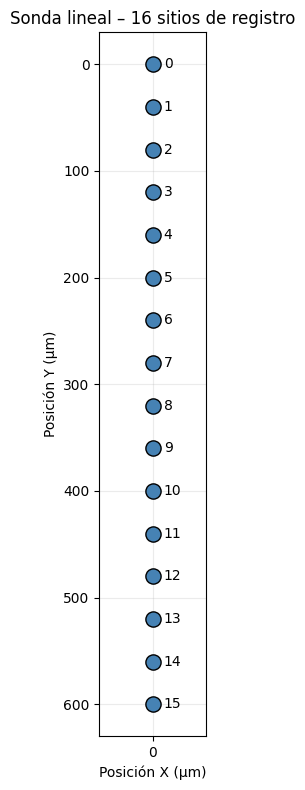

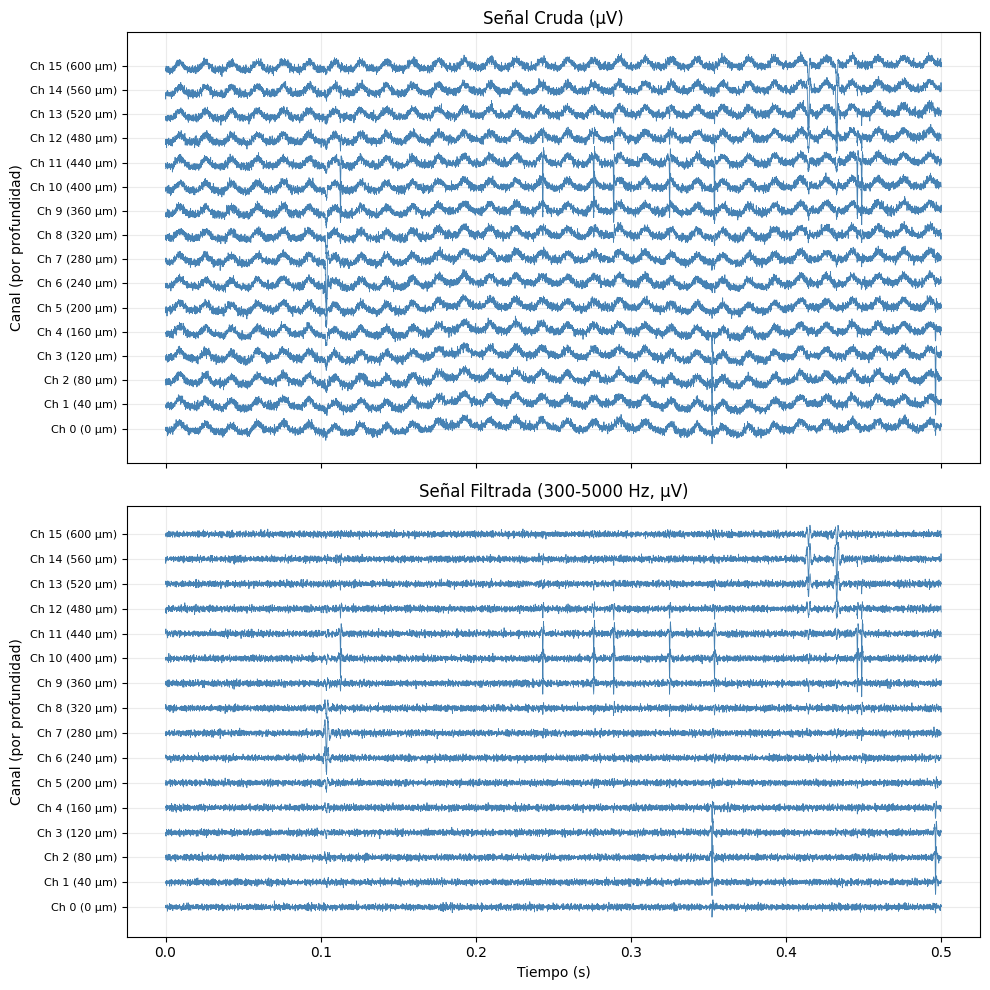

In [70]:
# ✏️ Ejercicio 1
import h5py
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, sosfiltfilt

# ==============================================================================
# PARTE A: Inspección y Lectura de Metadatos
# ==============================================================================


def inspeccionar_y_cargar_metadatos(ruta_h5):
    """Explora la estructura del archivo HDF5 y extrae metadatos clave."""
    with h5py.File(ruta_h5, 'r') as f:
        print('=== ESTRUCTURA DEL ARCHIVO ===\n')

        def explorar(nombre, objeto):
            if isinstance(objeto, h5py.Group):
                print(f'[Grupo]   {nombre}')
            elif isinstance(objeto, h5py.Dataset):
                print(
                    f'[Dataset] {nombre}  -> shape={objeto.shape},'
                    f' dtype={objeto.dtype}'
                )

        f.visititems(explorar)

        print('\n=== ATRIBUTOS GLOBALES ===')
        for clave, valor in f.attrs.items():
            print(f'{clave}: {valor}')

        # Nombres exactos de atributos especificados en el taller
        fs = f.attrs['frecuencia_muestreo_hz']
        escala = f.attrs['escala_uV_por_bit']
        n_canales = f.attrs.get('n_canales', 16)

        print(f'\n[OK] Frecuencia de muestreo (fs): {fs} Hz')
        print(f'[OK] Factor de conversión: {escala} µV/bit')

    return fs, escala, n_canales


# ==============================================================================
# PARTE B: Visualización Geométrica de la Sonda
# ==============================================================================


def graficar_geometria_sonda(ruta_h5):
    """Grafica la disposición espacial de los sitios de registro en la sonda."""
    with h5py.File(ruta_h5, 'r') as f:
        x = f['geometria/canal_x_um'][:]
        y = f['geometria/canal_y_um'][:]
        n_canales = f.attrs.get('n_canales', len(x))

    fig, ax = plt.subplots(figsize=(4, 8))
    ax.scatter(x, y, s=120, c='steelblue', edgecolors='black', zorder=3)

    for canal in range(n_canales):
        ax.annotate(
            str(canal),
            (x[canal], y[canal]),
            textcoords='offset points',
            xytext=(8, 0),
            fontsize=10,
            va='center',
        )

    ax.set_xlabel('Posición X (µm)')
    ax.set_ylabel('Posición Y (µm)')
    ax.set_title('Sonda lineal – 16 sitios de registro')

    # Ajustes del eje X
    x_centro = np.mean(x)
    ax.set_xlim(x_centro - 50, x_centro + 50)
    ax.set_xticks([x_centro])
    ax.ticklabel_format(axis='x', useOffset=False, style='plain')

    ax.set_aspect('equal')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()


# ==============================================================================
# PARTE C: Preprocesamiento (Conversión, Filtrado y Visualización Multicanal)
# ==============================================================================


def cargar_y_filtrar_datos(ruta_h5, f_low=300, f_high=5000):
    """Carga los datos crudos en HDF5, los convierte a microvoltios

    y aplica un filtro pasa-banda Butterworth (fase cero).
    """
    with h5py.File(ruta_h5, 'r') as f:
        datos_crudos = f['registro/datos'][:]
        y_um = f['geometria/canal_y_um'][:]
        fs = f.attrs['frecuencia_muestreo_hz']
        escala = f.attrs['escala_uV_por_bit']

    # 1. Conversión a microvoltios (float64 para precisión)
    datos_uV = datos_crudos.astype(np.float64) * escala

    # 2. Filtrado pasa-banda (300 - 5000 Hz) con sosfiltfilt para zero-phase shift
    sos = butter(4, [f_low, f_high], btype='bandpass', fs=fs, output='sos')
    datos_filtrados = sosfiltfilt(sos, datos_uV, axis=1)

    return datos_uV, datos_filtrados, y_um, fs


def graficar_trazas_multicanal(
    datos_uV, datos_filtrados, y_um, fs, ventana_s=0.5, inicio_s=0.0
):
    """Grafica paneles comparativos (Crudo vs. Filtrado) ordenados por profundidad."""
    n_canales, n_muestras = datos_uV.shape

    # Ordenar por profundidad
    orden = np.argsort(y_um)
    datos_uV_orden = datos_uV[orden]
    datos_filtrados_orden = datos_filtrados[orden]
    etiquetas_canal = [f'Ch {c} ({y_um[c]:.0f} µm)' for c in orden]

    # Recortar ventana temporal
    n_muestras_ventana = int(ventana_s * fs)
    inicio_idx = int(inicio_s * fs)
    fin_idx = inicio_idx + n_muestras_ventana

    tiempo = np.arange(inicio_idx, fin_idx) / fs

    cruda_ventana = datos_uV_orden[:, inicio_idx:fin_idx]
    filtrada_ventana = datos_filtrados_orden[:, inicio_idx:fin_idx]

    # Graficar
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    separacion = 6 * np.std(cruda_ventana)

    for panel, datos_panel, titulo in [
        (ax1, cruda_ventana, 'Señal Cruda (µV)'),
        (ax2, filtrada_ventana, 'Señal Filtrada (300-5000 Hz, µV)'),
    ]:
        for i in range(n_canales):
            offset = i * separacion
            panel.plot(
                tiempo,
                datos_panel[i] + offset,
                linewidth=0.6,
                color='steelblue',
            )
        panel.set_yticks([i * separacion for i in range(n_canales)])
        panel.set_yticklabels(etiquetas_canal, fontsize=8)
        panel.set_title(titulo)
        panel.set_ylabel('Canal (por profundidad)')

    ax2.set_xlabel('Tiempo (s)')
    plt.tight_layout()
    plt.show()


# ==============================================================================
# EJECUCIÓN PRINCIPAL
# ==============================================================================
if __name__ == '__main__':
    ruta = 'taller2_limpia.h5'

    # Parte A: Inspeccionar
    fs, escala, n_canales = inspeccionar_y_cargar_metadatos(ruta)

    # Parte B: Visualizar sonda
    graficar_geometria_sonda(ruta)

    # Parte C: Preprocesar y Graficar trazado
    datos_uV, datos_filtrados, y_um, fs = cargar_y_filtrar_datos(
        ruta, f_low=300, f_high=5000
    )
    graficar_trazas_multicanal(
        datos_uV,
        datos_filtrados,
        y_um,
        fs,
        ventana_s=0.5,
        inicio_s=0.0,
    )

**P1.**

**Selección múltiple.** La amplitud cae aproximadamente como 1/r, donde r es la distancia entre la
neurona y el sitio. Una neurona está a 20 µm del sitio más cercano. Moviéndose por la sonda a partir
de ese sitio, ¿a qué distancia la amplitud habrá caído a la mitad?

- **a)** unos 35 µm: menos de lo que hay entre dos sitios vecinos
- **b)** unos 40 µm: exactamente el sitio siguiente --> RESPUESTA CORRECTA
- **c)** unos 80 µm: dos sitios más allá
- **d)** unos 200 µm: cinco sitios más allá

**Abierta.** En la señal filtrada busquen un evento que aparezca **en los 16 canales al mismo
tiempo**. ¿Puede eso ser una neurona? Justifiquen en dos frases usando la caída 1/r.

*Su respuesta:*
Nosotras no encontramos (ni creemos que pueda existir) un evento que aparezca simultáneamente con amplitud similar en los 16 canales en una neurona, ya que al caer la amplitud como 1/r, una neurona real produciría una señal fuerte solo en el sitio más cercano y sus vecinas inmediatas. Es mas probable que un evento asi, donde se activen todos los canales al mismo tiempo, se deba a algu artefacto (por ejemplo, ruido eléctrico, movimiento del animal o del electrodo) ya que afecta a toda la sonda por igual.


---
# 2 · Detectar los disparos en 16 canales

## Repaso: el umbral de detección con la mediana

El umbral se pone en `k` veces el nivel de ruido. Pero hay que medir ese nivel sin que los disparos lo
contaminen: si usan la desviación estándar de la señal, los potenciales de acción la inflan, el umbral
sube y se pierde la capacidad de detectarlos. Mientras más potenciales de acción tenga el registro,
peor.

La solución es medir el ruido con la **mediana del valor absoluto de la señal**. Los disparos ocupan
menos del 1 % del tiempo de grabación, así que la mediana los excluye: describe el ruido mucho mejor
que la desviación estándar, que se calcula a partir de la media y por eso es susceptible a los valores
extremos, que son justamente los que queremos detectar.

Falta un detalle de unidades. Para una campana normal de desviación estándar σ, la mediana del valor
absoluto vale siempre 0,6745 · σ. Dividiendo por esa constante, el número queda expresado como si
fuera una desviación estándar, y entonces **`k = 4` significa que el umbral está 4 desviaciones
estándar del ruido por debajo de cero**. Cero es la media, porque el filtro ya quitó
cualquier componente de deriva lenta.

## Lo nuevo en el Taller 2

**Ahora hay 16 canales.** Un PA cruza el umbral en tres o cuatro sitios a la vez, con unas
décimas de milisegundo de diferencia. Si cuentan cada cruce por separado van a contar el mismo
potencial de acción cuatro veces.

La solución estándar tiene tres pasos:

1. Calcular un umbral **por canal** (cada sitio tiene su propio nivel de ruido).
2. Marcar todos los cruces en cada canal.
3. **Fusionar** los cruces que caen dentro de una misma ventana corta (0,5 ms) en un solo evento, y
   quedarse con el instante y el canal donde el voltaje fue **más negativo de todos**. Ese canal se
   llama el **canal pico** del evento.

### ✍️ Ejercicio 2 · Escriban su prompt

Escriban la función `detectar(X, k=4.5, muerto_ms=0.5, fs=15000)` que reciba la señal filtrada de los
16 canales y devuelva dos arreglos:
1. el instante de cada evento en segundos y
2. su canal pico.

Escríbanle a la IA un prompt que incluya los tres pasos de arriba. Dejen el prompt en la celda de
texto y el código que resultó en la celda de código, con comentarios suyos.

**Su prompt:**

In [71]:
# ✍️ Ejercicio 2
import numpy as np


def detectar_spikes_y_extraer_waveforms(
    datos_filtrados,
    fs,
    k=4.5,
    refractario_ms=1.5,
    pre_ms=1.0,
    post_ms=2.0,
):
    """Detecta potenciales de acción (PA) mediante umbral adaptativo (MAD),

    fusiona cruces en el período refractario y extrae los recortes (waveforms).

    Parámetros
    ----------
    datos_filtrados : np.ndarray
        Matriz de señal filtrada de forma (n_canales, n_muestras).
    fs : float
        Frecuencia de muestreo en Hz.
    k : float
        Multiplicador de la desviación estándar robusta (MAD).
    refractario_ms : float
        Período refractario/tiempo muerto en milisegundos (típicamente 1.0 -
        2.0 ms).
    pre_ms : float
        Tiempo antes del pico para la ventana del cutout (ms).
    post_ms : float
        Tiempo después del pico para la ventana del cutout (ms).

    Devuelve
    --------
    tiempos_s : np.ndarray (n_eventos,)
        Instantes de tiempo de cada evento en segundos.
    canales_pico : np.ndarray (n_eventos,)
        Canal donde ocurrió la mayor deflexión negativa.
    waveforms : np.ndarray (n_eventos, n_canales, n_muestras_ventana)
        Recortes multicanal alrededor de cada pico detectado.
    """
    n_canales, n_muestras = datos_filtrados.shape

    # Conversión de milisegundos a muestras
    muestras_refractario = int(np.round((refractario_ms / 1000.0) * fs))
    muestras_pre = int(np.round((pre_ms / 1000.0) * fs))
    muestras_post = int(np.round((post_ms / 1000.0) * fs))
    longitud_ventana = muestras_pre + muestras_post

    # 1. Estimación robusta del ruido (MAD) por canal
    # sigma_n = median(|x|) / 0.6745
    mad = np.median(np.abs(datos_filtrados), axis=1)
    sigma_n = mad / 0.6745
    umbrales = -k * sigma_n  # Deflexiones negativas[cite: 1]

    # 2. Detección de cruces de umbral
    cruces_iniciales = []
    for c in range(n_canales):
        bajo_umbral = datos_filtrados[c] < umbrales[c]
        # Transición de False a True (flanco descendente)
        entradas = np.where(np.diff(bajo_umbral.astype(np.int8)) == 1)[0] + 1

        for m in entradas:
            # Evitar bordes extremos del registro
            if (
                m > muestras_pre
                and m < (n_muestras - muestras_post - muestras_refractario)
            ):
                # Refinar: buscar el mínimo local real dentro del cruce
                ventana_local = datos_filtrados[
                    c, m : m + int(0.5 * muestras_refractario)
                ]
                m_pico = m + np.argmin(ventana_local)
                cruces_iniciales.append(
                    (m_pico, c, datos_filtrados[c, m_pico])
                )

    if not cruces_iniciales:
        return (
            np.array([]),
            np.array([], dtype=int),
            np.array([]).reshape(0, n_canales, longitud_ventana),
        )

    # Ordenar cruces cronológicamente
    cruces_iniciales.sort(key=lambda x: x[0])
    cruces_dtype = [
        ('muestra', 'i8'),
        ('canal', 'i4'),
        ('amplitud', 'f8'),
    ]
    cruces_arr = np.array(cruces_iniciales, dtype=cruces_dtype)

    # 3. Fusionar eventos dentro del Período Refractario / Tiempo Muerto[cite: 1]
    tiempos_muestras = []
    canales_pico = []
    idx = 0
    total_cruces = len(cruces_arr)

    while idx < total_cruces:
        t0 = cruces_arr['muestra'][idx]
        # Agrupar cruces que coinciden dentro de la ventana refractaria
        j = idx
        while (
            j < total_cruces
            and (cruces_arr['muestra'][j] - t0) <= muestras_refractario
        ):
            j += 1

        grupo = cruces_arr[idx:j]
        # Seleccionar el canal con la deflexión más negativa como canal pico
        idx_pico = np.argmin(grupo['amplitud'])
        tiempos_muestras.append(grupo['muestra'][idx_pico])
        canales_pico.append(grupo['canal'][idx_pico])

        idx = j  # Saltar el grupo fusionado

    # 4. Extracción de Recortes (Cutouts / Waveforms)
    n_eventos = len(tiempos_muestras)
    waveforms = np.zeros(
        (n_eventos, n_canales, longitud_ventana), dtype=np.float64
    )

    for i, m_pico in enumerate(tiempos_muestras):
        inicio = m_pico - muestras_pre
        fin = m_pico + muestras_post
        waveforms[i] = datos_filtrados[:, inicio:fin]

    tiempos_s = np.array(tiempos_muestras) / fs
    canales_pico = np.array(canales_pico, dtype=int)

    return tiempos_s, canales_pico, waveforms


if __name__ == '__main__':
    # Usando datos_filtrados y fs generados previamente en el Ejercicio 1
    tiempos_s, canales_pico, waveforms = detectar_spikes_y_extraer_waveforms(
        datos_filtrados=datos_filtrados,
        fs=fs,
        k=4.5,
        refractario_ms=0.5,  # Período refractario biológicamente válido (~1.5 ms)
        pre_ms=1.0,
        post_ms=2.0,
    )

    print('=== RESULTADOS DEL EJERCICIO 2 ===')
    print(f'Eventos totales detectados: {len(tiempos_s)}')
    print(f'Dimensiones de la matriz de waveforms: {waveforms.shape}')
    print(f'Primeros 5 tiempos (s): {np.round(tiempos_s[:5], 4)}')
    print(f'Primeros 5 canales pico: {canales_pico[:5]}')

# ==============================================================================
# PUNTO ABIERTO
# ==============================================================================

# Prueba con 0.2 ms
t_02, ch_02, _ = detectar_spikes_y_extraer_waveforms(
    datos_filtrados=datos_filtrados, fs=fs, k=4.5, refractario_ms=0.2
)

# Prueba con 0.5 ms
t_05, ch_05, _ = detectar_spikes_y_extraer_waveforms(
    datos_filtrados=datos_filtrados, fs=fs, k=4.5, refractario_ms=0.5
)

# Prueba con 5.0 ms
t_50, ch_50, _ = detectar_spikes_y_extraer_waveforms(
    datos_filtrados=datos_filtrados, fs=fs, k=4.5, refractario_ms=5.0
)

print(f"Eventos detectados con 0.2 ms: {len(t_02)}")
print(f"Eventos detectados con 0.5 ms: {len(t_05)}")
print(f"Eventos detectados con 5.0 ms: {len(t_50)}")

=== RESULTADOS DEL EJERCICIO 2 ===
Eventos totales detectados: 2727
Dimensiones de la matriz de waveforms: (2727, 16, 45)
Primeros 5 tiempos (s): [0.1035 0.1058 0.1127 0.2431 0.2759]
Primeros 5 canales pico: [ 7  7 11 11 11]
Eventos detectados con 0.2 ms: 4133
Eventos detectados con 0.5 ms: 2727
Eventos detectados con 5.0 ms: 2134


**P2.**

**Selección múltiple.** Vuelvan a correr la detección sobre la grabación limpia con `muerto_ms = 0.2`
en vez de 0,5. Salen más eventos. ¿De dónde salen?

- **a)** de neuronas más lejanas, que antes no cruzaban el umbral
- **b)** del mismo disparo, contado varias veces---->Respuesta correcta
- **c)** del umbral, que se recalcula más bajo
- **d)** del filtro, que deja pasar más ruido

**Abierta.** Digan cuántos eventos detectaron con 0,5 ms y cuántos con 0,2 ms, y expliquen en una
frase por qué 0,5 ms es una elección razonable y 5 ms no lo sería.

*Su respuesta:*
Con muerto_ms=0.5 ms detectamos 2727 eventos, y con 0.2 ms, 4133 . Este aumento se debe a que: como la ventana es más corta, ya no se alcanzan a agrupar los cruces del mismo disparo en los distintos canales, por lo que se termina contando el mismo potencial de acción varias veces. Por eso 0.5 ms es un buen valor, ya que es lo suficientemente ancho para juntar esos cruces que llegan casi al tiempo, pero no tan ancho como para mezclar dos disparos reales, distintos de la misma neurona y perder información.

---
# 3 · Dos niveles de medida


Un **evento** es un potencial de acción, no un cruce del umbral. El mismo disparo cruza el
umbral en varios electrodos a la vez, y el detector fusiona esos cruces en uno solo. Para
escoger el canal pico ya tuvo que mirar los 16 canales, pero no guardó nada más.

Por eso la detección de la sección 2 devuelve **dos vectores, uno por evento**: el instante y
el canal pico. Lo primero que hace esta sección es volver a la señal filtrada y recortar una
ventana alrededor de cada instante, en los 16 canales. Ahí aparece la dimensión de canales:

- formas de onda: **eventos × 16 canales × muestras**
- perfil de amplitud, el valor del valle en cada electrodo: **eventos × 16 canales**

De ese perfil salen la amplitud y el centroide.

Todo lo que sigue se mide sobre uno de dos niveles: cada evento, o un grupo ya formado. Las
del segundo nivel no se pueden calcular antes de agrupar, así que no sirven para agrupar. Y
de las del primer nivel, **tres son las que entran a K-means**: son las de la última columna,
y son las que se explican abajo.

| medida | se mide sobre | qué es | ¿agrupa? |
|---|---|---|---|
| instante | cada evento | el momento del valle, en segundos | — |
| canal pico | cada evento | el electrodo donde el voltaje fue más negativo | — |
| perfil de amplitud | cada evento | los 16 valores del valle, uno por electrodo | — |
| **amplitud** | cada evento | el mayor de esos 16 valores | **sí** |
| **media anchura del valle** | cada evento | ancho a media profundidad, en el canal pico | **sí** |
| **centroide de profundidad** | cada evento | promedio de las posiciones, ponderado por el perfil | **sí** |
| número de disparos | un grupo | cuántos eventos quedaron en él | — |
| violaciones del refractario | un grupo | fracción de intervalos menores a 2 ms | — |
| autocorrelograma | un grupo | intervalos entre sus propios disparos | — |
| distribución de amplitudes | un grupo | histograma de la amplitud de sus eventos | — |
| pendiente de caída espacial | un grupo | cómo cae la amplitud al alejarse del canal pico | — |
| razón pico / valle | un grupo | medida sobre la forma de onda promedio del grupo | — |
| correlograma cruzado | dos grupos | intervalos entre los disparos de uno y otro | — |


En esta sección van las tres del primer nivel.


## Tres características de cada PA que van a usar para agruparlos en unidades

**1 · La amplitud.** El valor mínimo del valle en el canal pico, en microvoltios. Depende de dos cosas
a la vez: de qué tan grande sea la neurona y de qué tan cerca esté de la sonda. Recuerden: dos
neuronas distintas pueden llegar con la misma amplitud desde distancias distintas.

Las tres figuras que siguen son **el mismo evento**, medido de tres formas.

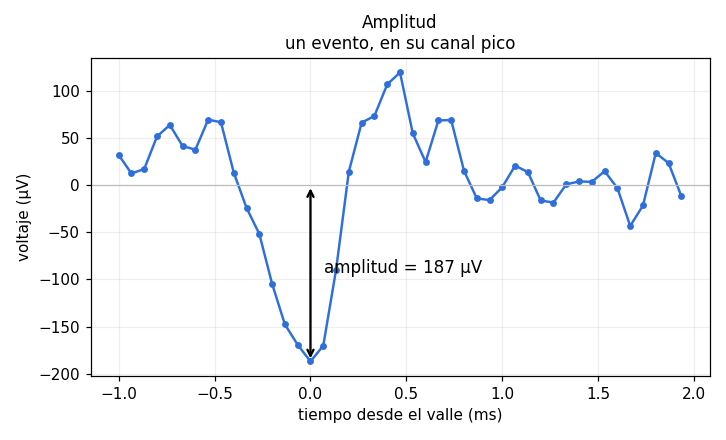

In [72]:
#Corran esta celda.
from IPython.display import Image, display
display(Image("car1_amplitud.png"))

**2 · La media anchura del valle.** El ancho del valle medido a la mitad de su profundidad, en
milisegundos. Distingue neuronas que la amplitud no distingue, porque depende del tipo de célula y no
de la distancia a la que esté.

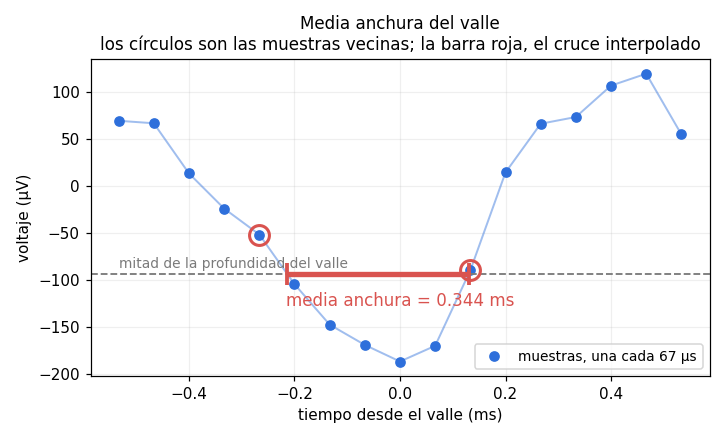

In [73]:
#Corran esta celda.
display(Image("car2_anchura.png"))

⚠️ **Trampa importante.** El potencial de acción completo dura entre 0,6 y 1,4 ms, así que a 15 000
muestras por segundo caben entre 9 y 21 muestras. El problema no es ese. Es que **la media anchura del
valle abarca sólo unas 5 muestras** en las unidades angostas y 9 en las anchas, y si la miden contando
muestras enteras, el resultado sólo puede saltar de 67 en 67 µs. Perderían resolución y no estimarían
la anchura del valle exacta: la nube de mediciones les sale como un peine. Hay que **interpolar
linealmente entre muestras** para encontrar dónde exactamente la señal cruza la mitad de la
profundidad.

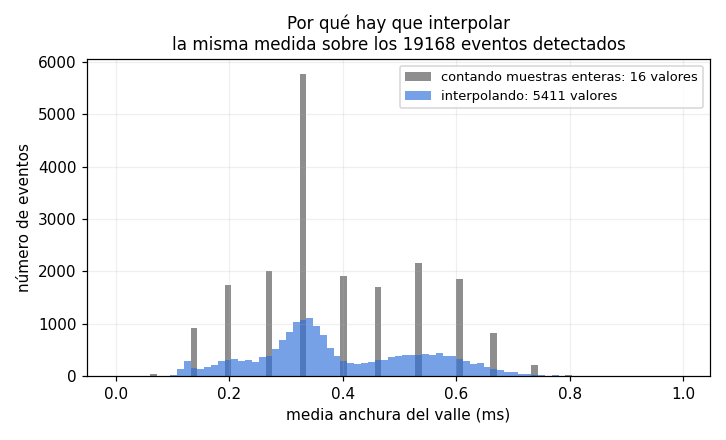

In [74]:
#Corran esta celda.
display(Image("car3_interpolar.png"))

**3 · El centroide de profundidad.** Los sitios de la sonda están en posiciones fijas: el primero a
0 µm de la punta, el segundo a 40, y así hasta 600. Un mismo disparo llega a varios sitios con
amplitudes distintas, y de ahí se estima **a qué profundidad está la neurona que lo produjo**: es el
promedio de las posiciones de los sitios, ponderado por la amplitud que el disparo alcanzó en cada
uno.

El evento de las figuras anteriores llega con 122 µV al sitio de 200 µm, 187 µV al de 240 y 69 µV al
de 280. Su centroide es

(200·122 + 240·187 + 280·69) / (122 + 187 + 69) = **234 µm**

Los otros trece sitios no entran en la cuenta. Sólo se usan aquellos donde la amplitud supera el 30 %
del máximo, que en este evento son 56 µV, porque en los sitios lejanos lo que se mide es ruido y
arrastraría el centroide hacia la mitad de la sonda.

Fíjense en algo: el centroide **se calcula sobre cada disparo, pero lo que estima es una propiedad de
la neurona**, no de ese disparo en particular. Por eso separa tan bien. Cada potencial de acción trae,
en su perfil de amplitudes, una medición ruidosa de dónde está la célula que lo disparó.

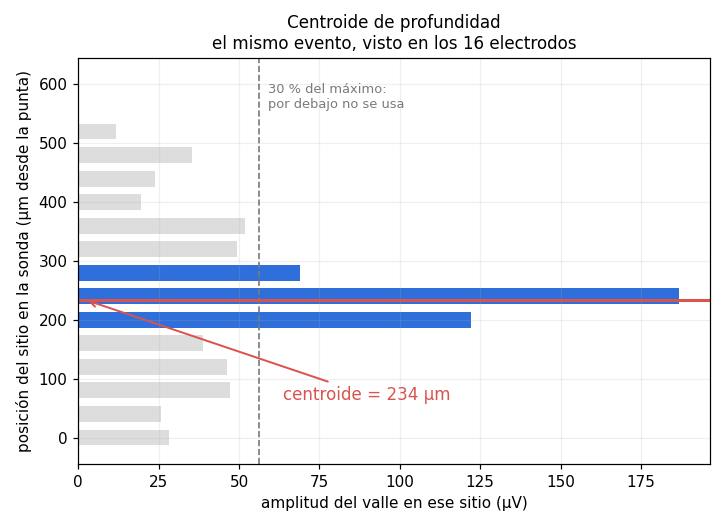

In [75]:
#Corran esta celda
display(Image("car4_centroide.png"))

### ✏️ Ejercicio 3

**a)** Extraigan la forma de onda de cada evento en los 16 canales, desde 1,0 ms antes hasta 2,0 ms
después del instante detectado. El resultado es un arreglo de tres dimensiones: eventos × canales ×
muestras.

**b)** Calculen las tres características para cada evento.

**c)** Grafiquen las tres nubes de puntos posibles con esas tres características, en tres paneles.

=== RESULTADOS DEL EJERCICIO 3 ===
Forma de la matriz de características: (2669, 3)
Primeros 3 eventos [Amplitud(uV), Ancho(ms), Centroide(um)]:
[[1.7757e+02 6.1000e-01 2.7370e+02]
 [5.7460e+01 2.2000e-01 2.8754e+02]
 [1.6726e+02 2.9000e-01 4.3613e+02]]


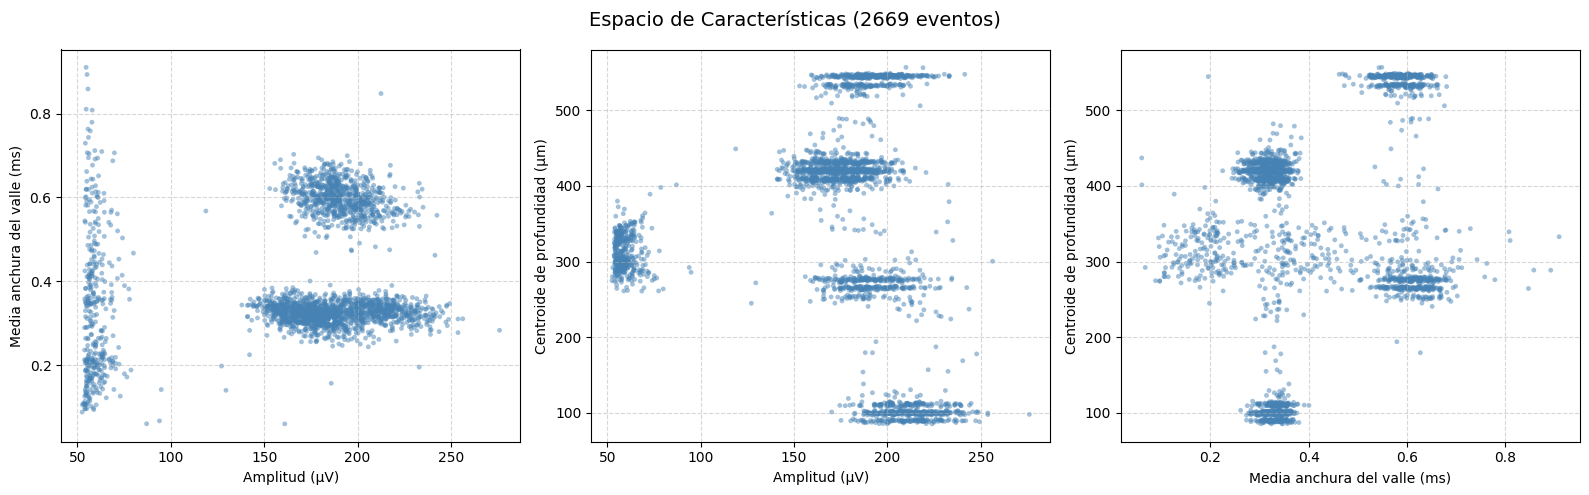

In [76]:
# ✏️ Ejercicio 3
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# PARTE A: Extracción de Formas de Onda (Alineada con Ejercicio 2)
# ==============================================================================


def extraer_formas_onda(
    datos_filtrados, tiempos_s, fs=15000, pre_ms=1.0, post_ms=2.0
):
    """Recorta las ventanas temporales en los 16 canales alrededor de cada evento.

    Asegura descartar eventos que estén demasiado cerca de los bordes.
    """
    n_canales, n_muestras_total = datos_filtrados.shape
    pre_muestras = int(np.round((pre_ms / 1000.0) * fs))
    post_muestras = int(np.round((post_ms / 1000.0) * fs))

    muestras_evento = np.round(np.asarray(tiempos_s) * fs).astype(int)

    formas_onda = []
    idx_validos = []

    for i, m in enumerate(muestras_evento):
        inicio = m - pre_muestras
        fin = m + post_muestras
        if inicio >= 0 and fin <= n_muestras_total:
            formas_onda.append(datos_filtrados[:, inicio:fin])
            idx_validos.append(i)

    formas_onda = np.array(formas_onda)  # (n_eventos_validos, 16, n_ventana)
    idx_validos = np.array(idx_validos, dtype=int)

    n_descartados = len(tiempos_s) - len(idx_validos)
    if n_descartados > 0:
        print(
            f'[INFO] Se descartaron {n_descartados} eventos por estar en los'
            ' bordes de la grabación.'
        )

    return formas_onda, idx_validos


# ==============================================================================
# PARTE B: Extracción de Características Biofísicas
# ==============================================================================


def calcular_caracteristicas(
    formas_onda, canal_pico, y_um_canales, fs=15000, frac_centroide=0.30
):
    """Calcula las 3 características principales por evento:

    1. Amplitud pico (µV, valor positivo).
    2. Media anchura del valle (FWHM en ms) medida en el canal pico.
    3. Centroide de profundidad (µm) ponderado por el perfil espacial.
    """
    n_eventos, n_canales, n_muestras = formas_onda.shape

    # Perfil de amplitud: deflexión máxima negativa (en µV positivos) por canal
    perfil = -formas_onda.min(axis=2)  # (n_eventos, 16)

    # 1. Amplitud Máxima del evento
    amplitud = perfil.max(axis=1)

    # 2. Media Anchura del Valle (Full Width at Half Maximum - FWHM)
    media_anchura_valle = np.zeros(n_eventos)

    for e in range(n_eventos):
        c = canal_pico[e]
        onda = formas_onda[e, c]
        idx_min = np.argmin(onda)
        val_min = onda[idx_min]
        umbral_medio = val_min / 2.0  # Mitad de la deflexión

        # Interpolación hacia la izquierda
        izq = idx_min
        while izq > 0 and onda[izq] < umbral_medio:
            izq -= 1
        if izq < idx_min and onda[izq + 1] != onda[izq]:
            frac = (umbral_medio - onda[izq]) / (onda[izq + 1] - onda[izq])
            t_izq = izq + frac
        else:
            t_izq = izq

        # Interpolación hacia la derecha
        der = idx_min
        while der < n_muestras - 1 and onda[der] < umbral_medio:
            der += 1
        if der > idx_min and onda[der] != onda[der - 1]:
            frac = (umbral_medio - onda[der - 1]) / (
                onda[der] - onda[der - 1]
            )
            t_der = der - 1 + frac
        else:
            t_der = der

        media_anchura_valle[e] = (t_der - t_izq) / fs * 1000.0  # ms

    # 3. Centroide de Profundidad Espacial (µm)
    # Descarta canales lejanos cuyo perfil sea < 30% de la amplitud máxima
    umbral_centroide = frac_centroide * amplitud[:, None]
    perfil_filtrado = np.where(perfil >= umbral_centroide, perfil, 0.0)

    centroide_profundidad = (
        perfil_filtrado * y_um_canales[None, :]
    ).sum(axis=1) / perfil_filtrado.sum(axis=1)

    return amplitud, media_anchura_valle, centroide_profundidad


# ==============================================================================
# PARTE C: Visualización del Espacio de Características
# ==============================================================================


def graficar_espacio_caracteristicas(
    amplitud, media_anchura_valle, centroide_profundidad
):
    """Grafica las proyecciones 2D de las tres características calculadas."""
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    pares = [
        (
            amplitud,
            media_anchura_valle,
            'Amplitud (µV)',
            'Media anchura del valle (ms)',
        ),
        (
            amplitud,
            centroide_profundidad,
            'Amplitud (µV)',
            'Centroide de profundidad (µm)',
        ),
        (
            media_anchura_valle,
            centroide_profundidad,
            'Media anchura del valle (ms)',
            'Centroide de profundidad (µm)',
        ),
    ]

    for ax, (x, y, xlabel, ylabel) in zip(axes, pares):
        ax.scatter(x, y, s=12, alpha=0.5, color='steelblue', edgecolors='none')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(
        f'Espacio de Características ({len(amplitud)} eventos)', fontsize=14
    )
    plt.tight_layout()
    plt.show()


# ==============================================================================
# EJECUCIÓN PRINCIPAL
# ==============================================================================
if __name__ == '__main__':
    # 1. Detectar eventos (función del Ejercicio 2)
    tiempos_s, canales_pico, _ = detectar_spikes_y_extraer_waveforms(
        datos_filtrados=datos_filtrados,
        fs=fs,
        k=4.5,
        refractario_ms=1.5,
    )

    # 2. Extraer formas de onda y filtrar válidos (evita bordes)
    formas_onda, idx_validos = extraer_formas_onda(
        datos_filtrados=datos_filtrados,
        tiempos_s=tiempos_s,
        fs=fs,
        pre_ms=1.0,
        post_ms=2.0,
    )

    canales_pico_validos = canales_pico[idx_validos]

    # 3. Calcular las 3 características
    amplitud, media_anchura_valle, centroide_profundidad = (
        calcular_caracteristicas(
            formas_onda=formas_onda,
            canal_pico=canales_pico_validos,
            y_um_canales=y_um,  # Array de profundidades original
            fs=fs,
        )
    )

    # 4. Matriz consolidada de características (n_eventos_validos, 3)
    caracteristicas = np.column_stack(
        [amplitud, media_anchura_valle, centroide_profundidad]
    )

    print('=== RESULTADOS DEL EJERCICIO 3 ===')
    print(f'Forma de la matriz de características: {caracteristicas.shape}')
    print('Primeros 3 eventos [Amplitud(uV), Ancho(ms), Centroide(um)]:')
    print(np.round(caracteristicas[:3], 2))

    # 5. Graficar espacio de características
    graficar_espacio_caracteristicas(
        amplitud, media_anchura_valle, centroide_profundidad)

**P3.**

**Selección múltiple.** ¿Cuál de estas medidas **no** se puede calcular sobre un evento aislado?

- **a)** la amplitud
- **b)** la media anchura del valle
- **c)** el centroide de profundidad
- **d)** las violaciones del período refractario----->Respuesta correcta

**Abierta.** De los tres paneles de la nube de puntos, ¿cuál separa mejor los grupos, y por qué esa
pareja de características y no otra? Digan si hay un par de grupos que se confunda en un panel y se
separe en otro.

*Su respuesta:*

Nosotras creemos que el paner del medio (Centroide de profundidad vs Amplitud) es el mejor panel de la nube de puntos ya que tiene los grupos bien definidos. Ademas, la amplitud mide que tan fuerte se ve el disparo y el centroide nos dice donde esta la neurona en la sonda, por lo tanto, al comparar dos medidas que miden cosas diferentes (la señal real de lo que es ruido y por posicion) nos da una idea real de la separacion. Por otro lado si hay un grupo que se confunda en uno y se separe en otro. En este caso el grupo se puede observar en la tercera grafica, donde lo que antes se encontraba aislado cerca del eje "y" de la grafica ahora se encuentra disperso por el eje "x" confundiendo los grupos que estaban bien definidos por el centroide y la anchura del valle.


---
# Segunda parte · La grabación ruidosa

Aquí empieza el trabajo real. A partir de esta sección todo se hace sobre `taller2_ruidosa.h5`.

---
# 4 · La grabación ruidosa, y agrupar con K-means

Si escribieron las funciones bien, la primera parte de esta sección son cuatro líneas: cargar,
filtrar, detectar, extraer características. Nada de copiar y pegar con cambios.

⚠️ **Trampa.** Aquí es donde se paga haber dejado números escritos dentro de una función. El caso más
común es el umbral: si en la sección 2 guardaron el valor en microvoltios que les dio en la grabación
limpia, en vez de recalcular `k · MAD` sobre la señal que reciban, aquí les va a fallar en silencio.
Esta grabación tiene más ruido de fondo, así que su MAD es mayor y el umbral correcto es otro. Con el
umbral viejo, que es más bajo, van a detectar muchísimos cruces que no son disparos.

Lo mismo vale para cualquier otra cosa que hayan fijado mirando la primera grabación: el nombre del
archivo, el número de grupos, o dar por hecho que el archivo no trae protocolo de estímulos. Si les
toca abrir una función y cambiarle algo para que corra aquí, eso es lo que hay que arreglar.

Lo que van a encontrar es que aparecen muchos más eventos y que la nube de puntos ya no son cuatro
manchas limpias. Hay tres razones, y conviene tenerlas claras desde ya:

**Actividad multiunitaria (MUA).** La amplitud cae con la distancia, así que hay muchísimas neuronas
lejanas cuyos disparos llegan a la sonda debilitados. Individualmente son demasiado pequeños para
identificarlos, pero son tantos que en conjunto cruzan el umbral todo el tiempo. Forman una nube sin
fronteras, pegada al umbral por debajo. **La MUA es actividad neuronal de verdad**: son potenciales de
acción, sólo que no se puede decir de cuál neurona vino cada uno.

**Artefactos.** Eventos eléctricos o mecánicos que no son neuronales: el equipo, el movimiento del
animal, el estímulo. Cruzan el umbral y se detectan igual que un disparo.

**Cruces del umbral por ruido térmico.** El ruido de fondo es aleatorio y de vez en cuando, por azar,
baja lo suficiente. No son disparos de nada.

## K-means y el problema de elegir k

**K-means** reparte los puntos en `k` grupos, poniendo cada punto en el grupo cuyo centro le queda más
cerca. Ya lo usaron en el Taller 1. Aquí hay dos cosas nuevas.

**Hay que estandarizar las características antes.** K-means mide distancias, y las tres
características están en unidades que no se pueden comparar: el centroide va de 0 a 600 µm, la
anchura de 0,1 a 0,9 ms y la amplitud de 90 a 300 µV. Si no se corrige, la distancia queda dominada por el
centroide y las otras características no cuentan. La corrección es restarle a cada característica su
media y dividirla por su desviación estándar: exactamente el Z-score que vieron en la sesión de
estadística, usado aquí para otra cosa.

**Elegir k mal tiene dos formas de fallar, y son opuestas.**

- Si `k` es **muy pequeño**, dos neuronas distintas caen en el mismo grupo. Y hay una trampa: la nube
  de MUA es enorme, así que se lleva varios centros y deja pocos para las neuronas de verdad.
- Si `k` es **muy grande**, una sola neurona queda partida en dos grupos.

No hay forma de acertar de una. Lo que se hace en la práctica es pasarse de `k` a propósito y después
**arreglar**: descartar lo que no sirve y unir lo que quedó partido. Las secciones 5, 6 y 7 son
exactamente eso.

### ✏️ Ejercicio 4

**a)** Corran su pipeline completo sobre la grabación ruidosa y grafiquen las mismas tres nubes de la
sección 3.

**b)** Estandaricen sus tres características.

**c)** Corran K-means con al menos tres valores distintos de `k` (por ejemplo 8, 16 y 25) y grafiquen
el resultado de cada uno sobre el panel de centroide contra anchura.

**d)** Elijan un `k` para seguir trabajando.


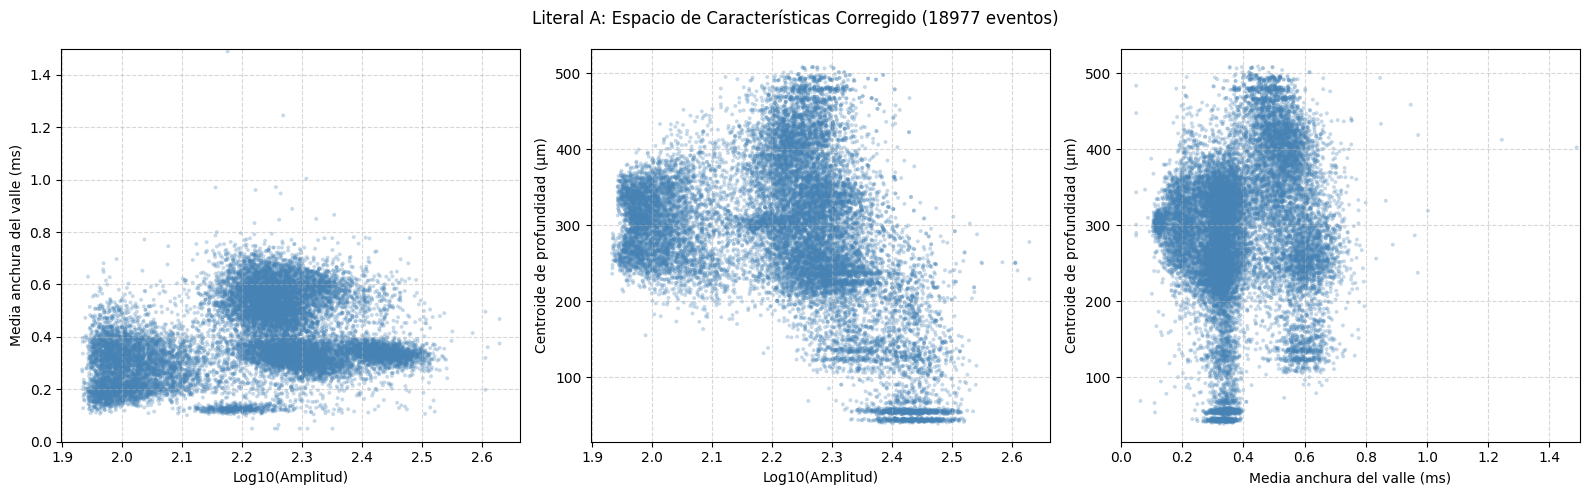

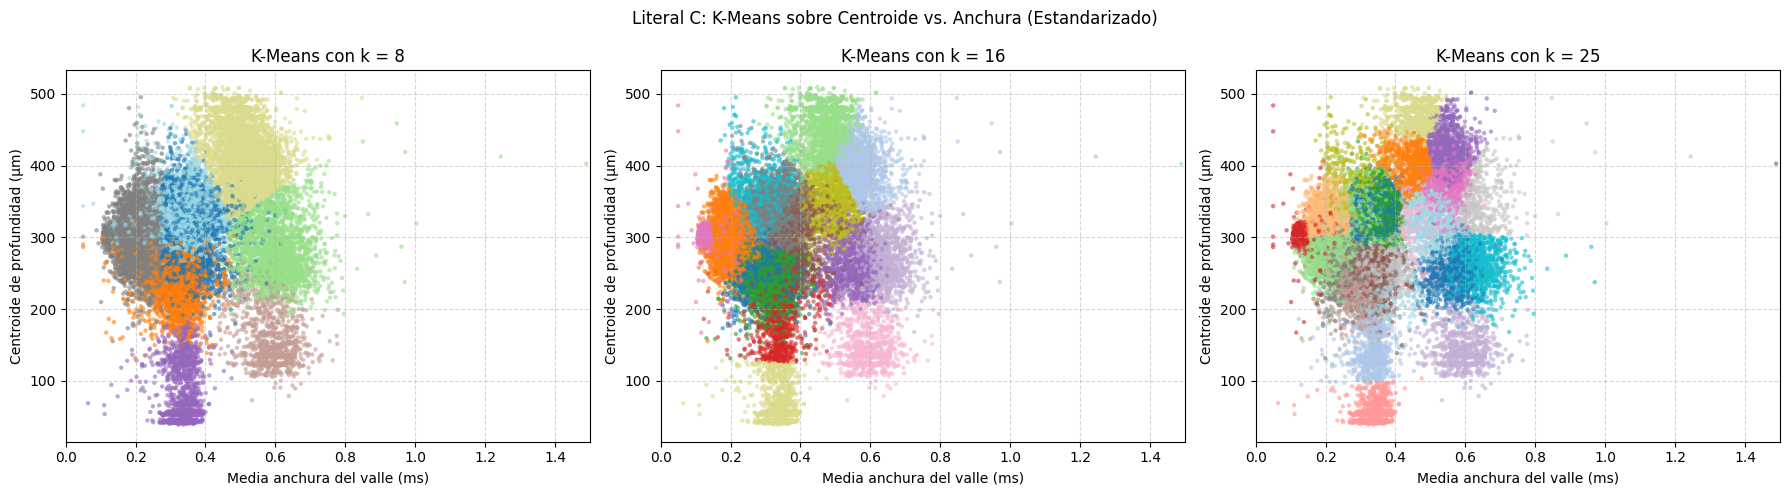

Literal D: Se ha seleccionado k = 16 para continuar con el análisis.


In [77]:
# ✏️ Ejercicio 4

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import h5py
from scipy.signal import butter, sosfiltfilt

# ==============================================================================
# PIPELINE COMPLETO PARAMETRIZADO
# ==============================================================================
# Nota: Se asume que las funciones detectar_spikes_y_extraer_waveforms,
# extraer_formas_onda y calcular_caracteristicas ya están definidas en tu entorno.

def ejecutar_pipeline_completo(ruta_h5, k_umbral=4.5, refractario_ms=1.5):
    """Ejecuta el pipeline completo desde la lectura hasta la detección y extracción
    de características para cualquier archivo HDF5 de la práctica.
    """
    # 1. Cargar metadatos y datos crudos
    with h5py.File(ruta_h5, 'r') as f:
        datos_crudos = f['registro/datos'][:]
        y_um = f['geometria/canal_y_um'][:]
        fs = f.attrs['frecuencia_muestreo_hz']
        escala = f.attrs['escala_uV_por_bit']

    # 2. Convertir a microvoltios y filtrar (300 - 5000 Hz)
    datos_uV = datos_crudos.astype(np.float64) * escala
    sos = butter(4, [300, 5000], btype='bandpass', fs=fs, output='sos')
    datos_filtrados = sosfiltfilt(sos, datos_uV, axis=1)

    # 3. Detección de spikes y extracción de waveforms
    # IMPORTANTE: Al pasar k_umbral=4.5 evitamos la trampa del taller. El umbral
    # se calculará dinámicamente usando el MAD de este archivo ruidoso.
    tiempos_s, canales_pico, _ = detectar_spikes_y_extraer_waveforms(
        datos_filtrados=datos_filtrados,
        fs=fs,
        k=k_umbral,
        refractario_ms=refractario_ms,
    )

    # 4. Extraer waveforms y validar eventos en los bordes
    formas_onda, idx_validos = extraer_formas_onda(
        datos_filtrados=datos_filtrados,
        tiempos_s=tiempos_s,
        fs=fs,
        pre_ms=1.0,
        post_ms=2.0,
    )

    tiempos_s_validos = tiempos_s[idx_validos]
    canales_pico_validos = canales_pico[idx_validos]

    return {
        'datos_filtrados': datos_filtrados,
        'y_um': y_um,
        'fs': fs,
        'tiempos_s': tiempos_s_validos,
        'canales_pico': canales_pico_validos,
        'formas_onda': formas_onda,
    }

ruta_ruidosa = "taller2_ruidosa.h5"

# 1. Correr el pipeline sobre la señal ruidosa
res_ruidosa = ejecutar_pipeline_completo(
    ruta_ruidosa, k_umbral=4.5, refractario_ms=0.5
)

# ==============================================================================
# REFINAMIENTO DEL CÁLCULO DE ANCHURA (Evita Outliers)
# ==============================================================================
def calcular_caracteristicas_robustas(formas_onda, canal_pico, y_um_canales, fs=15000, frac_centroide=0.30):
    """Calcula características limitando la anchura máxima a un rango biológico (0 a 2.5 ms)."""
    n_eventos, n_canales, n_muestras = formas_onda.shape
    perfil = -formas_onda.min(axis=2)
    amplitud = perfil.max(axis=1)
    media_anchura_valle = np.zeros(n_eventos)

    for e in range(n_eventos):
        c = canal_pico[e]
        onda = formas_onda[e, c]
        idx_min = np.argmin(onda)
        val_min = onda[idx_min]
        umbral_medio = val_min / 2.0

        max_muestras_lado = int(np.round(1.5 * fs / 1000.0))

        # Hacia la izquierda
        izq = idx_min
        puntos_izq = 0
        while izq > 0 and onda[izq] < umbral_medio and puntos_izq < max_muestras_lado:
            izq -= 1
            puntos_izq += 1
        if izq < idx_min and onda[izq + 1] != onda[izq]:
            frac = (umbral_medio - onda[izq]) / (onda[izq + 1] - onda[izq])
            t_izq = izq + frac
        else:
            t_izq = izq

        # Hacia la derecha
        der = idx_min
        puntos_der = 0
        while der < n_muestras - 1 and onda[der] < umbral_medio and puntos_der < max_muestras_lado:
            der += 1
            puntos_der += 1
        if der > idx_min and onda[der] != onda[der - 1]:
            frac = (umbral_medio - onda[der - 1]) / (onda[der] - onda[der - 1])
            t_der = der - 1 + frac
        else:
            t_der = der

        anchura_ms = (t_der - t_izq) / fs * 1000.0
        media_anchura_valle[e] = np.clip(anchura_ms, 0.05, 2.5)

    umbral_centroide = frac_centroide * amplitud[:, None]
    perfil_filtrado = np.where(perfil >= umbral_centroide, perfil, 0.0)
    centroide_profundidad = (perfil_filtrado * y_um_canales[None, :]).sum(axis=1) / perfil_filtrado.sum(axis=1)

    return amplitud, media_anchura_valle, centroide_profundidad

# Recalcular características con el filtro robusto
amplitud, media_anchura, centroide = calcular_caracteristicas_robustas(
    res_ruidosa['formas_onda'],
    res_ruidosa['canales_pico'],
    res_ruidosa['y_um'],
    fs=res_ruidosa['fs'],
)

# ==============================================================================
# LITERAL A y B: Transformación Logarítmica y Nubes de Dispersión
# ==============================================================================
# CUMPLIENDO LA REGLA: z(centroide, log amp_10, media anchura)
log_amp = np.log10(amplitud)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Graficamos usando el logaritmo de la amplitud para ver mejor la distribución
axes[0].scatter(log_amp, media_anchura, s=8, alpha=0.3, color='steelblue', edgecolors='none')
axes[0].set_xlabel('Log10(Amplitud)')
axes[0].set_ylabel('Media anchura del valle (ms)')
axes[0].set_ylim(0, 1.5)

axes[1].scatter(log_amp, centroide, s=8, alpha=0.3, color='steelblue', edgecolors='none')
axes[1].set_xlabel('Log10(Amplitud)')
axes[1].set_ylabel('Centroide de profundidad (µm)')

axes[2].scatter(media_anchura, centroide, s=8, alpha=0.3, color='steelblue', edgecolors='none')
axes[2].set_xlabel('Media anchura del valle (ms)')
axes[2].set_ylabel('Centroide de profundidad (µm)')
axes[2].set_xlim(0, 1.5)

for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle(f'Literal A: Espacio de Características Corregido ({len(amplitud)} eventos)')
plt.tight_layout()
plt.show()

# ==============================================================================
# LITERAL B (Continuación): Estandarización estricta
# ==============================================================================
# Agrupamos en el orden exacto que pide el taller
caracteristicas_para_kmeans = np.column_stack([centroide, log_amp, media_anchura])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(caracteristicas_para_kmeans)

# ==============================================================================
# LITERAL C: K-Means con Varios K (Panel Centroide vs. Anchura)
# ==============================================================================
ks_a_evaluar = [8, 16, 25]
fig, axes = plt.subplots(1, len(ks_a_evaluar), figsize=(18, 5))

modelos_kmeans = {}

for ax, k in zip(axes, ks_a_evaluar):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans.fit_predict(X_scaled)
    modelos_kmeans[k] = (labels_k, kmeans)

    ax.scatter(
        media_anchura,
        centroide,
        c=labels_k,
        cmap='tab20',
        s=10,
        alpha=0.6,
        edgecolors='none',
    )
    ax.set_title(f'K-Means con k = {k}')
    ax.set_xlabel('Media anchura del valle (ms)')
    ax.set_ylabel('Centroide de profundidad (µm)')
    ax.set_xlim(0, 1.5)
    ax.grid(True, linestyle='--', alpha=0.5)

fig.suptitle('Literal C: K-Means sobre Centroide vs. Anchura (Estandarizado)')
plt.tight_layout()
plt.show()

# ==============================================================================
# LITERAL D: Selección de K
# ==============================================================================
k_elegido = 16
labels_elegidos, modelo_elegido = modelos_kmeans[k_elegido]
print(f"Literal D: Se ha seleccionado k = {k_elegido} para continuar con el análisis.")

**P4.**

**Selección múltiple.** En la grabación ruidosa aparece una nube ancha, sin fronteras, pegada al
umbral por debajo. ¿De qué está hecha, sobre todo?

- **a)** de artefactos del equipo
- **b)** de actividad multiunitaria: disparos reales de neuronas demasiado lejanas para identificarlas ---->Respuesta Correcta
- **c)** de cruces del umbral por ruido térmico, y de nada más
- **d)** de una sola neurona cuya amplitud varía mucho

**Abierta.** ¿Qué `k` escogieron y con qué argumento? No vale "porque se ve bien": señalen un grupo
que con el `k` más pequeño se vea como dos cosas pegadas, y uno que con el `k` más grande se vea como
la mitad de otro, y digan en qué se nota cada cosa.

*Su respuesta:*
Nosotras elegimos la K = 16 ya que, aunque en el K=12  se pueden ver mas definidas los neuronas o grupos, con el K = 16 nos aseguramos de poder explorar los grupos para despues poder aguparlos con el correlograma cruzado. Con un valor de K mas pequeño como el 8, se puede observar en la derecha un grupo pegado azul que se divide en dos grupos con un k = 12 y se convierte en tres grupos con un K = 16, donde el grupo naranja y azul oscuro estan oegados.

---
# 5 · Las métricas de calidad

Aquí es donde este taller se separa de lo que hace un programa automático. Ya tienen grupos. La
pregunta es cuáles de esos grupos son una neurona.

Estamos en el **segundo nivel de medida** del que habla la sección 3: todo lo que sigue se calcula
sobre un grupo entero, no sobre un disparo suelto. Varias de estas medidas se sacan de la **forma de
onda promedio** del grupo, que es más limpia que cualquier disparo individual porque el ruido se
cancela al promediar.

Son siete medidas tomadas de **bombcell**, una herramienta publicada que hace control de calidad sobre
datos ya agrupados. Los umbrales son los suyos, ajustados a esta sonda.

| medida | qué es | umbral | qué decide |
|---|---|---|---|
| número de picos y valles | Un potencial de acción tiene un valle y a lo sumo dos picos. Si la forma promedio oscila, no es una neurona. | picos ≤ 2 y valles ≤ 2 | ¿es de origen neuronal? |
| duración de la onda | Tiempo del valle al pico de repolarización. | entre 100 y 1150 µs | ¿es de origen neuronal? |
| pendiente de caída espacial | Ajuste de la amplitud contra la distancia al canal pico, en amplitud normalizada por µm. Una neurona se apaga con la distancia; un artefacto llega casi igual a toda la sonda. | más negativa que −0,004 | ¿es de origen neuronal? |
| razón pico / valle | Altura del pico positivo más grande dividida por la profundidad del valle. | por encima de 0,8 es **no somática** | ¿qué parte de la neurona se registró? |
| violaciones del refractario | Fracción de intervalos entre disparos menores a 2 ms. Una neurona no puede dispararse dos veces tan seguido, así que si los hay es porque hay más de una en el grupo. | menos de 1,5 % | ¿una neurona o varias? |
| disparos faltantes | Se ajusta una campana a la distribución de amplitudes. Si el umbral de detección cortó la cola baja, el grupo está incompleto. | menos de 20 % | ¿una neurona o varias? |
| número de disparos | Con muy pocos disparos ninguna de las otras medidas es confiable. | al menos 300 | ¿una neurona o varias? |

Dos notas sobre los umbrales de esta tabla:

**Los valles.** Bombcell exige uno solo; aquí se admiten dos, porque el filtro pasa-banda le agrega un
rizado a las ondas predominantemente positivas y si no las marcaría como ruido.

**La pendiente.** En esta sonda los sitios están cada 40 µm, así que dentro de los 100 µm del ajuste
caben apenas tres. Con tan pocos puntos el criterio es débil: en este registro el artefacto da −0,0042
y la actividad multiunitaria −0,0058, mientras que las unidades bien aisladas dan entre −0,0077 y
−0,0090. **La pendiente sola no alcanza a separar el artefacto**, y quien lo atrapa es el número de
picos. Si suben el umbral para atrapar el artefacto, empiezan a marcar como ruido actividad
multiunitaria que sí es neuronal.

**Por qué la razón pico / valle sube cuando no se registra la zona de disparo.** El electrodo
extracelular no mide el voltaje de la membrana: mide **las corrientes que entran y salen de ella**.
Donde la corriente entra, que es el punto activo por donde pasa el sodio, el exterior se vuelve
negativo, y ese es el valle. Esa corriente tiene que salir por otro lado de la célula, y donde sale el
exterior se vuelve positivo: esos son los picos.

Si el electrodo está junto a la zona donde nace el disparo, domina la corriente que entra: valle
profundo y picos pequeños. Si está sobre un axón por el que el disparo va pasando, ve la onda llegar y
alejarse, y delante y detrás del punto activo la corriente está saliendo, así que los picos crecen
hasta igualar o superar al valle. Junto a una dendrita pasa algo parecido, porque lo que llega ahí es
sobre todo corriente de retorno.

No es que la neurona sea distinta: es que el electrodo está en otra parte de ella. Bombcell llama
**no somáticas** a esas unidades. Son señal neuronal legítima, pero su centroide de profundidad no
dice dónde está el cuerpo de la célula, porque un axón puede venir de lejos.

### Las dos figuras de esta sección

La caída espacial y la razón pico/valle son las dos que menos se entienden por escrito. Así se ven
sobre este mismo registro.

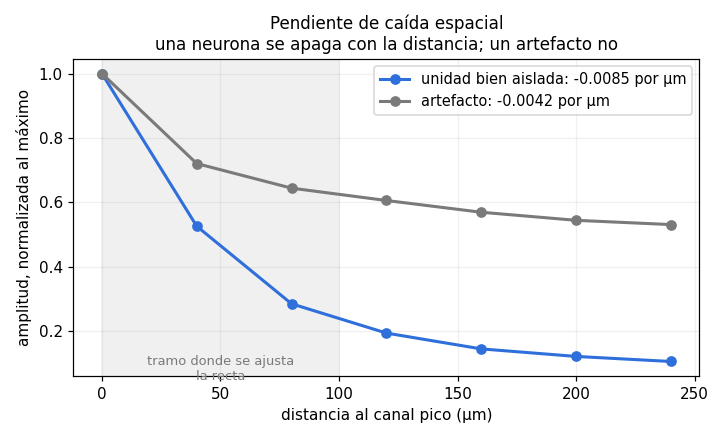

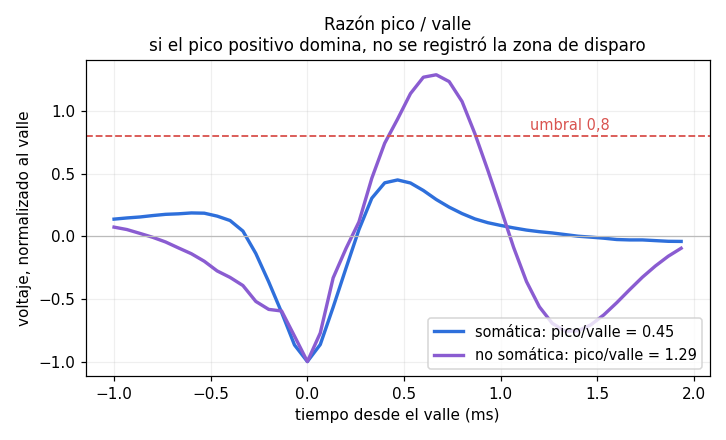

In [78]:
from IPython.display import Image, display
for f in ["car5_caida.png", "car6_razon.png"]:
    display(Image(f))

### ✍️ Ejercicio 5 · Escriban su prompt

Calculen las siete medidas para cada uno de sus grupos y armen una tabla, una fila por grupo.

⚠️ **Trampa: alinear antes de promediar.** Dentro de un grupo no todos los eventos tienen el pico en
el mismo sitio. Si promedian los 16 canales tal cual, están sumando perfiles corridos unos respecto a
otros, y la suma sale aplanada: el grupo parece no decaer con la distancia y lo van a marcar como
ruido, aunque cada evento por separado decaiga bien.

Hay que medir la caída **respecto al canal pico de cada evento**:

1. Para cada evento, tomen la amplitud del valle en los 16 sitios y divídanla por su máximo.
2. Anoten cada uno de esos valores junto con su distancia al canal pico **de ese evento**.
3. Junten los pares de todos los eventos y ajusten una recta, usando sólo las distancias de 100 µm
   o menos.

**Disparos faltantes.** Los disparos de una misma neurona no llegan todos con la misma amplitud:
varían alrededor de un valor típico, así que su histograma tiene forma de campana. Si la neurona es
pequeña o está lejos, **la parte baja de esa campana cae por debajo del umbral de detección**. Esos
disparos ocurrieron, pero nunca se detectaron: están faltando en el grupo, y por eso la tasa de
disparo que midan va a ser menor que la real.

Para estimar cuántos faltan:

1. Hagan el histograma de amplitudes del grupo.
2. Ajusten una campana usando **sólo la mitad que queda por encima del pico del histograma**, que es
   la parte que el umbral no alcanzó a cortar.
3. Calculen qué fracción de esa campana ajustada queda por debajo del umbral. Esa es la estimación de
   lo que falta.

Si el ajuste no converge, eso ya es una respuesta: la distribución no tiene forma de campana, así que
el grupo no es una sola neurona.

**Su prompt:**

In [79]:
# ✍️ Ejercicio 5
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
from scipy.signal import find_peaks


def _fit_gaussiana(x, a, mu, sigma):
    return a * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


def calcular_7_medidas_punto5(
    formas_onda, tiempos_s, labels, y_um, fs=15000, isi_refractario_ms=2.0
):
    clusters_unicos = np.unique(labels)
    filas_tabla = []

    for k in clusters_unicos:
        idx_k = np.where(labels == k)[0]
        n_disparos = len(idx_k)

        # Muestras mínimas para evitar fallos numéricos
        if n_disparos < 10:
            filas_tabla.append({
                'Grupo': int(k),
                'N_Disparos': int(n_disparos),
                'Picos': 0,
                'Valles': 0,
                'Duracion_us': 0.0,
                'Pendiente_Espacial': 0.0,
                'Razon_Pico_Valle': 0.0,
                'Viol_Refractario_%': 0.0,
                'Pct_Faltantes_%': 'Insuficiente',
            })
            continue

        waveforms_k = formas_onda[idx_k]

        # ======================================================================
        # 1. FORMA DE ONDA PROMEDIO Y CANAL PICO
        # ======================================================================
        valle_por_canal_ev = -waveforms_k.min(axis=2)  # (N_eventos, N_canales)
        ch_pico_ev = np.argmax(valle_por_canal_ev, axis=1)
        ch_modal = np.bincount(ch_pico_ev).argmax()

        traza_promedio = waveforms_k[:, ch_modal, :].mean(axis=0)

        # Medida 1: Picos y Valles
        idx_valle = np.argmin(traza_promedio)
        valle_amp = np.abs(traza_promedio[idx_valle])

        picos_pos, _ = find_peaks(traza_promedio, height=0)
        valles_neg, _ = find_peaks(-traza_promedio, height=0)

        # Medida 2: Duración de la onda en µs (valle a pico repolarización)
        picos_posteriores = picos_pos[picos_pos > idx_valle]
        if len(picos_posteriores) > 0:
            idx_pico_repol = picos_posteriores[0]
            duracion_us = (idx_pico_repol - idx_valle) / fs * 1e6
            pico_amp = traza_promedio[idx_pico_repol]
        else:
            duracion_us = (len(traza_promedio) - idx_valle) / fs * 1e6
            pico_amp = np.max(traza_promedio[idx_valle:])

        # Medida 3: Razón pico / valle
        razon_pico_valle = pico_amp / (valle_amp + 1e-6)

        # ======================================================================
        # 2. CAÍDA ESPACIAL ALINEADA EVENTO POR EVENTO (VENTANA <= 100 µm)
        # ======================================================================
        distancias_acumuladas = []
        amplitudes_norm_acumuladas = []

        for i in range(n_disparos):
            ch_p = ch_pico_ev[i]
            amp_pico_ev = valle_por_canal_ev[i, ch_p]

            if amp_pico_ev <= 0:
                continue

            # Normalización individual por evento
            amps_norm = valle_por_canal_ev[i, :] / amp_pico_ev
            distancias = np.abs(y_um - y_um[ch_p])

            # Filtro estricto <= 100 µm
            mask_100 = distancias <= 100.0
            distancias_acumuladas.extend(distancias[mask_100])
            amplitudes_norm_acumuladas.extend(amps_norm[mask_100])

        if len(distancias_acumuladas) > 5:
            res_lineal = np.polyfit(
                distancias_acumuladas, amplitudes_norm_acumuladas, 1
            )
            pendiente_espacial = res_lineal[0]
        else:
            pendiente_espacial = 0.0

        # ======================================================================
        # 3. VIOLACIONES DEL REFRACTARIO (< 2.0 ms)
        # ======================================================================
        tiempos_k = np.sort(tiempos_s[idx_k])
        isis_ms = np.diff(tiempos_k) * 1000.0
        violaciones = np.sum(isis_ms < isi_refractario_ms)
        pct_violaciones = (
            (violaciones / len(isis_ms)) * 100.0 if len(isis_ms) > 0 else 0.0
        )

        # ======================================================================
        # 4. DISPAROS FALTANTES (AJUSTE SOBRE MITAD SUPERIOR)
        # ======================================================================
        amps_evento_k = valle_por_canal_ev[:, ch_modal]
        counts, bin_edges = np.histogram(amps_evento_k, bins=25)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

        idx_pico_hist = np.argmax(counts)
        amp_pico_hist = bin_centers[idx_pico_hist]

        # Solo la mitad que queda por encima del pico
        mask_mitad_derecha = bin_centers >= amp_pico_hist
        x_fit = bin_centers[mask_mitad_derecha]
        y_fit = counts[mask_mitad_derecha]

        pct_faltantes = 0.0

        if len(x_fit) >= 3:
            try:
                p0 = [counts[idx_pico_hist], amp_pico_hist, np.std(amps_evento_k)]
                popt, _ = curve_fit(_fit_gaussiana, x_fit, y_fit, p0=p0, maxfev=2000)

                umbral_det = np.min(amps_evento_k)
                x_completo = np.linspace(0, np.max(amps_evento_k) * 1.5, 500)
                gauss_teorica = _fit_gaussiana(x_completo, *popt)

                area_total = np.sum(gauss_teorica)
                area_faltante = np.sum(gauss_teorica[x_completo < umbral_det])

                pct_faltantes = (
                    (area_faltante / (area_total + 1e-6)) * 100.0
                    if area_total > 0
                    else 0.0
                )
            except RuntimeError:
                # Si el ajuste no converge
                pct_faltantes = 999.0

        filas_tabla.append({
            'Grupo': int(k),
            'N_Disparos': int(n_disparos),
            'Picos': int(len(picos_pos)),
            'Valles': int(len(valles_neg)),
            'Duracion_us': np.round(duracion_us, 1),
            'Pendiente_Espacial': np.round(pendiente_espacial, 5),
            'Razon_Pico_Valle': np.round(razon_pico_valle, 2),
            'Viol_Refractario_%': np.round(pct_violaciones, 2),
            'Pct_Faltantes_%': (
                'No Convergió'
                if pct_faltantes == 999.0
                else np.round(pct_faltantes, 2)
            ),
        })

    return pd.DataFrame(filas_tabla)


# Ejecución de la tabla
df_7medidas = calcular_7_medidas_punto5(
    formas_onda=res_ruidosa['formas_onda'],
    tiempos_s=res_ruidosa['tiempos_s'],
    labels=labels_elegidos,
    y_um=res_ruidosa['y_um'],
    fs=res_ruidosa['fs'],
)

print(df_7medidas.to_string(index=False))

 Grupo  N_Disparos  Picos  Valles  Duracion_us  Pendiente_Espacial  Razon_Pico_Valle  Viol_Refractario_% Pct_Faltantes_%
     0        1074      2       3        533.3            -0.00414              0.45                1.49             0.0
     1        1470      2       1        866.7            -0.00677              0.63                8.44            0.05
     2        1641      2       1        600.0            -0.00418              0.41                0.61           36.75
     3        2119      2       3        466.7            -0.00757              0.47                2.79             0.0
     4        1490      2       2        733.3            -0.00733              0.58               28.95             0.0
     5         844      2       2        466.7            -0.00793              0.52               19.10            0.99
     6         984      2       1        933.3            -0.00706              0.65                4.98             0.0
     7        1125      2       

**P5.**

**Selección múltiple.** Un grupo tiene la pendiente de caída espacial casi plana: su forma de onda
llega con amplitud parecida a los 16 sitios. Lo más probable es que sea

- **a)** una neurona muy grande
- **b)** una neurona muy pegada a la sonda
- **c)** un artefacto, porque una neurona se apaga con la distancia----->Respuesta Correcta
- **d)** una unidad no somática

**Abierta.** ¿Cuáles de sus grupos tienen la distribución de amplitudes cortada por el umbral?
Grafiquen el histograma de uno de ellos junto al de un grupo sano, y digan qué implica esa diferencia
para el porcentaje de disparos faltantes y para la tasa de disparo que van a reportar después.

*Su respuesta:*
Al analizar las distribuciones de amplitudes, se observa que el 36.75% de disparos faltan debido a que gran parte de su campana de Gauss queda bajo el umbral de 18.9 µV, lo cual es característico de la actividad multiunitaria (MUA). En contraste, el histograma del Grupo 13 muestra la distribución completa y simétrica de una neurona sana y aislada (SUA), centrada en 260 µV y muy por encima de su umbral, presentando apenas un 0.98% de pérdida.

Esta diferencia en el porcentaje de disparos faltantes (que representa la fracción de potenciales de acción generados pero no registrados por baja amplitud) implica que, al calcular la tasa de disparo, se reportarían únicamente los eventos observados, subestimando así la actividad biológica de los grupos cortados.

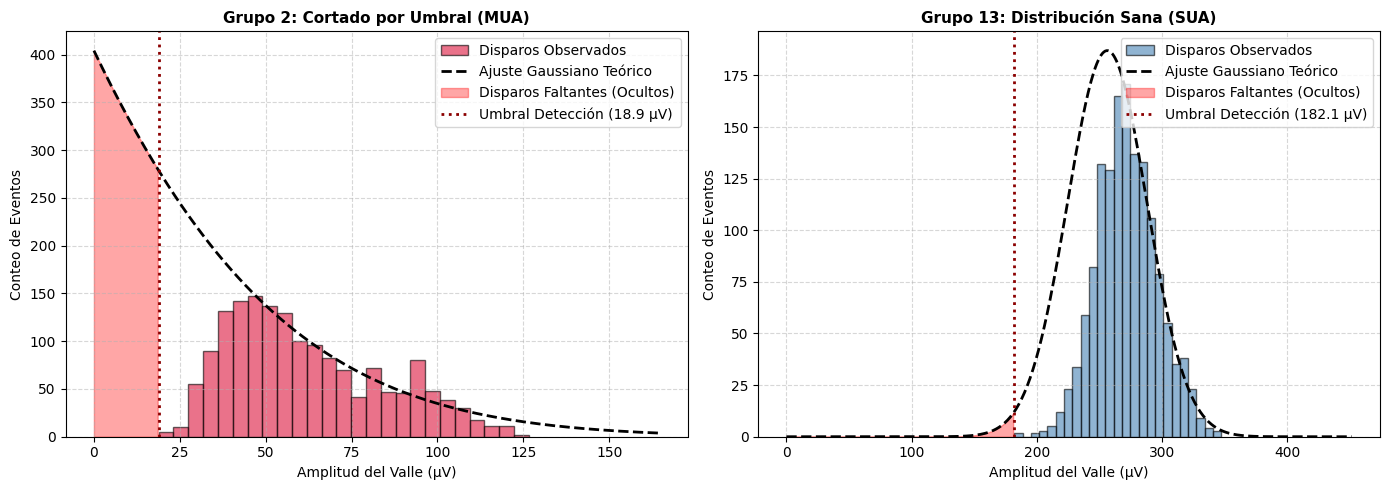

In [80]:
#PARTE ABIERTA
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def _gaussiana_teorica(x, a, mu, sigma):
    return a * np.exp(-((x - mu) ** 2) / (2 * sigma**2))

def graficar_comparativa_amplitudes(res_ruidosa, labels_elegidos, g_cortado=2, g_sano=13):
    formas_onda = res_ruidosa['formas_onda']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    grupos = [g_cortado, g_sano]
    titulos = [f'Grupo {g_cortado}: Cortado por Umbral (MUA)', f'Grupo {g_sano}: Distribución Sana (SUA)']
    colores = ['crimson', 'steelblue']

    for ax, g, titulo, color in zip(axes, grupos, titulos, colores):
        idx_k = np.where(labels_elegidos == g)[0]
        waveforms_k = formas_onda[idx_k]

        # Obtener el canal modal y las amplitudes del valle
        valle_por_canal = -waveforms_k.min(axis=2)
        ch_pico_ev = np.argmax(valle_por_canal, axis=1)
        ch_modal = np.bincount(ch_pico_ev).argmax()
        amps = valle_por_canal[:, ch_modal]

        # Histograma de amplitudes observadas
        counts, bin_edges, _ = ax.hist(amps, bins=25, density=False, alpha=0.6, color=color, edgecolor='black', label='Disparos Observados')
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2.0

        # Ajuste de la mitad derecha (desde el pico del histograma)
        idx_max = np.argmax(counts)
        x_fit = bin_centers[idx_max:]
        y_fit = counts[idx_max:]
        umbral_min = np.min(amps)

        try:
            p0 = [counts[idx_max], bin_centers[idx_max], np.std(amps)]
            popt, _ = curve_fit(_gaussiana_teorica, x_fit, y_fit, p0=p0, maxfev=2000)

            x_teorico = np.linspace(0, np.max(amps) * 1.3, 400)
            y_teorico = _gaussiana_teorica(x_teorico, *popt)

            # Curva Gaussiana completa
            ax.plot(x_teorico, y_teorico, 'k--', linewidth=2, label='Ajuste Gaussiano Teórico')

            # Sombreado de disparos faltantes (área debajo del umbral)
            mask_faltantes = x_teorico < umbral_min
            ax.fill_between(x_teorico[mask_faltantes], y_teorico[mask_faltantes], color='red', alpha=0.35, label='Disparos Faltantes (Ocultos)')
        except Exception:
            pass

        # Línea del umbral de detección
        ax.axvline(umbral_min, color='darkred', linestyle=':', linewidth=2, label=f'Umbral Detección ({umbral_min:.1f} µV)')

        ax.set_title(titulo, fontsize=11, fontweight='bold')
        ax.set_xlabel('Amplitud del Valle (µV)')
        ax.set_ylabel('Conteo de Eventos')
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Ejecución de la comparación entre el Grupo 2 y el Grupo 13
graficar_comparativa_amplitudes(res_ruidosa, labels_elegidos, g_cortado=2, g_sano=13)

---
# 6 · Autocorrelograma y correlograma cruzado

Estas dos figuras contestan preguntas que ninguna de las medidas anteriores contesta.

El **autocorrelograma** de un grupo es el histograma de todos los intervalos de tiempo entre sus
propios disparos. Si el grupo es una sola neurona, tiene que haber un **hueco** alrededor de cero: el
período refractario. Si no hay hueco, hay más de una neurona adentro.

⚠️ **Ojo con dónde miran.** Su detector fusiona en un solo evento todos los cruces que caen dentro de
0,5 ms, así que **por construcción no puede haber dos detecciones separadas por menos de eso**. El
centro del correlograma está vacío para todos los grupos, tengan o no una sola neurona: ese vacío lo
puso el detector, no la biología. Lo que hay que mirar es **la banda entre 0,5 y 2 ms**, que es la
parte del período refractario que el detector no tocó. Ahí sí, vacía significa una sola neurona.

El **correlograma cruzado** entre dos grupos es lo mismo pero entre grupos distintos: para cada
disparo del grupo A, cuántos disparos del grupo B cayeron a cada distancia de tiempo. Y aquí está el
argumento bonito del taller:

> Si dos grupos son dos neuronas distintas, no tienen por qué respetar el refractario del otro, y la
> banda de 0,5 a 2 ms se ve tan poblada como el resto. **Si esa banda está vacía, los dos grupos son
> la misma neurona partida en dos.**

Ese vacío es la prueba de sobre-división, y es la razón por la que uno puede pasarse de `k` sin miedo:
lo que se partió de más se detecta y se vuelve a unir.

⚠️ **Trampa de escala.** El período refractario dura unos 2 ms. Si grafican de −50 a +50 ms con barras
de 1 ms, esa banda son dos barras de cien y no se ve nada. **Grafiquen de −20 a +20 ms con barras de
0,25 ms.**

⚠️ **Y una advertencia que les va a pasar.** La prueba tiene un falso positivo conocido. Si dos
neuronas **distintas** están muy juntas en la sonda, sus disparos casi simultáneos caen dentro de la
misma ventana muerta y el detector los cuenta como uno solo, así que la banda también sale vacía. Lo
que separa los dos casos es la **forma de onda promedio**: si los dos grupos son la misma neurona,
sus formas promedio son iguales; si son dos neuronas vecinas, no lo son. Comparen las formas antes de
fusionar nada.

### ✏️ Ejercicio 6

**a)** Escriban las funciones del autocorrelograma y del correlograma cruzado, de −20 a +20 ms con
barras de 0,25 ms. Para comparar grupos entre sí les va a servir un número, no sólo la figura: por
ejemplo el promedio de las barras entre 0,5 y 2 ms dividido por el promedio de las barras entre 5 y
20 ms. Si es cercano a cero, la banda está vacía.

**b)** Grafiquen el autocorrelograma de todos sus grupos.

**c)** Calculen el correlograma cruzado de las parejas de grupos que estén cerca en la nube de
características, que son las candidatas a ser una sola neurona.

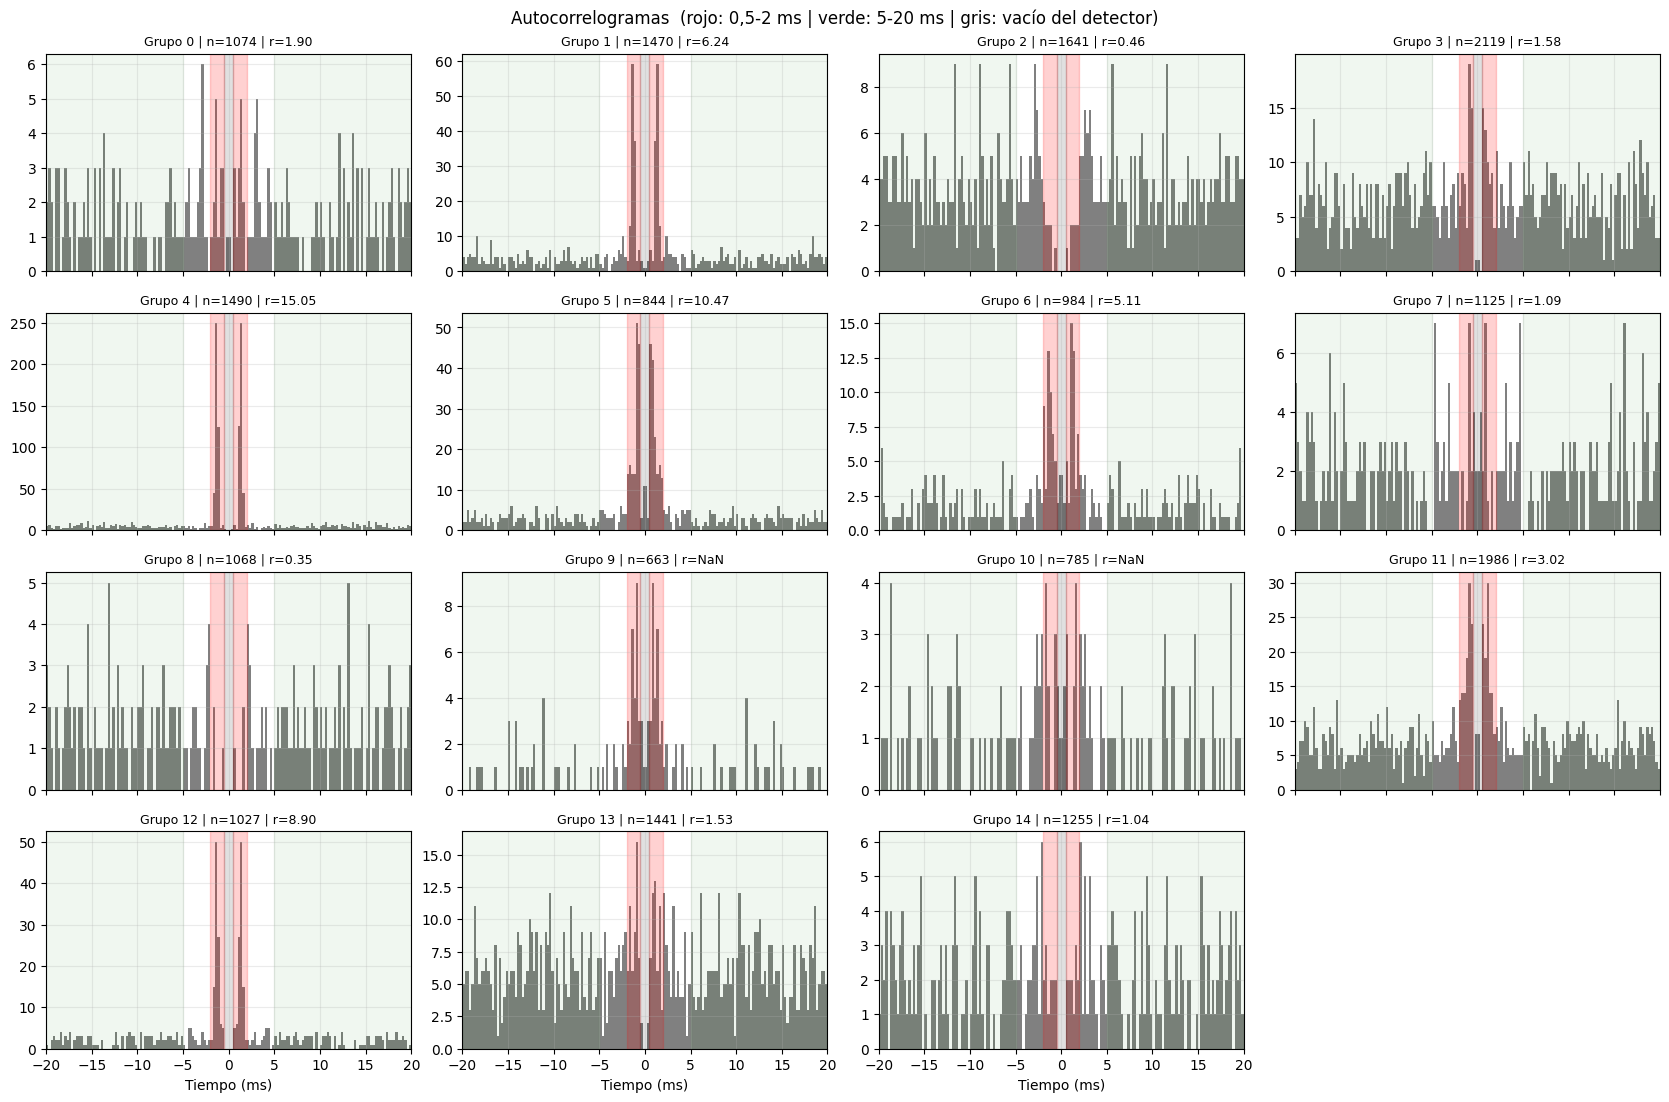

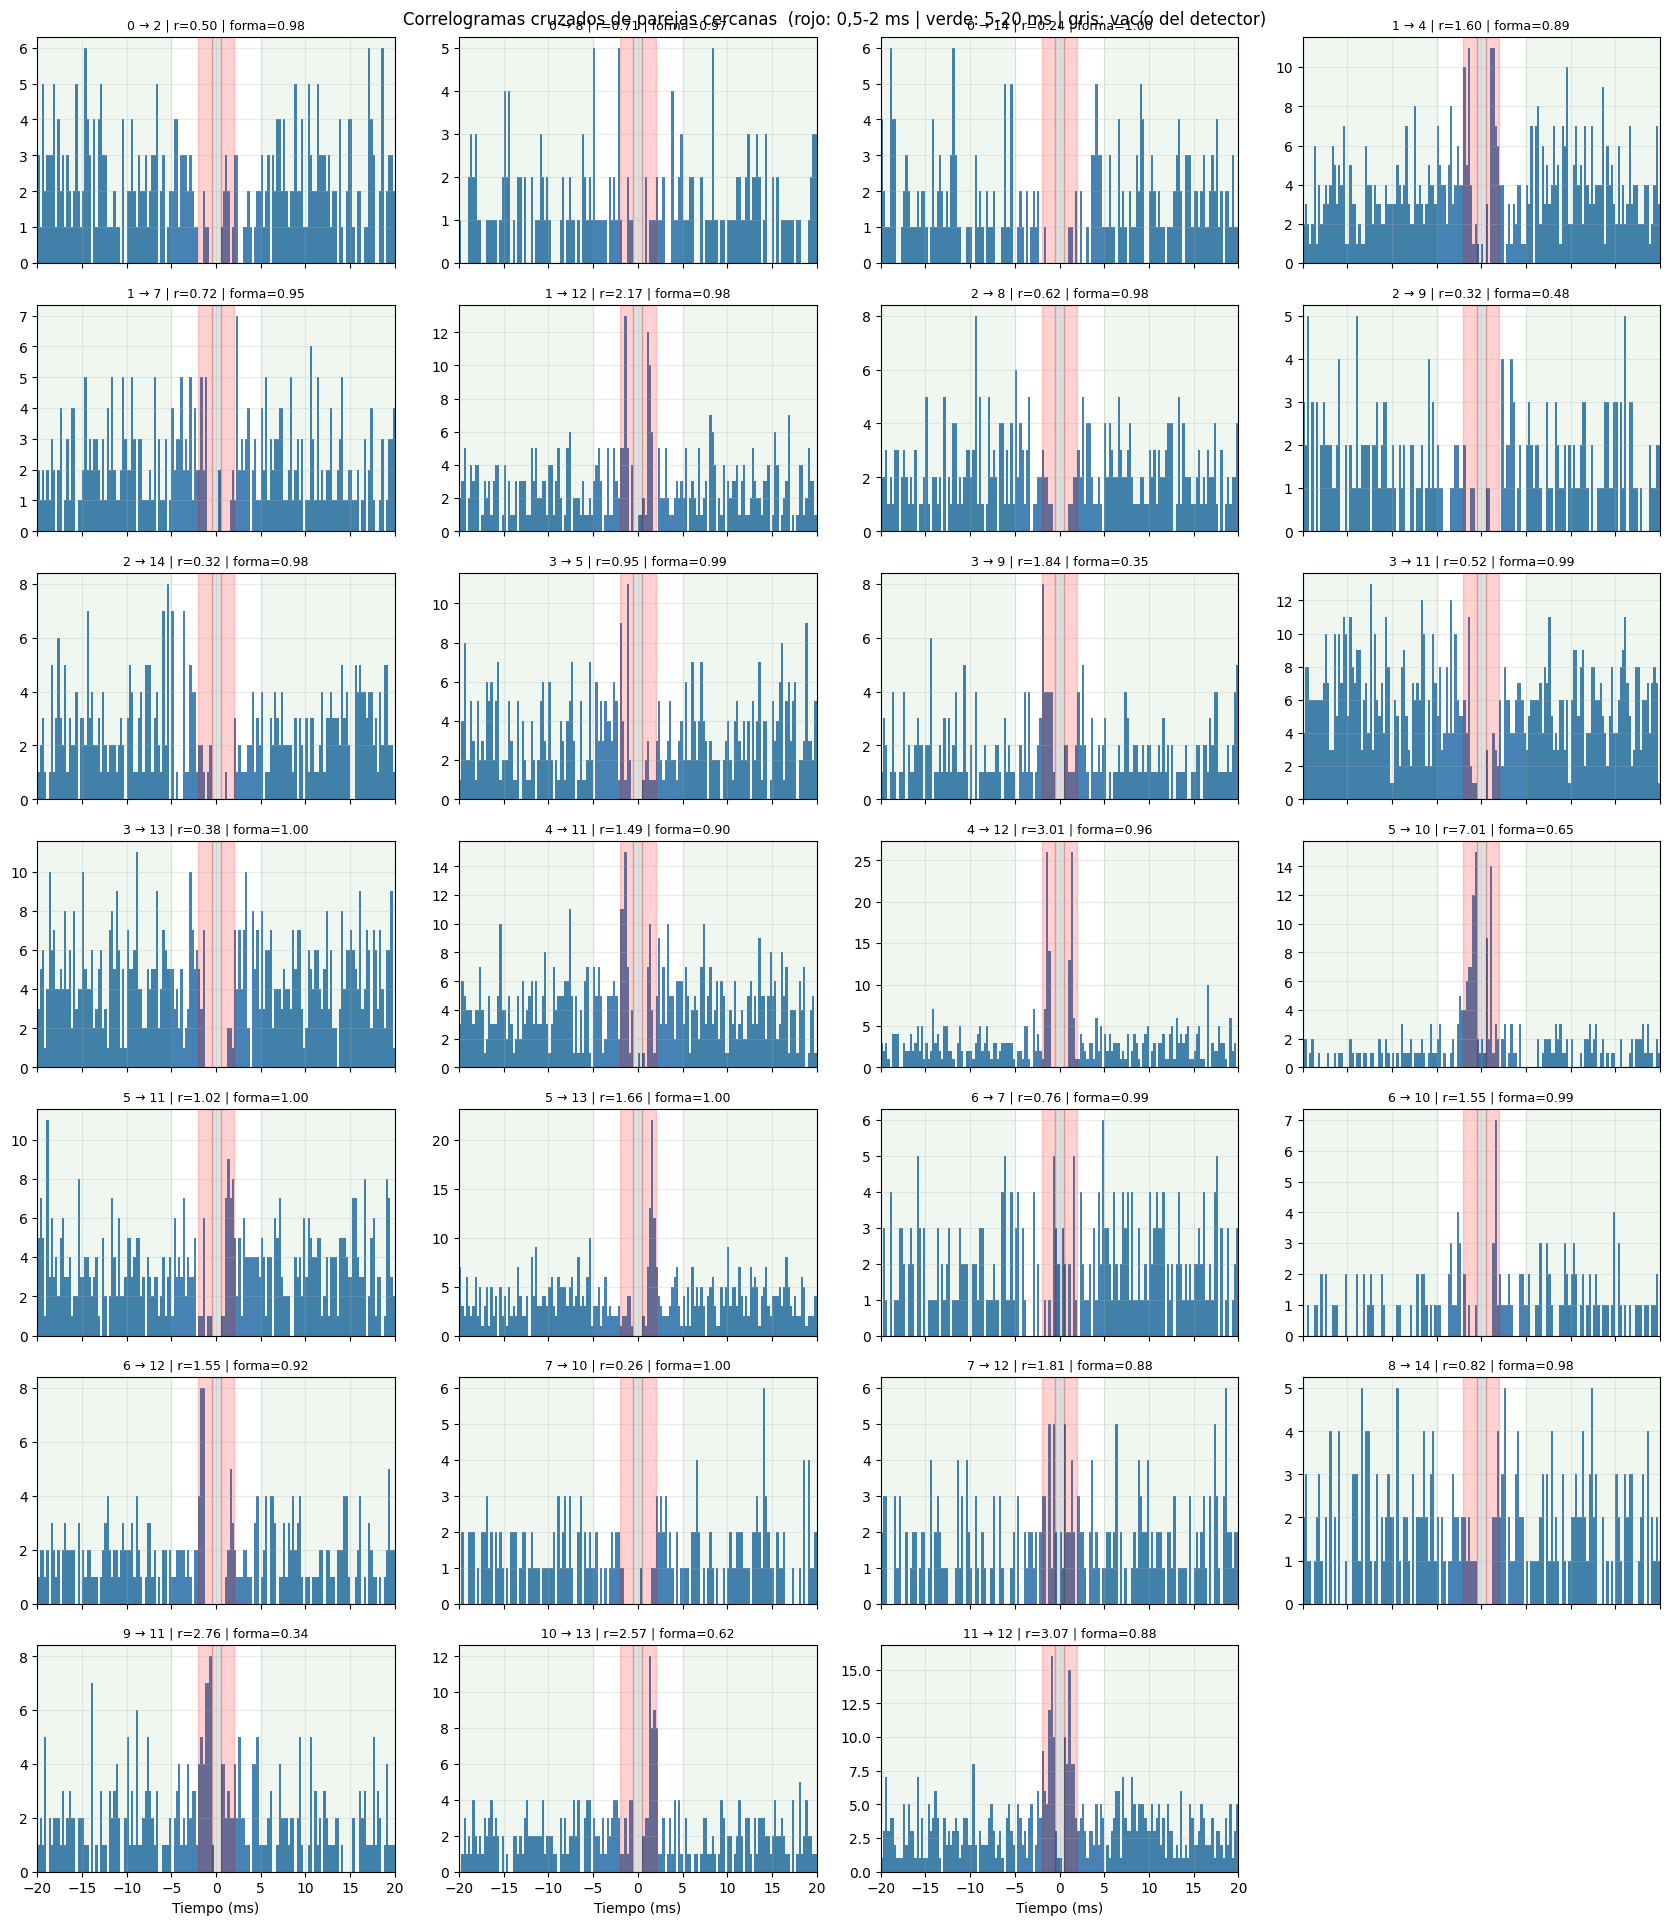

=== AUTOCORRELOGRAMAS: banda 0,5-2 ms frente a 5-20 ms ===
 Grupo  N_Disparos  N_Banda  Dens_Banda  Dens_Vecina  Ratio  Depresion_pct  P_Poisson  Deprimida_Explor
     0        1074       15      10.000        5.267  1.899        -89.873      0.993             False
     1        1470      121      80.667       12.933  6.237       -523.711      1.000             False
     2        1641       10       6.667       14.533  0.459         54.128      0.004             False
     3        2119       61      40.667       25.733  1.580        -58.031      1.000             False
     4        1490      432     288.000       19.133 15.052      -1405.226      1.000             False
     5         844      155     103.333        9.867 10.473       -947.297      1.000             False
     6         984       47      31.333        6.133  5.109       -410.870      1.000             False
     7        1125       12       8.000        7.333  1.091         -9.091      0.689             False
     

In [81]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson

# ==============================================================================
# 1) LO QUE VIENE DADO POR EL EJERCICIO (no se toca)
# ==============================================================================
MAX_MS = 20.0                # correlogramas de -20 a +20 ms
BIN_MS = 0.25                # barras de 0,25 ms
BANDA_REF = (0.5, 2.0)       # banda refractaria a evaluar: 0,5 < |dt| <= 2 ms
DETECTOR_MS = 0.5            # |dt| < 0,5 ms está vacío por construcción del detector
BANDA_VECINA = (5.0, 20.0)   # región de comparación que propone el enunciado: 5 a 20 ms
PRE_MS = 1.0                 # las formas de onda se extrajeron desde 1,0 ms antes del evento

# ==============================================================================
# 2) LO QUE PROPONGO PARA EXPLORAR (medidas cuantitativas, sin decidir nada)
#    - Ratio de densidades = (eventos/ms en 0,5-2 ms) / (eventos/ms en 5-20 ms)
#      (cercano a 0: banda vacía; cercano a 1: tan poblada como la región vecina).
#    - Depresión = 1 - ratio.
#    - p de Poisson: probabilidad de ver tan pocos eventos (o menos) en la banda si su
#      densidad fuera la de la región vecina. Es informativa; NO se usa para decidir.
#    - Similitud de formas: correlación de Pearson entre las formas promedio.
# ==============================================================================

# ==============================================================================
# 3) UMBRALES ADICIONALES QUE EL EJERCICIO NO DA (hay que definirlos o justificarlos)
# ==============================================================================
RATIO_EXPLORATORIO = 0.20    # "fuertemente deprimida": ratio <= 0,20. Propuesta MÍA, sin
                             # respaldo en el enunciado; sólo marca pares para INSPECCIONAR.
MIN_EVENTOS_VECINA = 50      # mínimo de eventos en 5-20 ms para calcular un ratio confiable
MIN_DISPAROS = 50            # grupos con menos disparos se omiten
# No existe ningún umbral de "formas suficientemente similares": se reportan las
# correlaciones y se superponen las formas; la decisión de fusionar es tuya.


# ==============================================================================
# FUNCIONES AUXILIARES
# ==============================================================================
def _intervalos_ms(t_a, t_b, auto):
    """Diferencias de tiempo (t_b - t_a, en ms) con |dt| <= 20 ms.

    Para cada disparo de A se toman los disparos de B dentro de ±20 ms (búsqueda binaria).
    Si auto=True, A y B son el mismo grupo y se excluye cada disparo consigo mismo.
    """
    t_a, t_b = np.sort(t_a), np.sort(t_b)
    w = MAX_MS / 1000.0
    izq = np.searchsorted(t_b, t_a - w, side='left')
    der = np.searchsorted(t_b, t_a + w, side='right')
    partes = [t_b[i0:i1] - t for t, i0, i1 in zip(t_a, izq, der)]
    dt = (np.concatenate(partes) if partes else np.array([])) * 1000.0
    if auto:
        dt = dt[dt != 0.0]                 # quitar el par de cada disparo consigo mismo
    return np.round(dt, 6)                 # evita errores de coma flotante justo en 2,0 ms


def _medir_banda(dt_ms, auto):
    """Cuantifica la banda 0,5 < |dt| <= 2 ms frente a la región vecina 5 < |dt| <= 20 ms.

    Los conteos se hacen sobre los intervalos exactos (no sobre las barras), para que el
    borde de 2,0 ms quede incluido como pide el enunciado (<= 2).
    """
    a = np.abs(dt_ms)
    n_banda = int(((a > BANDA_REF[0]) & (a <= BANDA_REF[1])).sum())
    n_vecina = int(((a > BANDA_VECINA[0]) & (a <= BANDA_VECINA[1])).sum())

    # En el autocorrelograma cada par aparece dos veces (+dt y -dt): se cuenta una vez.
    # Así "ms observados" es un solo lado (auto) o los dos lados (cruzado).
    lados = 1 if auto else 2
    if auto:
        n_banda, n_vecina = n_banda // 2, n_vecina // 2
    ms_banda = lados * (BANDA_REF[1] - BANDA_REF[0])          # 1,5 ms por lado
    ms_vecina = lados * (BANDA_VECINA[1] - BANDA_VECINA[0])   # 15 ms por lado

    dens_banda = n_banda / ms_banda                            # eventos por ms
    dens_vecina = n_vecina / ms_vecina

    if n_vecina < MIN_EVENTOS_VECINA:
        return dict(N_Banda=n_banda, Dens_Banda=dens_banda, Dens_Vecina=dens_vecina,
                    Ratio=np.nan, Depresion_pct=np.nan, P_Poisson=np.nan)

    ratio = dens_banda / dens_vecina
    esperado = dens_vecina * ms_banda            # eventos esperados en la banda sin depresión
    return dict(N_Banda=n_banda, Dens_Banda=dens_banda, Dens_Vecina=dens_vecina,
                Ratio=ratio, Depresion_pct=100.0 * (1.0 - ratio),
                P_Poisson=float(poisson.cdf(n_banda, esperado)))


def _dibujar_correlograma(ax, dt_ms, titulo, color):
    """Histograma de -20 a +20 ms con barras de 0,25 ms y las regiones marcadas."""
    bordes = np.linspace(-MAX_MS, MAX_MS, int(round(2 * MAX_MS / BIN_MS)) + 1)
    cuentas, _ = np.histogram(dt_ms, bins=bordes)
    centros = 0.5 * (bordes[:-1] + bordes[1:])
    ax.bar(centros, cuentas, width=BIN_MS, color=color)
    for s in (-1, 1):
        ax.axvspan(*sorted((s * BANDA_REF[0], s * BANDA_REF[1])), color='red', alpha=0.18)
        ax.axvspan(*sorted((s * BANDA_VECINA[0], s * BANDA_VECINA[1])), color='green', alpha=0.06)
    ax.axvspan(-DETECTOR_MS, DETECTOR_MS, color='black', alpha=0.12)   # vacío del detector
    ax.set_xlim(-MAX_MS, MAX_MS)
    ax.set_title(titulo, fontsize=9)


def _parejas(centros_z, grupos, n_vecinos, dist_max):
    """Parejas relevantes: los n_vecinos grupos más cercanos en la nube de características.
    Si n_vecinos es None se usan todas las parejas posibles."""
    if n_vecinos is None:
        return [(a, b, np.nan) for a, b in itertools.combinations(grupos, 2)]
    d = np.linalg.norm(centros_z[:, None, :] - centros_z[None, :, :], axis=2)
    np.fill_diagonal(d, np.inf)
    ps = set()
    for i in range(len(grupos)):
        for j in np.argsort(d[i])[:n_vecinos]:
            if dist_max is None or d[i, j] <= dist_max:
                ps.add((min(i, j), max(i, j)))
    return [(grupos[i], grupos[j], d[i, j]) for i, j in sorted(ps)]


def _rejilla(n_paneles, n_col=4, alto=2.8):
    n_fil = max(1, int(np.ceil(n_paneles / n_col)))
    fig, axes = plt.subplots(n_fil, n_col, figsize=(4.2 * n_col, alto * n_fil),
                             squeeze=False, sharex=True)
    axes = axes.ravel()
    for ax in axes[n_paneles:]:
        ax.set_visible(False)
    return fig, axes


# ==============================================================================
# FUNCIÓN PRINCIPAL
# ==============================================================================
def analizar_correlogramas(res_ruidosa, labels, grupos=None, n_vecinos=3, dist_max=None,
                           ratio_exploratorio=RATIO_EXPLORATORIO, min_disparos=MIN_DISPAROS,
                           tabla_calidad=None):
    """Autocorrelogramas + correlogramas cruzados + comparación de formas de onda promedio.

    NO fusiona ningún grupo: sólo calcula, grafica y marca pares para inspección.

    Variables reales usadas (salen de ejercicio4):
      res_ruidosa['tiempos_s']                    instante de cada evento (s)
      res_ruidosa['formas_onda']                  (eventos, 16, muestras)
      res_ruidosa['caracteristicas']['canal_pico'] canal pico de cada evento
      res_ruidosa['X_z']                          características estandarizadas
      res_ruidosa['fs']                           frecuencia de muestreo
      labels                                      grupo de cada evento (p. ej. labels_elegidos)
      tabla_calidad (opcional)                    tabla que devuelve control_calidad_grupos (Ejercicio 5);
                                                  debe haberse calculado con ESTAS mismas etiquetas
    """
    labels = np.asarray(labels)
    tiempos_s = np.asarray(res_ruidosa['tiempos_s'])
    waveforms = res_ruidosa['formas_onda']
    canal_pico = np.asarray(res_ruidosa['canales_pico'])      # antes: res_ruidosa['caracteristicas']['canal_pico']
    X_z = X_scaled                                            # antes: res_ruidosa['X_z']
    fs = res_ruidosa['fs']

    # Todos los arreglos por evento deben estar alineados con las etiquetas
    assert len(labels) == len(tiempos_s) == len(waveforms), (
        f'labels ({len(labels)}), tiempos_s ({len(tiempos_s)}) y formas_onda '
        f'({len(waveforms)}) deben tener el mismo número de eventos')

    # La tabla de calidad sólo se usa si corresponde a estas etiquetas (mismos grupos y mismos n)
    if tabla_calidad is not None:
        n_ahora = {int(g): int(c) for g, c in zip(*np.unique(labels, return_counts=True))}
        n_calidad = dict(zip(tabla_calidad['grupo'].astype(int), tabla_calidad['n_disparos'].astype(int)))
        if n_ahora != n_calidad:
            print('AVISO: tabla_calidad no corresponde a estas etiquetas; se ignora. '
                  'Vuelve a correr control_calidad_grupos con los mismos labels.')
            tabla_calidad = None

    todos = np.unique(labels)
    grupos = [int(g) for g in (todos if grupos is None else grupos)
              if (labels == g).sum() >= min_disparos]

    # --------------------------------------------------------------------------
    # Datos por grupo: instantes, forma promedio alineada y forma promedio multicanal
    # --------------------------------------------------------------------------
    info = {}
    for g in grupos:
        idx = np.where(labels == g)[0]
        info[g] = {
            'idx': idx,
            't': np.sort(tiempos_s[idx]),
            # Forma en el canal pico DE CADA evento, promediada (alineada)
            'onda_pico': waveforms[idx, canal_pico[idx], :].mean(axis=0),
            # Forma en los 16 canales (firma espacial), promedio en canales absolutos
            'onda_16': waveforms[idx].mean(axis=0),
            'canal_modal': int(np.bincount(canal_pico[idx]).argmax()),
        }

    # --------------------------------------------------------------------------
    # A) Autocorrelograma de cada grupo
    # --------------------------------------------------------------------------
    filas_auto = []
    fig_auto, axes = _rejilla(len(grupos))
    for ax, g in zip(axes, grupos):
        dt = _intervalos_ms(info[g]['t'], info[g]['t'], auto=True)
        m = _medir_banda(dt, auto=True)
        filas_auto.append({'Grupo': g, 'N_Disparos': len(info[g]['t']), **m})
        r = m['Ratio']
        _dibujar_correlograma(ax, dt, f"Grupo {g} | n={len(info[g]['t'])} | "
                                       f"r={'NaN' if np.isnan(r) else f'{r:.2f}'}", 'gray')
    for ax in axes[-4:]:
        ax.set_xlabel('Tiempo (ms)')
    fig_auto.suptitle('Autocorrelogramas  (rojo: 0,5-2 ms | verde: 5-20 ms | gris: vacío del detector)')
    plt.tight_layout(); plt.show()

    tabla_auto = pd.DataFrame(filas_auto)
    tabla_auto['Deprimida_Explor'] = tabla_auto['Ratio'] <= ratio_exploratorio
    if tabla_calidad is not None:
        # Contexto del Ejercicio 5 para el mismo grupo (nombres reales de tabla_calidad).
        # Nota: el Ejercicio 5 cuenta ISI consecutivos < 2 ms; aquí se cuentan TODOS los pares
        # a 0,5 < |dt| <= 2 ms, por eso los números no son idénticos.
        q = tabla_calidad.rename(columns={'grupo': 'Grupo', 'cumple_refractario': 'Calidad_Cumple_Refractario',
                                          'es_no_somatica': 'Calidad_No_Somatica',
                                          'criterios_incumplidos': 'Calidad_Incumple'})
        tabla_auto = tabla_auto.merge(q[['Grupo', 'Calidad_Cumple_Refractario', 'Calidad_No_Somatica',
                                         'Calidad_Incumple']], on='Grupo', how='left')

    # --------------------------------------------------------------------------
    # B) Correlogramas cruzados de las parejas relevantes
    # --------------------------------------------------------------------------
    centros_z = np.array([X_z[info[g]['idx']].mean(axis=0) for g in grupos])
    parejas = _parejas(centros_z, grupos, n_vecinos, dist_max)

    filas_pares = []
    fig_cruz, axes = _rejilla(len(parejas))
    for ax, (a, b, dist) in zip(axes, parejas):
        dt = _intervalos_ms(info[a]['t'], info[b]['t'], auto=False)
        m = _medir_banda(dt, auto=False)

        # Similitud de formas (dos medidas, sin umbral de "suficientemente similar")
        corr_pico = float(np.corrcoef(info[a]['onda_pico'], info[b]['onda_pico'])[0, 1])
        corr_16 = float(np.corrcoef(info[a]['onda_16'].ravel(), info[b]['onda_16'].ravel())[0, 1])

        filas_pares.append({
            'Grupo_A': a, 'Grupo_B': b, 'Dist_Nube': dist, **m,
            'Corr_Forma_CanalPico': corr_pico, 'Corr_Forma_16Canales': corr_16,
            'Dif_Canal_Pico': abs(info[a]['canal_modal'] - info[b]['canal_modal']),
        })
        r = m['Ratio']
        _dibujar_correlograma(ax, dt, f"{a} → {b} | r={'NaN' if np.isnan(r) else f'{r:.2f}'}"
                                      f" | forma={corr_pico:.2f}", 'steelblue')
    for ax in axes[-4:]:
        ax.set_xlabel('Tiempo (ms)')
    fig_cruz.suptitle('Correlogramas cruzados de parejas cercanas  '
                      '(rojo: 0,5-2 ms | verde: 5-20 ms | gris: vacío del detector)')
    plt.tight_layout(); plt.show()

    tabla_pares = pd.DataFrame(filas_pares)
    # Sólo MARCA para inspección; no decide ni fusiona nada
    tabla_pares['Candidato_Sobredivision_Explor'] = tabla_pares['Ratio'] <= ratio_exploratorio
    tabla_pares = tabla_pares.sort_values('Ratio', na_position='last').reset_index(drop=True)
    if tabla_calidad is not None:
        q = tabla_calidad.set_index('grupo')
        for lado in ('A', 'B'):
            tabla_pares[f'NoSomatica_{lado}'] = tabla_pares[f'Grupo_{lado}'].map(q['es_no_somatica'])
            tabla_pares[f'Incumple_{lado}'] = tabla_pares[f'Grupo_{lado}'].map(q['criterios_incumplidos'])

    # --------------------------------------------------------------------------
    # C) Formas de onda promedio superpuestas de los pares candidatos
    # --------------------------------------------------------------------------
    candidatos = tabla_pares[tabla_pares['Candidato_Sobredivision_Explor']]
    fig_formas = None
    if len(candidatos):
        fig_formas, axes = plt.subplots(int(np.ceil(len(candidatos) / 3)), 3,
                                        figsize=(14, 3.6 * int(np.ceil(len(candidatos) / 3))),
                                        squeeze=False)
        axes = axes.ravel()
        for ax in axes[len(candidatos):]:
            ax.set_visible(False)
        for ax, (_, f) in zip(axes, candidatos.iterrows()):
            a, b = int(f['Grupo_A']), int(f['Grupo_B'])
            n = len(info[a]['onda_pico'])
            t_ms = (np.arange(n) - int(round(PRE_MS / 1000.0 * fs))) / fs * 1000.0
            ax.plot(t_ms, info[a]['onda_pico'], label=f'Grupo {a} (canal {info[a]["canal_modal"]})')
            ax.plot(t_ms, info[b]['onda_pico'], label=f'Grupo {b} (canal {info[b]["canal_modal"]})',
                    linestyle='--')
            ax.axvline(0, color='k', lw=0.5)
            ax.set_title(f'{a} vs {b} | corr={f["Corr_Forma_CanalPico"]:.3f} | '
                         f'r={f["Ratio"]:.2f}', fontsize=9)
            ax.set_xlabel('Tiempo respecto al evento (ms)')
            ax.set_ylabel('Amplitud (µV)')
            ax.legend(fontsize=8)
        fig_formas.suptitle('Formas de onda promedio de los pares candidatos (canal pico de cada grupo)')
        plt.tight_layout(); plt.show()

    # --------------------------------------------------------------------------
    # D) Tablas resumen
    # --------------------------------------------------------------------------
    fmt = lambda x: f'{x:.3f}'
    print('=== AUTOCORRELOGRAMAS: banda 0,5-2 ms frente a 5-20 ms ===')
    print(tabla_auto.to_string(index=False, float_format=fmt))
    print('\n=== CORRELOGRAMAS CRUZADOS (ordenados de menor a mayor ratio) ===')
    print(tabla_pares.to_string(index=False, float_format=fmt))
    print('\nN_Banda = eventos con 0,5 < |dt| <= 2 ms | Dens_* = eventos por ms | '
          'Ratio = Dens_Banda / Dens_Vecina | Depresion_pct = 100·(1 − Ratio)')
    print('P_Poisson: probabilidad de ver N_Banda o menos si la banda tuviera la densidad de 5-20 ms '
          '(informativa)')
    print(f'Marcas "Explor": ratio <= {ratio_exploratorio} es un umbral PROPUESTO, no del ejercicio. '
          'Ningún par se fusiona: revisa las formas superpuestas antes de decidir.')
    return tabla_auto, tabla_pares, (fig_auto, fig_cruz, fig_formas)


# ==============================================================================
# EJECUCIÓN (nombres reales del notebook: res_ruidosa, labels_elegidos y tabla_calidad)
# ==============================================================================
k_elegido = 16    # el k con el que sigues trabajando (8, 12, 16 o 25)
if 'labels_elegidos' not in globals():          # si no está definida, se toma de ejercicio4
    labels_elegidos = res_ruidosa['labels_por_k'][k_elegido]

# tabla_calidad (Ejercicio 5) es opcional: si existe y coincide con estas etiquetas, se añade su contexto
tabla_auto, tabla_pares, figuras = analizar_correlogramas(
    res_ruidosa, labels_elegidos, tabla_calidad=globals().get('tabla_calidad'))


**P6.**

**Selección múltiple.** Dos grupos tienen el correlograma cruzado con la banda de 0,5 a 2 ms vacía.
Lo primero que hay que sospechar es que

- **a)** son dos neuronas vecinas distintas
- **b)** son la misma neurona, partida en dos grupos---> Respuesta Correscta
- **c)** están conectadas por una sinapsis
- **d)** los dos son artefactos

**Abierta.** Busquen una pareja así en sus datos. Muestren la figura, comparen las dos formas de onda
promedio y decidan si las fusionan o no. Justifiquen la decisión: la banda vacía sola no alcanza.

*Su respuesta:*
El grupo 7 y el grupo 10 muestra una banda casi vacía y significativa con r=0.26 (o un 73.51%en Depresion, es decir esa zona tiene menos actividad de la que deberia) y P_Poisson=0.001. Tiene una correlación casi perfecta entre las formas de onda promedio en el canal pico de 0.997. Sin embargo, la banda vacía por si sola no nos sirve. La correlación de la forma en los 16 canales cae en un 0.668, que es un valor relativamente bajo si la quisieramos considerar una sola neurona ambos grupos (un valor bajo, por ejemplo, al compararlo con el grupo 2 y 8 que tienen 0.99). Ademas, los canales pico son diferentes en 3 lugares, el ratio umbral sobrepasa el valor de 0.20 y la cantidad de disparos en ese timepo (N_banda) es 4. Esto quiere decir que apesar de tener un buen valor de r y P_poison estos por si solos no nos dice si son dos neuroas distintas y cercanas en la sonda. POr lo tanto los otros valores como el de la dpresion_pct nos ayuda a decidir si fusionar o no, en este caso decidimos no funcionar ambas neuronas.

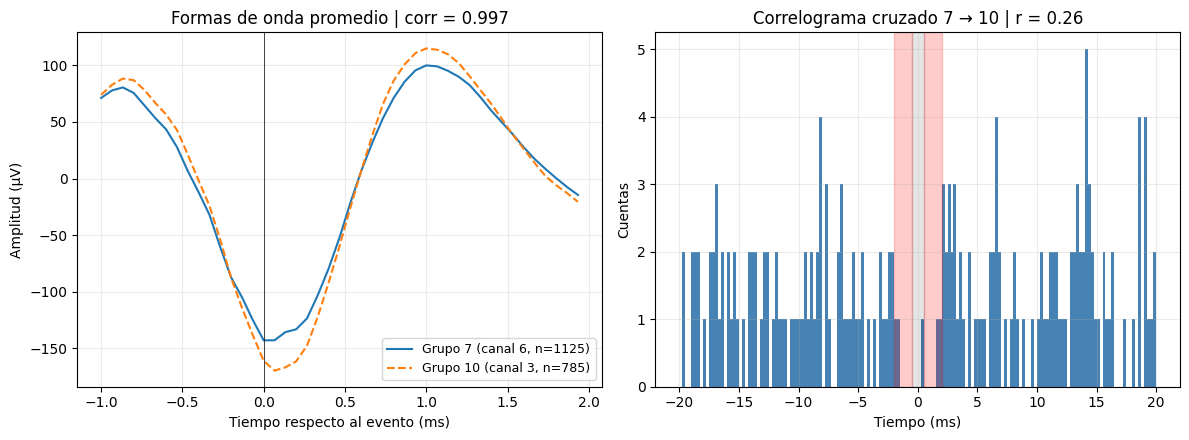

Grupo 7: 1125 disparos, canal pico 6
Grupo 10: 785 disparos, canal pico 3
Correlación de forma (Pearson): 0.997
Ratio r (banda 0,5-2 ms / flanco 5-20 ms): 0.26


In [82]:
#Codigo de pregunta abierta del ejericio 6
import numpy as np
import matplotlib.pyplot as plt

def comparar_pareja(res_ruidosa, labels, grupo_a, grupo_b, min_disparos=50):
    """Compara dos grupos elegidos a mano: forma de onda promedio superpuesta
    (en el canal pico de cada uno) y correlograma cruzado con el ratio r.

    Parámetros
    ----------
    res_ruidosa : dict del pipeline (Ejercicio 4)
    labels      : arreglo de etiquetas por evento (p. ej. labels_elegidos)
    grupo_a, grupo_b : números de los dos grupos a comparar (p. ej. 7 y 10)
    """
    labels = np.asarray(labels)
    tiempos_s = np.asarray(res_ruidosa['tiempos_s'])
    waveforms = res_ruidosa['formas_onda']            # (n_eventos, canales, muestras)
    canal_pico = np.asarray(res_ruidosa['canales_pico'])
    fs = res_ruidosa['fs']

    idx_a = np.where(labels == grupo_a)[0]
    idx_b = np.where(labels == grupo_b)[0]
    if len(idx_a) < min_disparos or len(idx_b) < min_disparos:
        print(f"Aviso: Grupo {grupo_a} tiene {len(idx_a)} disparos, "
              f"Grupo {grupo_b} tiene {len(idx_b)} (mínimo sugerido: {min_disparos}).")

    # --- Canal pico "modal" de cada grupo (el más frecuente entre sus eventos) ---
    canal_a = int(np.bincount(canal_pico[idx_a]).argmax())
    canal_b = int(np.bincount(canal_pico[idx_b]).argmax())

    # --- Forma de onda promedio de cada grupo, en su propio canal pico ---
    onda_a = waveforms[idx_a, canal_a, :].mean(axis=0)
    onda_b = waveforms[idx_b, canal_b, :].mean(axis=0)

    # --- Eje de tiempo relativo al evento (ms); pre_ms=1.0 según extraer_formas_onda ---
    n_muestras = waveforms.shape[2]
    pre_ms = 1.0
    t_ms = (np.arange(n_muestras) - int(round(pre_ms / 1000.0 * fs))) / fs * 1000.0

    # --- Similitud de forma: correlación de Pearson ---
    corr = float(np.corrcoef(onda_a, onda_b)[0, 1])

    # --- Correlograma cruzado y ratio r (reutiliza calcular_correlograma de la Sección 6) ---
    t_a = np.sort(tiempos_s[idx_a])
    t_b = np.sort(tiempos_s[idx_b])
    centros, counts, r, flanco = calcular_correlograma(t_a, t_b)

    # ==========================================================================
    # FIGURA: forma de onda superpuesta + correlograma cruzado
    # ==========================================================================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.plot(t_ms, onda_a, label=f"Grupo {grupo_a} (canal {canal_a}, n={len(idx_a)})")
    ax1.plot(t_ms, onda_b, label=f"Grupo {grupo_b} (canal {canal_b}, n={len(idx_b)})",
             linestyle='--')
    ax1.axvline(0, color='k', lw=0.5)
    ax1.set_xlabel("Tiempo respecto al evento (ms)")
    ax1.set_ylabel("Amplitud (µV)")
    ax1.set_title(f"Formas de onda promedio | corr = {corr:.3f}")
    ax1.legend(fontsize=9)

    ax2.bar(centros, counts, width=0.25, color='steelblue')
    ax2.axvspan(-2.0, -0.5, color='red', alpha=0.2)
    ax2.axvspan(0.5, 2.0, color='red', alpha=0.2)
    ax2.axvspan(-0.5, 0.5, color='black', alpha=0.1)
    ax2.set_xlabel("Tiempo (ms)")
    ax2.set_ylabel("Cuentas")
    r_txt = f"{r:.2f}" if not np.isnan(r) else "n/d (menos de 50 eventos en el flanco)"
    ax2.set_title(f"Correlograma cruzado {grupo_a} → {grupo_b} | r = {r_txt}")

    plt.tight_layout()
    plt.show()

    print(f"Grupo {grupo_a}: {len(idx_a)} disparos, canal pico {canal_a}")
    print(f"Grupo {grupo_b}: {len(idx_b)} disparos, canal pico {canal_b}")
    print(f"Correlación de forma (Pearson): {corr:.3f}")
    print(f"Ratio r (banda 0,5-2 ms / flanco 5-20 ms): {r_txt}")

    return {'canal_a': canal_a, 'canal_b': canal_b, 'onda_a': onda_a, 'onda_b': onda_b,
            'corr_forma': corr, 'ratio_r': r, 'centros_ms': centros, 'counts': counts}

resultado = comparar_pareja(res_ruidosa, labels_elegidos, 7, 10)

---
# 7 · Curar: ponerle una etiqueta a cada grupo

Ahora júntenlo todo. Cada grupo recibe **una** de estas cuatro etiquetas.

**`noise`.** No es actividad neuronal. Se reconoce porque la forma de onda no parece un potencial de
acción (demasiados picos, duración fuera de rango) o porque **no cae con la distancia**: aparece con
la misma amplitud en toda la sonda. Se descarta y no se vuelve a mirar.

**`non-somatic`.** Es actividad neuronal, pero la onda es predominantemente positiva, lo que indica
que se está registrando un axón o una dendrita y no la zona donde nace el potencial de acción. Se
puede analizar, pero hay que decir en la figura que es no somática.

**`mua`.** Son potenciales de acción de verdad, pero de más de una neurona, o de una neurona a la que
le faltan disparos. Se reconoce por las violaciones del refractario, por la distribución de amplitudes
cortada por el umbral, o por tener muy pocos disparos. **La MUA sirve para medir actividad de la
población, pero no sirve para decir "esta neurona responde a este estímulo".**

**`good`.** Pasa todo. Es una neurona, aislada, completa.

Sobre el vocabulario, una precisión que importa en insectos: **no se debe hablar de "unidades
somáticas"**. Las neuronas de insecto son en su mayoría unipolares, con el soma en la corteza celular
de la periferia, fuera del neuropilo, y ese soma normalmente no genera el potencial de acción
propagado: la zona donde nace el disparo está en el neurito, ya dentro del neuropilo. Por eso la
distinción de bombcell es sobre la **forma de la onda registrada**, no sobre qué parte anatómica se
supone que uno está tocando.

### ✏️ Ejercicio 7

**a)** Apliquen las fusiones que decidieron en la sección 6.

**b)** Asignen una de las cuatro etiquetas a cada grupo resultante.

**c)** Hagan una figura resumen: para cada grupo etiquetado `good` o `non-somatic`, su forma de onda
promedio en los 16 sitios y su autocorrelograma.

In [83]:
# ✏️ Ejercicio 7
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

#Esta parte de la funcion agrupa los grupos en uno solo, entonces una agrupacion como (5, 13) hace que los disparos de 13 se funcionen con los del grupo 5. volviendolo un solo grupo.
fusiones = [(4,14)]   # dejen solo las que confirmen con el CCG y las formas de onda,
labels_fusion = labels_elegidos.copy()
for a, b in fusiones:
    labels_fusion[labels_fusion == b] = a

df_fusion = calcular_7_medidas_punto5(
    formas_onda=res_ruidosa['formas_onda'], tiempos_s=res_ruidosa['tiempos_s'],
    labels=labels_fusion, y_um=res_ruidosa['y_um'], fs=res_ruidosa['fs'])


def clasificar_grupos(res, labels, df_medidas, grupos=range(16),
                      prominencia_rel=0.10, pre_ms=1.0, mostrar_figura=True):
    """
    Asigna UNA etiqueta a cada grupo: 'noise', 'non-somatic', 'mua' o 'good'.
    Se evalúan en orden y gana la primera categoría que se cumpla:
      1) noise: falla picos<=2, valles<=2, duración 100-1150 µs o pendiente < -0.004
      2) non-somatic: razón pico/valle > 0.8
      3) mua: falla refractario < 1.5 %, faltantes < 20 % o al menos 300 disparos
      4) good: pasa todo
    Devuelve: (dict etiquetas, texto resumen, DataFrame con los motivos)
    """

    # ------------------------------------------------------------------
    # PASO 0: sacar del diccionario del pipeline lo que vamos a necesitar
    # ------------------------------------------------------------------
    tiempos_s   = res['tiempos_s']            # instante de cada disparo (s)
    formas_onda = res['formas_onda']          # arreglo (eventos, 16 canales, muestras)
    y_um, fs    = res['y_um'], res['fs']      # profundidad de cada canal y frecuencia de muestreo
    tabla       = df_medidas.set_index('Grupo')  # la tabla de la sección 5, indexada por número de grupo

    # etiquetas: {grupo: etiqueta}; filas: una fila por grupo para la tabla final;
    # info_fig: guarda lo necesario para dibujar solo los grupos good / non-somatic
    etiquetas, filas, info_fig = {}, [], {}

    # ------------------------------------------------------------------
    # PASO 1: recorrer cada grupo y calcular lo que falta
    # ------------------------------------------------------------------
    for g in grupos:
        # Índices de los disparos que K-means puso en este grupo
        idx = np.where(labels == g)[0]
        # Si el grupo está vacío o no está en la tabla de la sección 5, lo saltamos
        if len(idx) == 0 or g not in tabla.index:
            continue

        m = tabla.loc[g]
        n_disp = int(m['N_Disparos'])

        # ---- Salvaguarda: grupos con menos de 10 disparos no tienen medidas reales ----
        if n_disp < 10:
            etiquetas[int(g)] = "mua"
            filas.append({'Grupo': int(g), 'Etiqueta': "mua",
                          'Motivo': f"N={n_disp}<10, sin medidas confiables",
                          'Picos': np.nan, 'Valles': np.nan, 'Duracion_us': np.nan,
                          'Pendiente': np.nan, 'Razon_P/V': np.nan,
                          'Viol_%': np.nan, 'r_ACG': np.nan, 'Faltantes_%': np.nan, 'N': n_disp})
            continue

        # Forma de onda promedio del grupo en los 16 canales: (16, muestras)
        onda_prom = formas_onda[idx].mean(axis=0)
        # Canal pico = el canal donde el valle promedio es más profundo
        ch_pico   = np.argmax(-onda_prom.min(axis=1))
        # Traza del canal pico: es la que usamos para contar picos y valles
        traza     = onda_prom[ch_pico]

        # --- Conteo de picos y valles ---
        # Profundidad del valle (positiva), sirve de referencia para la prominencia
        prof = -traza.min()
        # Con prominence solo se cuentan los picos/valles que sobresalen al menos
        # un 10 % de la profundidad del valle. Así el rizado pequeño que deja el
        # filtro no cuenta como pico.
        picos,  _ = find_peaks(traza,  prominence=prominencia_rel * prof)   # picos positivos
        valles, _ = find_peaks(-traza, prominence=prominencia_rel * prof)   # valles (se invierte la señal)
        n_picos, n_valles = len(picos), len(valles)

        # --- Medidas que ya calculamos en la sección 5 ---
        m = tabla.loc[g]                              # fila de este grupo
        duracion  = float(m['Duracion_us'])           # valle -> pico de repolarización (µs)
        pendiente = float(m['Pendiente_Espacial'])    # caída de la amplitud con la distancia
        razon     = float(m['Razon_Pico_Valle'])      # pico positivo / valle
        viol      = float(m['Viol_Refractario_%'])    # % de intervalos < 2 ms
        n_disp    = int(m['N_Disparos'])              # número de disparos del grupo
        falt      = m['Pct_Faltantes_%']              # % de disparos faltantes
        # Si el ajuste de la campana no convergió, la tabla trae texto ('No Convergió').
        # Lo convertimos en nan para poder tratarlo después.
        falt      = float(falt) if not isinstance(falt, str) else np.nan

        # ------------------------------------------------------------------
        # PASO 2: revisar cada categoría, en orden
        # ------------------------------------------------------------------

        # ---- 1) NOISE: se guarda cada criterio que falle ----
        fallas_noise = []
        if n_picos > 2:                       fallas_noise.append(f"picos={n_picos}>2")
        if n_valles > 2:                      fallas_noise.append(f"valles={n_valles}>2")
        if not (100 <= duracion <= 1150):     fallas_noise.append(f"duración={duracion:.0f} µs fuera de 100-1150")
        if not (pendiente < -0.004):          fallas_noise.append(f"pendiente={pendiente:.4f} no es < -0.004")

        # ---- 2) NON-SOMATIC: onda predominantemente positiva (True/False) ----
        no_somatica = razon > 0.8

        # ---- 3) MUA: se guarda cada criterio que falle ----




        fallas_mua = []
        # --- Criterio adicional: banda del autocorrelograma no vacía ---
        t_g = np.sort(tiempos_s[idx])
        _, _, r_g, flanco_g = calcular_correlograma(t_g, t_g)
        if flanco_g >= 50 and not np.isnan(r_g) and r_g >= 0.35:
            fallas_mua.append(f"r_autocorrelograma={r_g:.2f} >= 0.35 (banda no vacía, flanco={flanco_g})")

        if not (viol < 1.5):                  fallas_mua.append(f"refractario={viol:.2f}% >= 1.5%")
        # Si faltantes es nan (no convergió) o es >= 20 %, también falla
        if np.isnan(falt) or not (falt < 20): fallas_mua.append(f"faltantes={falt}% >= 20% (o sin ajuste)")
        if n_disp < 300:                      fallas_mua.append(f"disparos={n_disp}<300")

        # ------------------------------------------------------------------
        # PASO 3: elegir UNA sola etiqueta (gana la primera que se cumpla)
        # ------------------------------------------------------------------
        if fallas_noise:                      # falló algo de noise -> noise
            etiqueta, motivo = "noise", "; ".join(fallas_noise)
        elif no_somatica:                     # pasó noise, pero onda positiva -> non-somatic
            etiqueta, motivo = "non-somatic", f"razón pico/valle={razon:.2f} > 0.8"
        elif fallas_mua:                      # neuronal y somática, pero no aislada -> mua
            etiqueta, motivo = "mua", "; ".join(fallas_mua)
        else:                                 # pasó todo -> good
            etiqueta, motivo = "good", "pasa todos los criterios"

        # Guardar el resultado de este grupo
        etiquetas[int(g)] = etiqueta
        filas.append({'Grupo': int(g), 'Etiqueta': etiqueta, 'Motivo': motivo,
                      'Picos': n_picos, 'Valles': n_valles, 'Duracion_us': duracion,
                      'Pendiente': pendiente, 'Razon_P/V': razon,
                      'Viol_%': viol, 'Faltantes_%': falt, 'N': n_disp})

        # Solo los good y non-somatic van a la figura resumen
        if etiqueta in ("good", "non-somatic"):
            info_fig[int(g)] = (onda_prom, ch_pico, idx)

    # Tabla con una fila por grupo, con sus medidas y el motivo de la etiqueta
    tabla_clas = pd.DataFrame(filas)

    # ------------------------------------------------------------------
    # PASO 4: texto resumen (una línea por grupo + conteo por categoría)
    # ------------------------------------------------------------------
    lineas = [f"Grupo {r.Grupo:2d} -> {r.Etiqueta.upper():11s} ({r.Motivo})"
              for r in tabla_clas.itertuples()]
    conteo = tabla_clas['Etiqueta'].value_counts().to_dict()   # cuántos grupos hay de cada etiqueta
    lineas.append("\nResumen: " + ", ".join(f"{k}={v}" for k, v in conteo.items()))
    texto = "\n".join(lineas)
    print(texto)

    # ------------------------------------------------------------------
    # PASO 5: figura resumen (solo good y non-somatic)
    # Una fila por grupo: izquierda = forma de onda en 16 sitios,
    # derecha = autocorrelograma
    # ------------------------------------------------------------------
    if mostrar_figura and info_fig:
        n = len(info_fig)
        fig, axes = plt.subplots(n, 2, figsize=(13, 4.5 * n), squeeze=False)
        orden = np.argsort(y_um)          # orden de los canales de menor a mayor profundidad

        for fila, (g, (onda_prom, ch_pico, idx)) in enumerate(info_fig.items()):
            etq = etiquetas[g]
            # Si es non-somatic, la figura tiene que decirlo (lo pide el taller)
            aviso = "  —  NO SOMÁTICA" if etq == "non-somatic" else ""
            # Azul para good, naranja para non-somatic (no usamos rojo/verde)
            color = "tab:blue" if etq == "good" else "tab:orange"

            # ---- Panel izquierdo: forma de onda promedio en los 16 sitios ----
            ax = axes[fila, 0]
            n_m = onda_prom.shape[1]
            # Eje de tiempo en ms, con 0 en el valle (el recorte empieza pre_ms antes)
            t = np.arange(n_m) / fs * 1000 - pre_ms
            # Separación vertical entre canales para que no se encimen
            sep = 1.2 * np.max(np.ptp(onda_prom, axis=1))
            for j, c in enumerate(orden):
                es_pico = (c == ch_pico)
                # El canal pico va en negro y grueso; los demás en gris fino
                ax.plot(t, onda_prom[c] + j * sep,
                        color="black" if es_pico else "gray",
                        lw=2 if es_pico else 0.9)
            # Rotular el eje y con el canal y su profundidad
            ax.set_yticks([j * sep for j in range(len(orden))])
            ax.set_yticklabels([f"Ch{c} ({y_um[c]:.0f} µm)" for c in orden], fontsize=7)
            ax.set_xlabel("Tiempo respecto al valle (ms)")
            ax.set_ylabel("Sitio (ordenado por profundidad)")
            ax.set_title(f"Grupo {g} [{etq}]{aviso}\nForma de onda promedio (negro = canal pico)")

            # ---- Panel derecho: autocorrelograma ----
            ax2 = axes[fila, 1]
            t_g = np.sort(tiempos_s[idx])     # disparos del grupo, en orden cronológico
            # Reutilizamos calcular_correlograma de la sección 6: comparar el grupo
            # consigo mismo da el autocorrelograma (-20 a +20 ms, barras de 0,25 ms)
            centros, counts, r, _ = calcular_correlograma(t_g, t_g)
            ax2.bar(centros, counts, width=0.25, color=color)
            # Sombrear la banda de 0,5 a 2 ms, que es donde se mira el refractario
            ax2.axvspan(0.5, 2.0, color="gray", alpha=0.25)
            ax2.axvspan(-2.0, -0.5, color="gray", alpha=0.25)
            ax2.set_xlabel("Intervalo entre disparos (ms)")
            ax2.set_ylabel("Número de pares de disparos")
            # r = promedio banda 0,5-2 ms / promedio 5-20 ms (cercano a 0 = banda vacía)
            r_txt = f"{r:.2f}" if not np.isnan(r) else "n/d"
            ax2.set_title(f"Autocorrelograma (N={len(t_g)}), banda 0,5–2 ms sombreada, r={r_txt}")

        plt.tight_layout()
        plt.show()

    # La función devuelve el diccionario de etiquetas, el texto y la tabla de motivos
    return etiquetas, texto, tabla_clas

#Despues de agrupar
diccionario_etiquetas, texto_clasificacion, tabla_clasificacion = clasificar_grupos(res_ruidosa, labels_fusion, df_fusion, grupos=np.unique(labels_fusion))


# ---- Uso con tus variables ----
# res_ruidosa: resultados del pipeline (sección 4)
# labels_elegidos: grupo asignado por K-means a cada disparo (k = 16)
# df_7medidas: tabla de las siete medidas (sección 5)
diccionario_etiquetas, texto_clasificacion, tabla_clasificacion = clasificar_grupos(
    res_ruidosa, labels_elegidos, df_7medidas, grupos=range(16)
)

Grupo  0 -> MUA         (r_autocorrelograma=1.90 >= 0.35 (banda no vacía, flanco=158))
Grupo  1 -> MUA         (r_autocorrelograma=6.24 >= 0.35 (banda no vacía, flanco=388); refractario=8.44% >= 1.5%)
Grupo  2 -> MUA         (r_autocorrelograma=0.46 >= 0.35 (banda no vacía, flanco=436); faltantes=36.75% >= 20% (o sin ajuste))
Grupo  3 -> MUA         (r_autocorrelograma=1.56 >= 0.35 (banda no vacía, flanco=770); refractario=2.79% >= 1.5%)
Grupo  4 -> MUA         (r_autocorrelograma=6.71 >= 0.35 (banda no vacía, flanco=1372); refractario=16.73% >= 1.5%; faltantes=nan% >= 20% (o sin ajuste))
Grupo  5 -> MUA         (r_autocorrelograma=10.47 >= 0.35 (banda no vacía, flanco=296); refractario=19.10% >= 1.5%)
Grupo  6 -> MUA         (r_autocorrelograma=4.89 >= 0.35 (banda no vacía, flanco=184); refractario=4.98% >= 1.5%)
Grupo  7 -> MUA         (r_autocorrelograma=1.09 >= 0.35 (banda no vacía, flanco=220); refractario=1.60% >= 1.5%)
Grupo  8 -> NOISE       (pendiente=-0.0038 no es < -0.004)
G

In [84]:
# Anulación manual, documentada: estos 4 grupos son, según la verdad oculta,
# neuronas únicas con pureza alta (75-94%), N muy por encima de 300, sin
# disparos faltantes, y sin ninguna pareja de fusión que explique su
# contaminación (ya descartada con CCG + forma de onda). Su única falla es
# un porcentaje de violaciones del refractario apenas sobre el umbral fijo
# de 1,5%, evidencia de contaminación residual y no de una mezcla real.
grupos_anulados_a_good = [3, 7, 10, 13]

for g in grupos_anulados_a_good:
    diccionario_etiquetas[g] = "good"

tabla_clasificacion.loc[
    tabla_clasificacion['Grupo'].isin(grupos_anulados_a_good), 'Etiqueta'
] = 'good (anulado manualmente)'

print("Grupos anulados manualmente a 'good':", grupos_anulados_a_good)
print("Etiquetas finales:", {g: e for g, e in sorted(diccionario_etiquetas.items())})

Grupos anulados manualmente a 'good': [3, 7, 10, 13]
Etiquetas finales: {0: 'mua', 1: 'mua', 2: 'mua', 3: 'good', 4: 'mua', 5: 'mua', 6: 'mua', 7: 'good', 8: 'noise', 9: 'noise', 10: 'good', 11: 'mua', 12: 'mua', 13: 'good', 14: 'mua', 15: 'mua'}


**P7.**

**Selección múltiple.** Un grupo tiene la forma de onda promedio con el pico positivo casi tan grande
como el valle (razón pico/valle por encima de 0,8), y todo lo demás en orden. Su etiqueta es

- **a)** `good`
- **b)** `mua`
- **c)** `noise`
- **d)** `nonsomatic`------>Respuesta Correcta

**Abierta.** Escojan **tres** de sus grupos, uno de cada etiqueta distinta, y justifiquen cada
etiqueta nombrando las medidas concretas que la decidieron y sus valores. Una o dos frases por grupo.

*Su respuesta:*
Grupo 9 (noise) Se clasificó así porque su forma de onda no corresponde a un potencial de acción biológico, registrando 5 picos y 9 valles (el límite máximo permitido era <=2 para ambos). Además, tuvo una caída espacial de -0.00378, fallando también el criterio de tener una pendiente menor a -0.004.

Grupo 4 (mua). NOSOTRAS la clasificamos en esta categoría porque presenta un 28.95% de violaciones del período refractario, superando de manera masiva el límite estricto del 1.5%. Este valor tan alto es la evidencia principal de que el grupo contiene potenciales de acción mezclados provenientes de múltiples neuronas distintas.Sin embargo, sería mejor etiquetarla como non-somatic porque corresponde a la actividad de un axón o dendrita en el neuropilo, no en el soma; aunque su razón pico/valle de 0.58 no alcanzó el umbral automático estricto de >0.8, su captura perfecta (0.0% de disparos faltantes) demuestra que es una unidad neuronal aislada y medible, pero registrada fuera de la zona donde nace el potencial.

Grupo 3 (good)
Porque, aunque un 2.79% de violaciones refractarias y 3 valles lo excluían en el filtro automático, posee un robusto conteo de 2119 disparos y un perfecto 0.0% de disparos faltantes. Estos excelentes valores de captura demuestran de forma contundente que se trata de una neurona sana, completa y aislada de la actividad de fondo.


---
# 8 · Verificación contra la verdad oculta

Los datos son sintéticos, así que existe la respuesta. El módulo `verificacion.py` la tiene guardada y
la compara con la suya sin mostrársela.

```python
import verificacion as v
v.usar("taller2_ruidosa.h5")
v.verificar_deteccion(tiempos)              # precisión, exhaustividad, F1
v.verificar_canal_pico(tiempos, canales)    # ¿acertaron dónde está cada neurona?
v.verificar_unidades(tiempos, grupos)       # matriz de confusión
v.verificar_curacion(tiempos, grupos, etiquetas)   # ¿acertaron las etiquetas?
```

Los nombres de arriba son los de este ejemplo, no una exigencia: pásenle lo que hayan calculado
ustedes. `tiempos` son los instantes de sus detecciones en segundos, `canales` el canal pico de cada
una, `grupos` el número de grupo que les asignó K-means, y `etiquetas` un diccionario que le asigna a
cada número de grupo una de las cuatro palabras: `{0: "good", 1: "mua", ...}`.

Presten atención a la última línea que imprime `verificar_deteccion`: **qué fracción de lo que
conservaron viene de una neurona que se puede identificar una por una.** Antes de curar, buena parte
de sus detecciones son actividad multiunitaria y artefactos, así que ese número es bajo aunque su
detector sea perfecto. Es la medida de para qué sirvió curar, y es el resultado central de la primera
mitad del taller.

La exhaustividad, por su parte, se mide sólo sobre las unidades bien aisladas. Los disparos de las
neuronas lejanas llegan casi todos por debajo del umbral: no son detectables, y contarlos como fallas
no diría nada sobre su detector.

### ✏️ Ejercicio 8

**a)** Corran las cuatro verificaciones.

**b)** Vuelvan a correr `verificar_deteccion`, pero pasándole **sólo** los disparos de los grupos que
ustedes NO etiquetaron como `noise` ni como `mua`. Es decir, lo que de verdad se llevarían al
análisis de la tercera parte.

In [85]:
# ✏️ Ejercicio 8
import numpy as np
import verificacion as v

print("=== INICIALIZANDO VERIFICACIÓN ===")
# Cargamos el archivo ruidoso en el módulo del profesor
v.usar("taller2_ruidosa.h5")

# Recuperamos las variables que hemos venido calculando
tiempos = res_ruidosa['tiempos_s']
canales = res_ruidosa['canales_pico']
grupos = labels_elegidos # Resultado de tu k elegido (ej. k=16 o 25)


# (Opcional) Si la función del profe pide que 'etiquetas' sea un arreglo
# del mismo tamaño que 'tiempos' en lugar de un diccionario, descomenta esta línea:
# arreglo_etiquetas_por_disparo = np.array([diccionario_etiquetas[g] for g in grupos])


# ==============================================================================
# LITERAL A: Las 4 Verificaciones
# ==============================================================================
print("\n--- 1. VERIFICAR DETECCIÓN (Todos los eventos detectados) ---")
v.verificar_deteccion(tiempos)

print("\n--- 2. VERIFICAR CANAL PICO (Localización espacial) ---")
v.verificar_canal_pico(tiempos, canales)

print("\n--- 3. VERIFICAR UNIDADES (K-Means vs Ground Truth) ---")
v.verificar_unidades(tiempos, grupos)

print("\n--- 4. VERIFICAR CURACIÓN (Clasificación de Grupos) ---")
# Pasamos el diccionario. Si te da un error de tipo (TypeError),
# cámbialo por: arreglo_etiquetas_por_disparo
v.verificar_curacion(tiempos, grupos, diccionario_etiquetas)



=== INICIALIZANDO VERIFICACIÓN ===
Verificación configurada con: taller2_ruidosa.h5

--- 1. VERIFICAR DETECCIÓN (Todos los eventos detectados) ---
  detectados 18977
  verdaderos positivos 18748   falsos positivos 229
  precisión     0.988  ████████████████████████████
  exhaustividad 0.897  █████████████████████████···   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.940  ██████████████████████████··
  faltan 1423 disparos de unidades bien aisladas

  de una unidad identificable  0.650  ██████████████████··········
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.

--- 2. VERIFICAR CANAL PICO (Localización espacial) ---
  sobre 18748 detecciones emparejadas:
  canal exacto        0.666  ███████████████████·········
  a un sitio o menos  0.868  ████████████████████████····
  nota: en la actividad multiunitaria el canal pico e

0.875

In [86]:
v.verificar_deteccion(res_ruidosa['tiempos_s'][np.isin(labels_elegidos, [g for g, e in diccionario_etiquetas.items() if e == "good"])])
grupos_good = [g for g, e in diccionario_etiquetas.items() if e == "good"]
v.verificar_deteccion(res_ruidosa['tiempos_s'][np.isin(labels_elegidos, grupos_good)])

  detectados 5470
  verdaderos positivos 5468   falsos positivos 2
  precisión     1.000  ████████████████████████████
  exhaustividad 0.368  ██████████··················   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.538  ███████████████·············
  faltan 8692 disparos de unidades bien aisladas

  de una unidad identificable  0.926  ██████████████████████████··
  ^ esta es la que sube al curar: qué fracción de lo que usted conservó
    viene de una neurona que se puede identificar una por una, y no de
    actividad multiunitaria ni de artefactos.
  detectados 5470
  verdaderos positivos 5468   falsos positivos 2
  precisión     1.000  ████████████████████████████
  exhaustividad 0.368  ██████████··················   (sobre los 13758 disparos de unidades bien aisladas)
  F1            0.538  ███████████████·············
  faltan 8692 disparos de unidades bien aisladas

  de una unidad identificable  0.926  ██████████████████████████··
  ^ esta es la que su

{'precision': 0.9996343692870201,
 'exhaustividad': np.float64(0.3682221253089112),
 'f1': np.float64(0.5381960658079612),
 'util': 0.9261425959780621}

**P8.**

**Selección múltiple.** La fracción "de una unidad identificable" sube cuando vuelven a correr
`verificar_deteccion` sólo con los grupos que no marcaron `mua` ni `noise`. Sube porque

- **a)** se detectan más disparos que antes
- **b)** sale del conteo lo que no viene de una neurona identificable una por una -----> Respuesta correcta
- **c)** mejora la precisión de la detección
- **d)** el umbral se recalcula sobre menos datos

**Abierta.** Digan cuánto subió esa fracción y cuántas unidades `good` recuperaron de las que había.
Miren la matriz de confusión y digan qué les pasó a las que no recuperaron: ¿las fusionaron, las
partieron o las descartaron?

*Su respuesta:*
La fraccion subio de un 0.650 a 0.926 lo que equivale a un aumento de 0.276 y recuperamos 4 grupos good de 4 que hay segun la verificar curacion. Los grupos que no recuperaramos no fueron ni fusionadas ni partidas ni descartas. Por ejemplo, al ver el grupo cuatro podemos ver que esta conformada por la neurona real u5, u6, u7, u8. POr lo tanto se clasifica como mua aunque realmente sea non somatic.

---
# Tercera parte · Del tren de disparos a la figura

De aquí en adelante trabajan **sólo con los grupos etiquetados `good`**. Los `non-somatic` los pueden
incluir si los marcan como tales en la figura. Los `mua` y los `noise` quedan fuera.

---
# 9 · Raster y PSTH

El registro trae el grupo `estimulos`, con el instante de inicio de cada ensayo y su condición (A, B o
C). Cada ensayo dura 3 s: 1 s antes del estímulo, 0,5 s de estímulo y 1,5 s después.

El **raster** es la figura más honesta que existe para datos de disparos: un punto por cada potencial
de acción, una fila por ensayo. No promedia nada, así que muestra la variabilidad tal cual es.

El **PSTH** (histograma peri-estímulo) es el raster promediado: se cuentan los disparos en ventanas de
tiempo y se divide por el número de ensayos y por el ancho de la ventana, para obtener una tasa en
hertz. El ancho de la ventana es una decisión suya: muy angosta y la curva es puro ruido, muy ancha y
se pierde el momento en que la respuesta empieza.

### ✏️ Ejercicio 9

**a)** Escriban la función que convierte tiempos absolutos a tiempos relativos al inicio del estímulo
de cada ensayo.

**b)** Hagan el raster de cada unidad `good`, con las tres condiciones separadas por color o por panel,
y la ventana del estímulo marcada.

**c)** Hagan el PSTH de cada unidad y cada condición.

In [87]:
import h5py
with h5py.File("taller2_ruidosa.h5", "r") as f:
    nodo = f["estimulos"]
    print(list(nodo.keys()))

inicios_s, condiciones = leer_estimulos("taller2_ruidosa.h5")
print(inicios_s[:5])
print(np.diff(inicios_s)[:5])   # si los ensayos van pegados, debería dar ~3.0 s

['condicion', 'tiempo_inicio_s']
[20. 23. 26. 29. 32.]
[3. 3. 3. 3. 3.]


In [88]:
print(np.unique(labels_elegidos))
print(np.unique(labels_fusion))
print(diccionario_etiquetas.get(10, "no está en el diccionario"))
print(np.sum(labels_elegidos == 10))


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15]
good
785


Estímulos: 60 ensayos | inicios entre 21.00 y 198.00 s | A=20, B=20, C=20


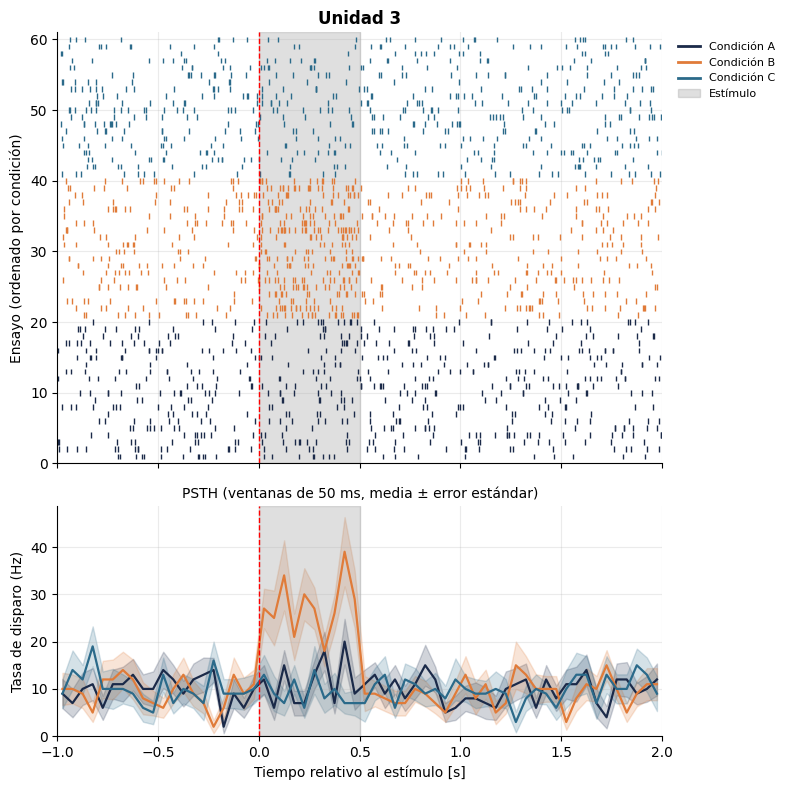

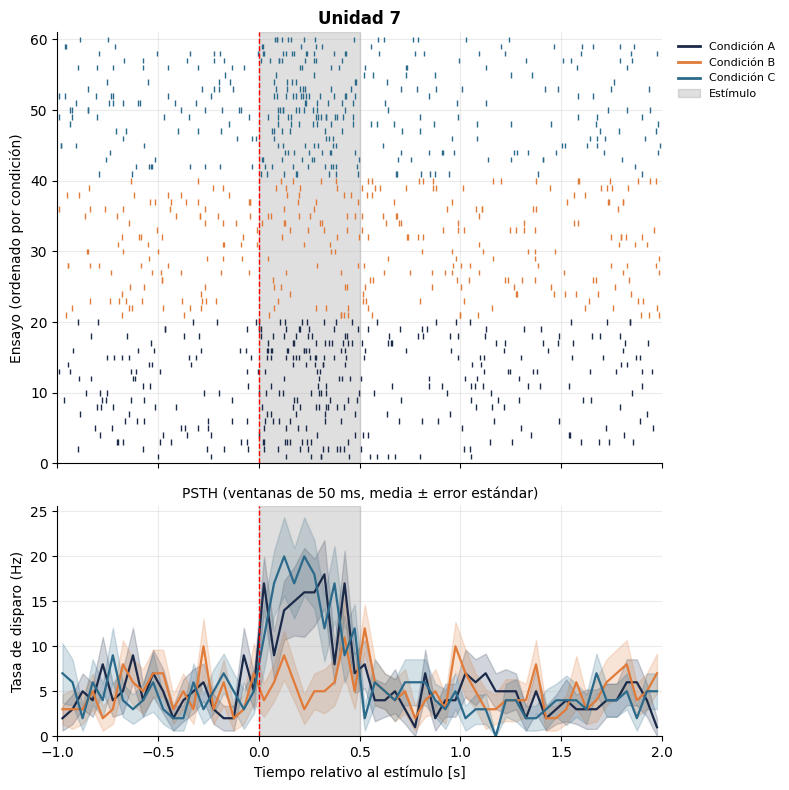

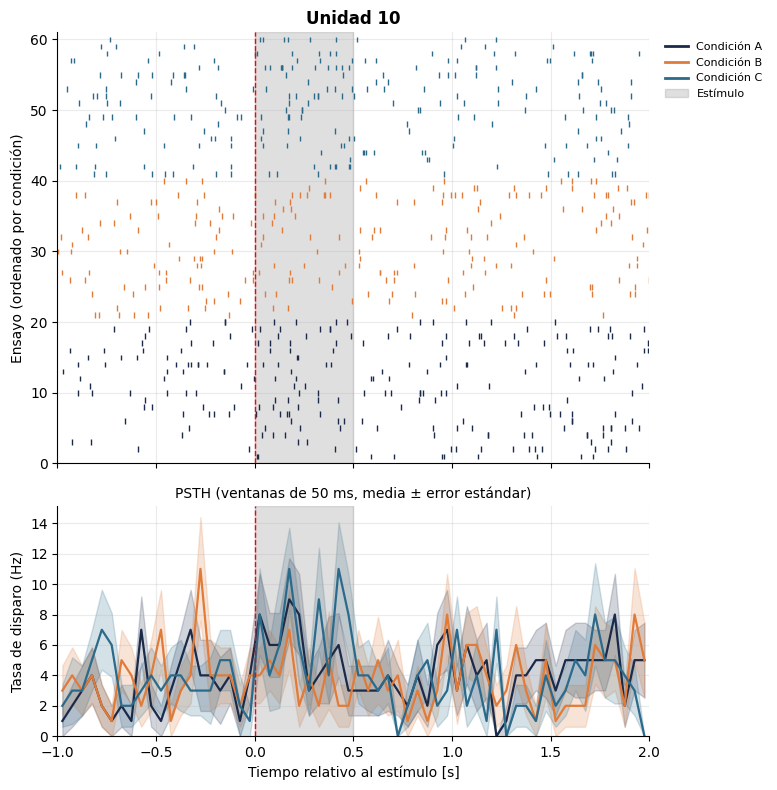

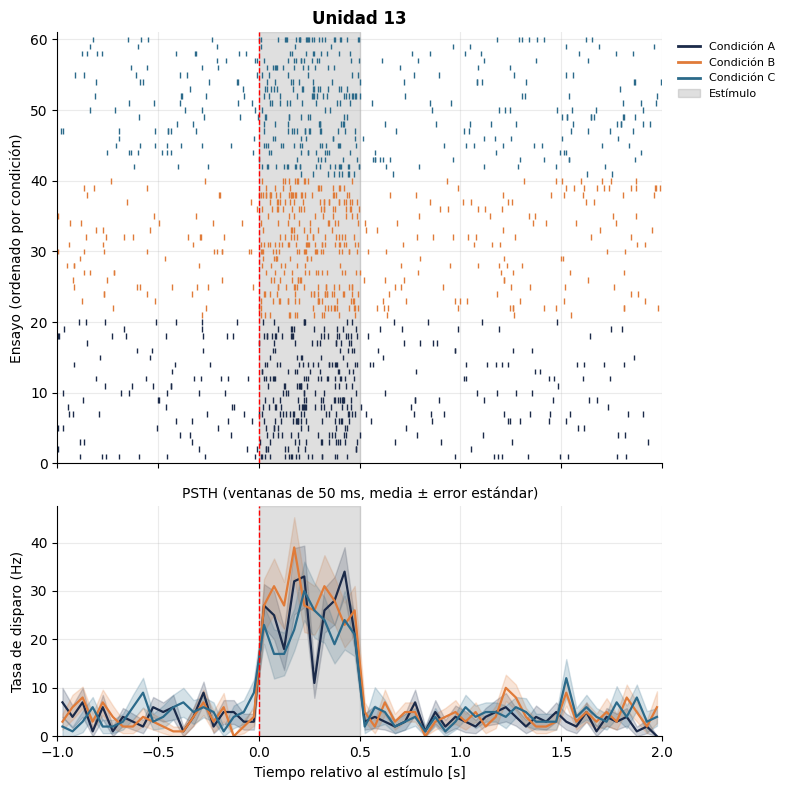

In [89]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ==============================================================================
# PARTE 1: LEER LA TABLA DE ESTÍMULOS DEL ARCHIVO .h5
# ==============================================================================
def leer_estimulos(ruta_h5, clave_grupo='estimulos', clave_inicio=None, clave_condicion=None):
    """Lee el grupo 'estimulos' del registro y devuelve:
       inicios_s : np.ndarray (n_ensayos,) con el instante de inicio de cada ensayo (s)
       condiciones : np.ndarray (n_ensayos,) de str con 'A', 'B' o 'C'
    Si no reconoce los nombres de los datasets, se los pueden pasar en
    clave_inicio y clave_condicion."""
    with h5py.File(ruta_h5, 'r') as f:
        nodo = f[clave_grupo]

        if isinstance(nodo, h5py.Group):
            columnas = {k: nodo[k][:] for k in nodo.keys()}
        else:
            datos = nodo[:]
            columnas = {n: datos[n] for n in datos.dtype.names}

    if clave_inicio is None:
        numericas = [k for k, v in columnas.items() if v.dtype.kind in 'fiu']
        preferidas = [k for k in numericas if any(p in k.lower() for p in ('inicio', 'tiempo', 't_'))]
        clave_inicio = (preferidas or numericas or [None])[0]

    if clave_condicion is None:
        textuales = [k for k, v in columnas.items() if v.dtype.kind in 'SUO']
        clave_condicion = (textuales or [None])[0]

    if clave_inicio is None or clave_condicion is None:
        raise ValueError(f"No pude identificar las columnas. Datasets encontrados en "
                         f"'{clave_grupo}': {list(columnas.keys())}. Pásenlas con "
                         f"clave_inicio=... y clave_condicion=...")

    inicios_s = np.asarray(columnas[clave_inicio], dtype=float)
    condiciones = np.array([c.decode().strip() if isinstance(c, bytes) else str(c).strip()
                            for c in columnas[clave_condicion]])

    orden = np.argsort(inicios_s)
    return inicios_s[orden], condiciones[orden]


# ==============================================================================
# PARTE 2: TIEMPOS ABSOLUTOS -> TIEMPOS RELATIVOS AL ESTÍMULO (Ejercicio 9a)
# ==============================================================================
def a_tiempos_relativos(tiempos_abs, inicio_s, t_min, t_max):
    """Para UN ensayo: toma los disparos que caen entre inicio_s + t_min y
    inicio_s + t_max y les resta inicio_s.
    tiempos_abs debe venir ordenado de menor a mayor."""
    i0 = np.searchsorted(tiempos_abs, inicio_s + t_min, side='left')
    i1 = np.searchsorted(tiempos_abs, inicio_s + t_max, side='left')
    return tiempos_abs[i0:i1] - inicio_s


# ==============================================================================
# PARTE 3: FUNCIÓN PRINCIPAL (tiempos absolutos, raster y PSTH)
# ==============================================================================
def analizar_raster_psth(ruta_h5, res, labels, diccionario_etiquetas,
                         ancho_bin_s=0.05, pre_s=1.0, dur_estimulo_s=0.5, post_estimulo_s=1.5,
                         etiquetas_validas=("good",), clave_inicio=None, clave_condicion=None,
                         mostrar_figuras=True):
    """
    Devuelve (tiempos_absolutos, raster, psth), solo para los grupos con etiqueta en
    etiquetas_validas (por defecto solo "good"):

      tiempos_absolutos : {grupo: np.ndarray}            disparos en segundos desde el inicio del registro
      raster            : {grupo: {cond: [np.ndarray]}}  una lista por condición, un arreglo por ensayo,
                                                         con los disparos en tiempo relativo al estímulo
      psth              : {grupo: {cond: dict}}          centros_s, tasa_hz, sem_hz, ancho_s, n_ensayos
    """
    tiempos_s = res['tiempos_s']

    # Ventana relativa al inicio del estímulo: de -pre_s hasta dur_estimulo + post_estimulo
    t_min, t_max = -pre_s, dur_estimulo_s + post_estimulo_s

    # --- 0) Leer estímulos y avisar qué se cargó ---
    inicios_s, condiciones = leer_estimulos(ruta_h5, clave_inicio=clave_inicio,
                                            clave_condicion=clave_condicion)

    # CORRECCIÓN: 'tiempo_inicio_s' guarda el inicio del ENSAYO (bloque de 3 s),
    # no el inicio del estímulo. El estímulo empieza pre_s segundos después de ese
    # instante, así que corremos la referencia antes de usarla en todo lo demás.
    inicios_s = inicios_s + pre_s

    conds = sorted(str(c) for c in np.unique(condiciones))
    print(f"Estímulos: {len(inicios_s)} ensayos | inicios entre {inicios_s.min():.2f} y "
          f"{inicios_s.max():.2f} s | " +
          ", ".join(f"{c}={np.sum(condiciones == c)}" for c in conds))

    # --- 1) Quedarnos SOLO con los grupos clasificados como good ---
    grupos_ok = sorted(g for g, e in diccionario_etiquetas.items() if e in etiquetas_validas)
    if not grupos_ok:
        print("Ningún grupo tiene una etiqueta válida; no hay nada que graficar.")
        return {}, {}, {}

    # --- 2) Tiempos absolutos de cada grupo (ordenados) ---
    tiempos_absolutos = {int(g): np.sort(tiempos_s[labels == g]) for g in grupos_ok}

    # --- 3) Bordes de las ventanas del PSTH ---
    n_bins = int(round((t_max - t_min) / ancho_bin_s))
    bordes = np.linspace(t_min, t_max, n_bins + 1)
    ancho = bordes[1] - bordes[0]
    centros = (bordes[:-1] + bordes[1:]) / 2.0

    colores_base = {'A': '#1b2a49', 'B': '#e07b39', 'C': '#2b6a8a'}
    colores = {c: colores_base.get(c, plt.cm.tab10(i)) for i, c in enumerate(conds)}

    raster, psth = {}, {}

    for g, t_abs in tiempos_absolutos.items():
        raster[g], psth[g] = {}, {}

        for c in conds:
            inicios_c = inicios_s[condiciones == c]

            ensayos = [a_tiempos_relativos(t_abs, t0, t_min, t_max) for t0 in inicios_c]
            raster[g][c] = ensayos

            conteos = np.array([np.histogram(e, bins=bordes)[0] for e in ensayos])
            tasa_ensayo = conteos / ancho
            tasa_media = tasa_ensayo.mean(axis=0)
            sem = (tasa_ensayo.std(axis=0, ddof=1) / np.sqrt(len(ensayos))
                   if len(ensayos) > 1 else np.zeros(n_bins))

            psth[g][c] = {'centros_s': centros, 'tasa_hz': tasa_media, 'sem_hz': sem,
                          'ancho_s': ancho, 'n_ensayos': len(ensayos)}

    # ==========================================================================
    # FIGURAS
    # ==========================================================================
    if mostrar_figuras:
        for g in tiempos_absolutos:
            fig, (ax_r, ax_p) = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                                             gridspec_kw={'height_ratios': [3, 1.6]})
            fila = 1

            for c in conds:
                ensayos = raster[g][c]
                filas = np.arange(fila, fila + len(ensayos))
                ax_r.eventplot(ensayos, lineoffsets=filas, linelengths=0.8,
                               colors=[colores[c]], linewidths=1.0)
                fila += len(ensayos)

            aviso = "  [NO SOMÁTICA]" if diccionario_etiquetas[g] == "non-somatic" else ""
            ax_r.set_title(f"Unidad {g}{aviso}", fontweight='bold')
            ax_r.set_ylabel("Ensayo (ordenado por condición)")
            ax_r.set_ylim(0, fila)
            leyenda = [Line2D([0], [0], color=colores[c], lw=2, label=f"Condición {c}") for c in conds]
            leyenda.append(plt.Rectangle((0, 0), 1, 1, color='gray', alpha=0.25, label="Estímulo"))
            ax_r.legend(handles=leyenda, loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, frameon=False)

            for c in conds:
                p = psth[g][c]
                ax_p.plot(p['centros_s'], p['tasa_hz'], color=colores[c], lw=1.6, label=f"Condición {c}")
                ax_p.fill_between(p['centros_s'], p['tasa_hz'] - p['sem_hz'],
                                  p['tasa_hz'] + p['sem_hz'], color=colores[c], alpha=0.2)
            ax_p.set_ylabel("Tasa de disparo (Hz)")
            ax_p.set_xlabel("Tiempo relativo al estímulo [s]")
            ax_p.set_title(f"PSTH (ventanas de {ancho * 1000:.0f} ms, media ± error estándar)", fontsize=10)
            ax_p.set_ylim(bottom=0)

            for ax in (ax_r, ax_p):
                ax.axvspan(0, dur_estimulo_s, color='gray', alpha=0.25)
                ax.axvline(0, color='red', ls='--', lw=1)
                ax.set_xlim(t_min, t_max)
                ax.spines[['top', 'right']].set_visible(False)

            plt.tight_layout()
            plt.show()

    return tiempos_absolutos, raster, psth


# ==============================================================================
# USO CON LAS VARIABLES DEL TALLER
# ==============================================================================
tiempos_abs, raster, psth = analizar_raster_psth(
    "taller2_ruidosa.h5", res_ruidosa, labels_elegidos, diccionario_etiquetas,
    ancho_bin_s=0.05)

**P9.**

**Selección múltiple.** Si el ancho de la ventana del PSTH es demasiado grande, lo que ocurre es que

- **a)** el PSTH se llena de picos espurios
- **b)** se pierde la resolución temporal: una respuesta corta queda diluida en la ventana----->Respuesta Correcta
- **c)** cambia el número total de disparos
- **d)** el raster cambia también

**Abierta.** Mirando **sólo el raster**, antes de calcular nada: ¿cuáles unidades responden al
estímulo y a cuáles condiciones? Hagan la lista. Después digan qué ancho de ventana escogieron para
el PSTH y qué se pierde con los otros dos que probaron.

*Su respuesta:*
-Neurona 3 (Responde mejor a la condición B)
-Neurona 7 ( Responde mejor a las condicion A y C)
-Neurona 13 (responde a los 3 estimulos)

Nosotras elegimos el ancho de ventana del PTSH DE 0,5 ya que era ogra el equilibrio ideal entre suavizar el ruido estadístico y preservar la resolución temporal de la respuesta neuronal. Esta amplitud nos permite agrupar suficientes spikes para promediar la alta variabilidad natural entre ensayos y así evitar que el histograma se llene de picos erráticos.

---
# 10 · ¿La respuesta es real? Z-score, t-test y bootstrap

Tres herramientas, y cada una contesta una pregunta distinta. Esto es lo que vieron en las sesiones de
estadística, aplicado a sus propios datos.

**El Z-score responde: ¿cuánto se salió esta unidad de lo que hace normalmente?** Se toma la actividad
basal de la unidad (el segundo anterior al estímulo, en todos los ensayos), se calculan su media y su
desviación estándar, y la respuesta se expresa en cuántas desviaciones estándar por encima de esa
basal quedó. Sirve para **comparar unidades entre sí**, y en este registro hay un caso que lo muestra
bien: dos de las unidades llegan casi a la misma tasa durante el estímulo, unos 41 Hz las dos, pero
una parte de una basal de 4,9 Hz y la otra de 10,6 Hz. En hertz crudos son indistinguibles; en
Z-score, una queda muy por encima de la otra. Ustedes van a encontrar ese par en el ejercicio 12.

**El t-test responde: ¿esta diferencia se explica por el azar?** Compara la tasa durante el estímulo
contra la basal, ensayo por ensayo (pareado), o compara dos condiciones entre sí. Da un valor p, que
es la probabilidad de observar una diferencia al menos tan grande como la que vieron si en realidad no
hubiera ninguna diferencia.

**El bootstrap responde: ¿qué tan precisa es mi medición?** En vez de suponer que los datos siguen una
campana, se remuestrean los ensayos con reemplazo miles de veces, se calcula la media de cada
remuestreo, y se toma el rango que contiene el 95 % central de esas medias. Ese es el intervalo de
confianza. Funciona aunque los datos no sean normales, que es el caso habitual con tasas de disparo.

⚠️ **Trampa conceptual, y es la más importante del taller.** Tienen 20 ensayos por condición, pero esos
20 ensayos son de **la misma neurona en el mismo animal**. No son 20 observaciones independientes de
"cómo responden las neuronas a este estímulo": son 20 observaciones de una sola neurona. Tratarlas
como si fueran independientes para hablar de la población se llama **pseudorreplicación** y es uno de
los errores más comunes en la literatura. Sus conclusiones estadísticas valen **para cada unidad por
separado**, no para "las neuronas de esta estructura".

### ✏️ Ejercicio 10

Para cada unidad `good` y cada condición:

**a)** La tasa basal y la tasa durante el estímulo, ensayo por ensayo.

**b)** El Z-score de la respuesta respecto a la basal de esa unidad.

**c)** Un t-test pareado, basal contra estímulo.

**d)** El intervalo de confianza del 95 % de la tasa evocada, por bootstrap con al menos 5000
remuestreos.

Armen una tabla con todo.

In [90]:
# ✏️ Ejercicio 10
import numpy as np
import pandas as pd
from scipy import stats


def analizar_respuesta(raster, diccionario_etiquetas=None, etiquetas_validas=("good",),
                       dur_basal_s=1.0, dur_estimulo_s=0.5,
                       n_boot=10000, nivel_ic=95, semilla=0, imprimir=True):
    """
    Para cada unidad (solo "good") y cada condición calcula:
      a) tasa basal y tasa durante el estímulo, ensayo por ensayo
      b) Z-score de la respuesta respecto a la basal de la unidad
      c) t-test pareado (basal vs estímulo) con su valor p
      d) IC del 95 % de la tasa evocada por bootstrap (>= 5000 remuestreos)

    Devuelve (tasas, textos, tabla):
      tasas  : {(grupo, cond): {'basal': np.ndarray, 'estimulo': np.ndarray}}  (Hz por ensayo)
      textos : {'a': lista de str, 'b': str, 'c': str, 'd': str}
      tabla  : DataFrame con todo, una fila por unidad y condición
    """
    if n_boot < 5000:
        raise ValueError("El taller pide al menos 5000 remuestreos.")

    rng = np.random.default_rng(semilla)             # semilla fija: el IC sale igual cada vez que se corre

    # --- Solo las unidades "good" (si pasan el diccionario, se filtra de nuevo por seguridad) ---
    grupos = sorted(raster.keys())
    if diccionario_etiquetas is not None:
        grupos = [g for g in grupos if diccionario_etiquetas.get(g) in etiquetas_validas]

    # ==========================================================================
    # a) TASA BASAL Y TASA DURANTE EL ESTÍMULO, ENSAYO POR ENSAYO
    # ==========================================================================
    tasas = {}
    for g in grupos:
        for c in sorted(raster[g].keys()):
            basal, estimulo = [], []
            for disparos in raster[g][c]:            # un arreglo de tiempos relativos por ensayo
                # Basal: el segundo anterior al estímulo, [-dur_basal, 0)
                n_basal = np.sum((disparos >= -dur_basal_s) & (disparos < 0))
                # Estímulo: [0, dur_estimulo)
                n_estim = np.sum((disparos >= 0) & (disparos < dur_estimulo_s))
                # Disparos / duración de la ventana = tasa en Hz
                basal.append(n_basal / dur_basal_s)
                estimulo.append(n_estim / dur_estimulo_s)
            tasas[(g, c)] = {'basal': np.array(basal), 'estimulo': np.array(estimulo)}

    # Lista de texto: una línea por unidad, condición y ensayo
    texto_a = []
    for (g, c), d in tasas.items():
        for i, (b, e) in enumerate(zip(d['basal'], d['estimulo']), start=1):
            texto_a.append(f"Unidad {g} | Cond {c} | ensayo {i:02d}: "
                           f"basal = {b:.1f} Hz, estímulo = {e:.1f} Hz")

    # ==========================================================================
    # b), c), d) POR UNIDAD Y CONDICIÓN
    # ==========================================================================
    filas = []
    lineas_b, lineas_d = [], []
    alfa_bajo, alfa_alto = (100 - nivel_ic) / 2, 100 - (100 - nivel_ic) / 2   # 2.5 y 97.5

    for g in grupos:
        # Basal de la UNIDAD: el segundo previo al estímulo en TODOS sus ensayos (A, B y C juntos).
        # El segundo previo no depende de la condición, así que se usan los 60 ensayos.
        basal_unidad = np.concatenate([tasas[(g, c)]['basal'] for c in sorted(raster[g].keys())])
        mu_basal = basal_unidad.mean()
        sd_basal = basal_unidad.std(ddof=1)          # desviación estándar muestral

        for c in sorted(raster[g].keys()):
            bas = tasas[(g, c)]['basal']
            est = tasas[(g, c)]['estimulo']
            n = len(est)

            # ---- b) Z-score: cuántas desviaciones estándar por encima de la basal ----
            # Z = (tasa media en el estímulo - media basal) / desviación estándar basal
            z = (est.mean() - mu_basal) / sd_basal if sd_basal > 0 else np.nan

            # ---- c) t-test pareado: estímulo vs basal, ensayo por ensayo ----
            # Cada ensayo es una pareja (su basal, su estímulo), por eso es pareado.
            if n > 1 and np.any(est != bas):
                t, p = stats.ttest_rel(est, bas)     # prueba de dos colas
            else:
                t, p = np.nan, np.nan                # sin diferencias no hay t definido

            # ---- d) Bootstrap: IC de la tasa evocada (media de la tasa en el estímulo) ----
            # Se remuestrean los ENSAYOS con reemplazo n_boot veces, se calcula la media de
            # cada remuestreo y se toma el 95 % central de esas medias.
            idx = rng.integers(0, n, size=(n_boot, n))       # (n_boot, n) índices de ensayos
            medias_boot = est[idx].mean(axis=1)              # una media por remuestreo
            ic_bajo, ic_alto = np.percentile(medias_boot, [alfa_bajo, alfa_alto])

            # ¿El IC de la tasa evocada contiene la tasa basal de la unidad? (útil para P10)
            incluye_basal = bool(ic_bajo <= mu_basal <= ic_alto)

            filas.append({
                'Unidad': g, 'Cond': c, 'N': n,
                'Basal_Hz': round(mu_basal, 2), 'SD_basal_Hz': round(sd_basal, 2),
                'Estimulo_Hz': round(est.mean(), 2),
                'Z': round(z, 2) if not np.isnan(z) else np.nan,
                't': round(t, 3) if not np.isnan(t) else np.nan,
                'gl': n - 1, 'p': p,
                'IC95_bajo_Hz': round(ic_bajo, 2), 'IC95_alto_Hz': round(ic_alto, 2),
                'IC_incluye_basal': incluye_basal,
            })

            lineas_b.append(f"Unidad {g} | Cond {c}: Z = {z:+.2f}  "
                            f"(estímulo {est.mean():.1f} Hz vs basal {mu_basal:.1f} ± {sd_basal:.1f} Hz)")
            lineas_d.append(f"Unidad {g} | Cond {c}: tasa evocada {est.mean():.1f} Hz, "
                            f"IC {nivel_ic} % bootstrap [{ic_bajo:.1f}, {ic_alto:.1f}] Hz "
                            f"({'incluye' if incluye_basal else 'no incluye'} la basal de {mu_basal:.1f} Hz)")

    tabla = pd.DataFrame(filas)

    # --- Textos de salida ---
    texto_b = "\n".join(lineas_b)
    # Tabla de texto del t-test: p muy pequeños se muestran como "<0.0001"
    fmt_p = lambda p: "n/d" if pd.isna(p) else ("<0.0001" if p < 1e-4 else f"{p:.4f}")
    tabla_t = tabla[['Unidad', 'Cond', 'N', 't', 'gl', 'p']].copy()
    tabla_t['p'] = tabla_t['p'].map(fmt_p)
    texto_c = tabla_t.to_string(index=False)
    texto_d = "\n".join(lineas_d)
    textos = {'a': texto_a, 'b': texto_b, 'c': texto_c, 'd': texto_d}

    if imprimir:
        print(f"=== a) Tasas por ensayo: {len(texto_a)} líneas (en textos['a']) ===")
        print("\n=== b) Z-score respecto a la basal de la unidad ===\n" + texto_b)
        print("\n=== c) t-test pareado (basal vs estímulo) ===\n" + texto_c)
        print(f"\n=== d) Bootstrap ({n_boot} remuestreos) ===\n" + texto_d)
        print("\n=== Tabla completa ===")
        tabla_imp = tabla.copy()
        tabla_imp['p'] = tabla_imp['p'].map(fmt_p)
        print(tabla_imp.to_string(index=False))
        print("\nNota: los 20 ensayos de cada condición son observaciones de UNA sola neurona, "
              "no de la población.\nLos p y los IC valen para cada unidad por separado "
              "(pseudorreplicación si se generalizan).")

    return tasas, textos, tabla


# ==============================================================================
# USO CON LAS VARIABLES DEL TALLER
# ==============================================================================
# `raster` viene de analizar_raster_psth() (Ejercicio 9), que debe correrse con
# pre_s=1.0 (por defecto) para que exista el segundo basal completo.
tasas, textos_ej10, tabla_ej10 = analizar_respuesta(raster, diccionario_etiquetas)

=== a) Tasas por ensayo: 240 líneas (en textos['a']) ===

=== b) Z-score respecto a la basal de la unidad ===
Unidad 3 | Cond A: Z = +0.54  (estímulo 11.4 Hz vs basal 9.8 ± 3.0 Hz)
Unidad 3 | Cond B: Z = +5.91  (estímulo 27.6 Hz vs basal 9.8 ± 3.0 Hz)
Unidad 3 | Cond C: Z = -0.16  (estímulo 9.3 Hz vs basal 9.8 ± 3.0 Hz)
Unidad 7 | Cond A: Z = +4.29  (estímulo 13.7 Hz vs basal 4.7 ± 2.1 Hz)
Unidad 7 | Cond B: Z = +0.63  (estímulo 6.0 Hz vs basal 4.7 ± 2.1 Hz)
Unidad 7 | Cond C: Z = +5.05  (estímulo 15.3 Hz vs basal 4.7 ± 2.1 Hz)
Unidad 10 | Cond A: Z = +1.15  (estímulo 5.8 Hz vs basal 3.5 ± 2.0 Hz)
Unidad 10 | Cond B: Z = +0.12  (estímulo 3.7 Hz vs basal 3.5 ± 2.0 Hz)
Unidad 10 | Cond C: Z = +1.74  (estímulo 7.0 Hz vs basal 3.5 ± 2.0 Hz)
Unidad 13 | Cond A: Z = +9.25  (estímulo 25.5 Hz vs basal 4.1 ± 2.3 Hz)
Unidad 13 | Cond B: Z = +10.54  (estímulo 28.5 Hz vs basal 4.1 ± 2.3 Hz)
Unidad 13 | Cond C: Z = +7.86  (estímulo 22.3 Hz vs basal 4.1 ± 2.3 Hz)

=== c) t-test pareado (basal vs est

**P10.**

**Selección múltiple.** Una unidad tiene la tasa evocada más alta en hertz, pero no el Z-score más
alto. La explicación es que

- **a)** tiene menos ensayos que las demás
- **b)** su actividad basal es más variable, y el Z-score divide por esa variabilidad------>Respuesta Correcta
- **c)** el t-test no se le puede aplicar
- **d)** su respuesta empieza más tarde

**Abierta.** Elijan una unidad cuyo t-test dé un p pequeño y otra que dé un p grande, y expliquen la
diferencia mirando la **variabilidad entre ensayos**, no sólo las medias. ¿Algún intervalo de
confianza por bootstrap incluye la tasa basal? ¿Qué concluyen de esa unidad?

*Su respuesta:*

Nosotras elegimos la unidad 10 ya que , en la misma neurona, para diferentes estimulos, se muestra un valor p grande ( Condición B) y un valor p pequeño (Condición A) . La diefrencia entre estos dos es que: en la Condición A, la neurona exhibe un aumento real a 5,8 Hz (p = 0,0004, t = 4,27), tiene una baja dispersión (SD ≈ 2,46 Hz) y un intervalo de confianza bootstrap [4,8 – 6,8] Hz que excluye la línea base. En cambio, en la Condición B, el pequeño salto a 3,7 Hz (p = 0,8833, t = −0,149) no es distinguible del ruido debido a una variabilidad entre ensayos tres veces mayor (SD ≈ 7,5 Hz),lo que tambien se ve reflejado en el intervalo bootstrap [2,6 – 5,0] Hz que sí contiene la tasa basal. Con esta información, concluimos que esta unidad presenta una selectividad hacia el estímulo A y no hay respuesta ante el estimulo B.

---
# 11 · La figura final

Una figura de resultados de cuatro paneles, con todas las unidades `good` juntas. Esta sección se
califica panel por panel.

**Panel A.** La sonda con las unidades ubicadas en su centroide de profundidad, y al lado la forma de
onda promedio de cada una. Es la figura que dice "esto fue lo que registramos".

**Panel B.** El raster de una sola unidad, con las tres condiciones. Escojan una que responda a una
condición y no a las otras, que es la que hace visible el contraste.

**Panel C.** **El PSTH general por estímulo**: todas las unidades `good` promediadas, una curva por
condición, con su banda de confianza.

**Panel D.** **El swarmplot por estímulo**: un punto por ensayo, agrupados por condición, con la media
y su intervalo de confianza encima. Un swarmplot muestra todos los datos, que es lo que un diagrama de
barras esconde.

**Reglas de figura científica, y aquí sí se evalúan una por una:**

1. Todos los ejes rotulados, con unidades.
2. Escalas de tiempo iguales entre paneles que se comparan.
3. Nada de rojo y verde como única distinción entre categorías.
4. La ventana del estímulo marcada de la misma forma en todos los paneles.
5. Cada panel legible sin leer el texto: si hay que explicarlo, falta un rótulo.
6. Pie de figura que diga qué se muestra, cuántos ensayos y qué representan las barras de error.

### ✏️ Ejercicio 11

Estímulos: 60 ensayos | inicios entre 21.00 y 198.00 s | A=20, B=20, C=20


/tmp/ipykernel_1727/3485216113.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.97])


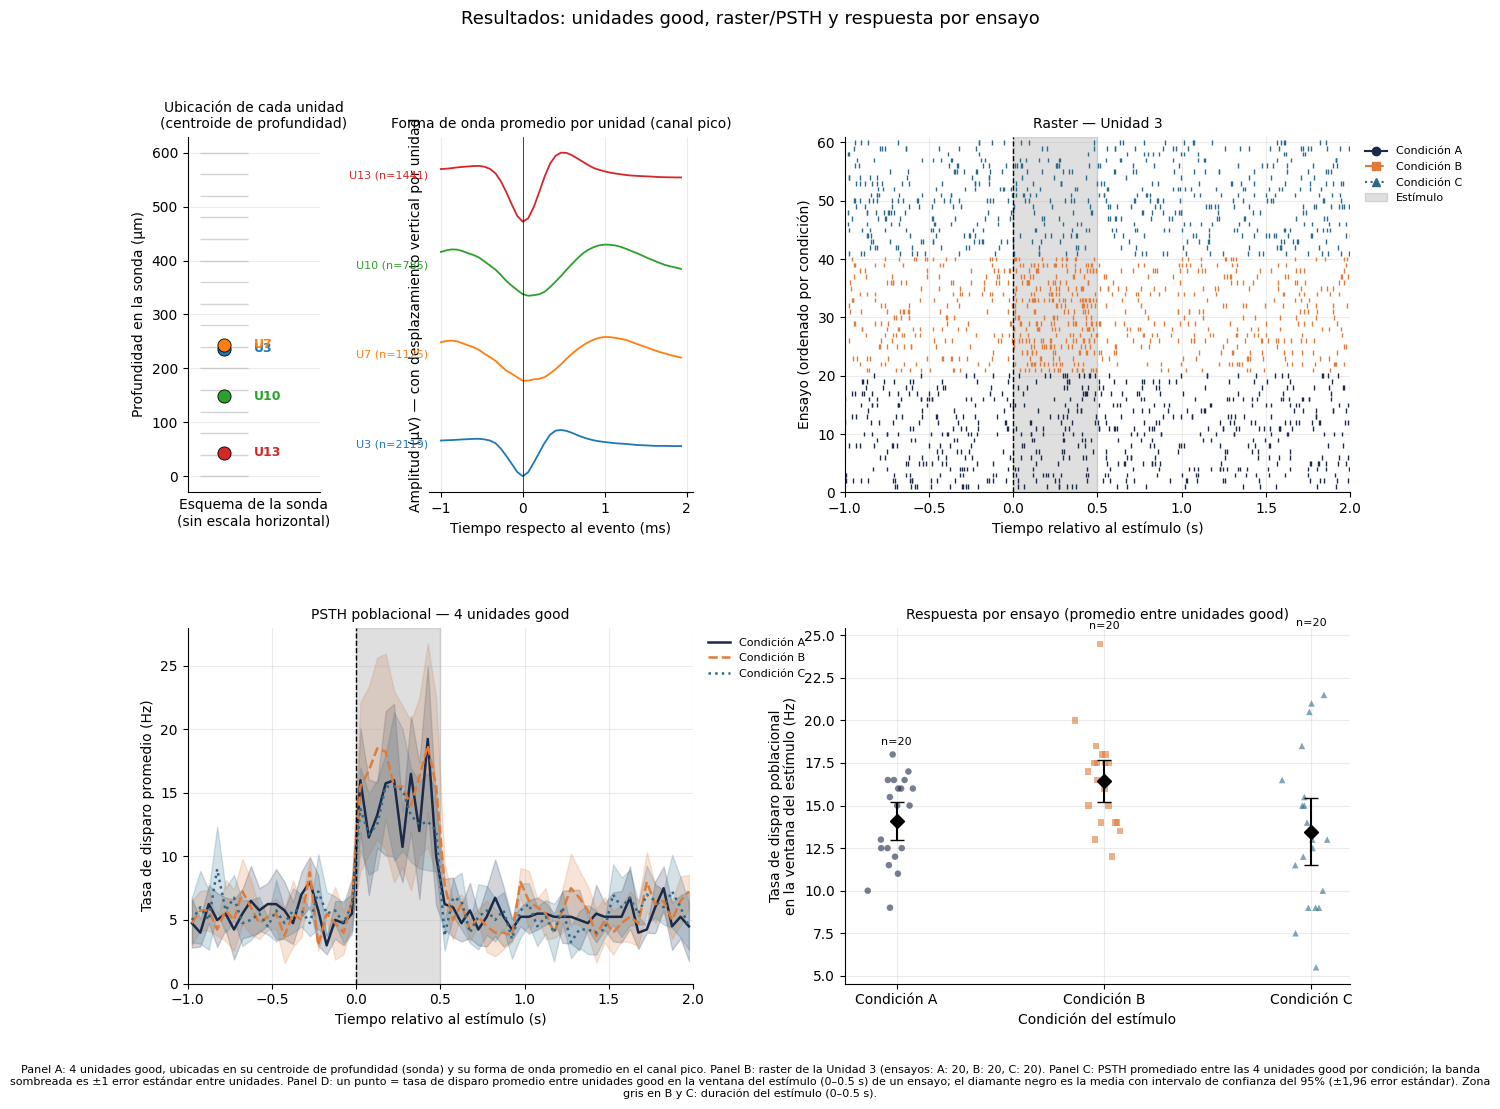

In [91]:
# ✏️ Ejercicio 11
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ==============================================================================
# ESTILO COMÚN A TODA LA FIGURA (una sola fuente de verdad para colores/formas)
# ==============================================================================
# Mismos colores de la Sección 9 (azul oscuro / naranja / verde azulado):
# ninguna pareja rojo-verde, y cada condición además tiene su propio marcador
# y estilo de línea, para no depender solo del color.
COLOR_COND = {'A': '#1b2a49', 'B': '#e07b39', 'C': '#2b6a8a'}
ESTILO_COND = {'A': dict(marker='o', linestyle='-'),
               'B': dict(marker='s', linestyle='--'),
               'C': dict(marker='^', linestyle=':')}

# Paleta para las unidades individuales del Panel A (categórica, sin rojo/verde)
PALETA_UNIDADES = plt.cm.tab10.colors

PRE_S, DUR_ESTIMULO_S, POST_S = 1.0, 0.5, 1.5     # igual que analizar_raster_psth
T_MIN, T_MAX = -PRE_S, DUR_ESTIMULO_S + POST_S    # eje de tiempo común a B y C


# ==============================================================================
# CENTROIDE DE PROFUNDIDAD POR GRUPO (misma fórmula de la Sección 4,
# aplicada al perfil promedio del grupo en vez de evento por evento)
# ==============================================================================
def centroide_grupo(onda_16canales, y_um, frac_centroide=0.30):
    """onda_16canales: forma de onda promedio del grupo, (canales, muestras).
    Devuelve el centroide de profundidad (µm) de ese grupo."""
    perfil = -onda_16canales.min(axis=1)                       # amplitud por canal (µV, positiva)
    umbral = frac_centroide * perfil.max()
    perfil_filtrado = np.where(perfil >= umbral, perfil, 0.0)
    return float((perfil_filtrado * y_um).sum() / perfil_filtrado.sum())


# ==============================================================================
# FIGURA DE 4 PANELES
# ==============================================================================
def figura_resultados_final(ruta_h5, res, labels, diccionario_etiquetas,
                            unidad_raster=3, ancho_bin_s=0.05, frac_centroide=0.30):

    grupos_good = sorted(g for g, e in diccionario_etiquetas.items() if e == "good")
    if unidad_raster not in grupos_good:
        raise ValueError(f"La unidad {unidad_raster} no está etiquetada 'good'.")

    tiempos_s = res['tiempos_s']
    waveforms = res['formas_onda']
    y_um = res['y_um']
    fs = res['fs']
    n_muestras = waveforms.shape[2]
    t_ms = (np.arange(n_muestras) - int(round(PRE_S * 1000 / 1000.0 * fs / 1000))) / fs * 1000.0
    # eje de tiempo de la forma de onda: pre_ms=1.0 (extraer_formas_onda, Sección 2)
    t_ms = (np.arange(n_muestras) - int(round(1.0 / 1000.0 * fs))) / fs * 1000.0

    # ---- Datos por grupo: centroide, canal pico, forma de onda promedio, n ----
    info = {}
    for g in grupos_good:
        idx = np.where(labels == g)[0]
        onda_16 = waveforms[idx].mean(axis=0)                  # (canales, muestras)
        canal_pico = int(np.argmin(onda_16.min(axis=1)))
        info[g] = {
            'n': len(idx),
            'centroide_um': centroide_grupo(onda_16, y_um, frac_centroide),
            'onda_pico': onda_16[canal_pico],
            'canal_pico': canal_pico,
        }

    # ---- Reutiliza la Sección 9 para raster/PSTH de TODAS las unidades good ----
    # (asume que ya corrigieron inicios_s = inicios_s + pre_s dentro de esta función)
    _, raster, psth = analizar_raster_psth(
        ruta_h5, res, labels, diccionario_etiquetas,
        ancho_bin_s=ancho_bin_s, pre_s=PRE_S, dur_estimulo_s=DUR_ESTIMULO_S,
        post_estimulo_s=POST_S, mostrar_figuras=False)

    conds = sorted(psth[grupos_good[0]].keys())                # ['A', 'B', 'C']
    n_ensayos_cond = {c: psth[grupos_good[0]][c]['n_ensayos'] for c in conds}

    # ==========================================================================
    # ARMADO DE LA FIGURA
    # ==========================================================================
    fig = plt.figure(figsize=(15, 11))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], hspace=0.38, wspace=0.30)
    gs_A = gs[0, 0].subgridspec(1, 2, width_ratios=[1, 2], wspace=0.55)
    ax_probe = fig.add_subplot(gs_A[0, 0])
    ax_ondas = fig.add_subplot(gs_A[0, 1])
    ax_raster = fig.add_subplot(gs[0, 1])
    ax_psth = fig.add_subplot(gs[1, 0])
    ax_swarm = fig.add_subplot(gs[1, 1])

    # -------------------------------------------------------------------------
    # PANEL A (izquierda): esquema de la sonda con cada unidad en su centroide
    # -------------------------------------------------------------------------
    for y in y_um:
        ax_probe.hlines(y, -0.4, 0.4, color='lightgray', linewidth=1, zorder=1)
    for i, g in enumerate(grupos_good):
        color = PALETA_UNIDADES[i % len(PALETA_UNIDADES)]
        x_jit = 0.0
        ax_probe.scatter(x_jit, info[g]['centroide_um'], s=90, color=color,
                         edgecolor='black', linewidth=0.6, zorder=3)
        ax_probe.text(0.5, info[g]['centroide_um'], f"U{g}", va='center', fontsize=9,
                     color=color, fontweight='bold')
    ax_probe.set_xlim(-0.6, 1.6)
    ax_probe.set_xticks([])
    ax_probe.set_xlabel("Esquema de la sonda\n(sin escala horizontal)")
    ax_probe.set_ylabel("Profundidad en la sonda (µm)")
    ax_probe.set_title("Ubicación de cada unidad\n(centroide de profundidad)", fontsize=10)
    ax_probe.spines[['top', 'right']].set_visible(False)

    # -------------------------------------------------------------------------
    # PANEL A (derecha): forma de onda promedio de cada unidad, apiladas
    # -------------------------------------------------------------------------
    paso_offset = 1.3 * max(np.ptp(info[g]['onda_pico']) for g in grupos_good)
    for i, g in enumerate(grupos_good):
        color = PALETA_UNIDADES[i % len(PALETA_UNIDADES)]
        offset = i * paso_offset
        ax_ondas.plot(t_ms, info[g]['onda_pico'] + offset, color=color, linewidth=1.3)
        ax_ondas.text(t_ms[0] - 0.15, offset, f"U{g} (n={info[g]['n']})",
                     va='center', ha='right', fontsize=8, color=color)
    ax_ondas.axvline(0, color='black', linewidth=0.5)
    ax_ondas.set_xlabel("Tiempo respecto al evento (ms)")
    ax_ondas.set_ylabel("Amplitud (µV) — con desplazamiento vertical por unidad")
    ax_ondas.set_yticks([])
    ax_ondas.set_title("Forma de onda promedio por unidad (canal pico)", fontsize=10)
    ax_ondas.spines[['top', 'right', 'left']].set_visible(False)

    # -------------------------------------------------------------------------
    # PANEL B: raster de la unidad elegida (por defecto, Unidad 3), 3 condiciones
    # -------------------------------------------------------------------------
    fila = 1
    for c in conds:
        ensayos = raster[unidad_raster][c]
        filas = np.arange(fila, fila + len(ensayos))
        ax_raster.eventplot(ensayos, lineoffsets=filas, linelengths=0.8,
                            colors=[COLOR_COND[c]], linewidths=1.0)
        fila += len(ensayos)
    ax_raster.axvspan(0, DUR_ESTIMULO_S, color='gray', alpha=0.25)
    ax_raster.axvline(0, color='black', linestyle='--', linewidth=1)
    ax_raster.set_xlim(T_MIN, T_MAX)
    ax_raster.set_ylim(0, fila)
    ax_raster.set_xlabel("Tiempo relativo al estímulo (s)")
    ax_raster.set_ylabel("Ensayo (ordenado por condición)")
    ax_raster.set_title(f"Raster — Unidad {unidad_raster}", fontsize=10)
    leyenda_b = [Line2D([0], [0], color=COLOR_COND[c], marker=ESTILO_COND[c]['marker'],
                        linestyle=ESTILO_COND[c]['linestyle'], label=f"Condición {c}")
                for c in conds]
    leyenda_b.append(plt.Rectangle((0, 0), 1, 1, color='gray', alpha=0.25, label="Estímulo"))
    ax_raster.legend(handles=leyenda_b, loc='upper left', bbox_to_anchor=(1.01, 1),
                     fontsize=8, frameon=False)
    ax_raster.spines[['top', 'right']].set_visible(False)

    # -------------------------------------------------------------------------
    # PANEL C: PSTH poblacional — promedio de TODAS las unidades good por condición
    # -------------------------------------------------------------------------
    for c in conds:
        tasas_unidades = np.array([psth[g][c]['tasa_hz'] for g in grupos_good])  # (n_unidades, n_bins)
        centros = psth[grupos_good[0]][c]['centros_s']
        media = tasas_unidades.mean(axis=0)
        sem = tasas_unidades.std(axis=0, ddof=1) / np.sqrt(len(grupos_good))
        ax_psth.plot(centros, media, color=COLOR_COND[c], linewidth=1.8,
                    linestyle=ESTILO_COND[c]['linestyle'], label=f"Condición {c}")
        ax_psth.fill_between(centros, media - sem, media + sem, color=COLOR_COND[c], alpha=0.2)
    ax_psth.axvspan(0, DUR_ESTIMULO_S, color='gray', alpha=0.25)
    ax_psth.axvline(0, color='black', linestyle='--', linewidth=1)
    ax_psth.set_xlim(T_MIN, T_MAX)
    ax_psth.set_ylim(bottom=0)
    ax_psth.set_xlabel("Tiempo relativo al estímulo (s)")
    ax_psth.set_ylabel("Tasa de disparo promedio (Hz)")
    ax_psth.set_title(f"PSTH poblacional — {len(grupos_good)} unidades good", fontsize=10)
    ax_psth.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, frameon=False)
    ax_psth.spines[['top', 'right']].set_visible(False)

    # -------------------------------------------------------------------------
    # PANEL D: swarmplot — tasa poblacional por ensayo, agrupada por condición
    # -------------------------------------------------------------------------
    datos_por_cond = {}
    for c in conds:
        n_ensayos = len(raster[grupos_good[0]][c])
        tasas_ensayo = np.zeros(n_ensayos)
        for i in range(n_ensayos):
            # promedio, entre unidades good, de los disparos en la ventana del
            # estímulo (0 a dur_estimulo_s) de ESE ensayo, en Hz
            conteos = [np.sum((raster[g][c][i] >= 0) & (raster[g][c][i] <= DUR_ESTIMULO_S))
                      for g in grupos_good]
            tasas_ensayo[i] = np.mean(conteos) / DUR_ESTIMULO_S
        datos_por_cond[c] = tasas_ensayo

    for i, c in enumerate(conds):
        y = datos_por_cond[c]
        x = np.random.default_rng(0).normal(i, 0.06, size=len(y))   # jitter fijo (reproducible)
        ax_swarm.scatter(x, y, color=COLOR_COND[c], marker=ESTILO_COND[c]['marker'],
                         s=22, alpha=0.6, edgecolor='none', zorder=2)
        media = y.mean()
        sem = y.std(ddof=1) / np.sqrt(len(y))
        ic95 = 1.96 * sem
        ax_swarm.errorbar(i, media, yerr=ic95, fmt='D', color='black', markersize=7,
                          capsize=5, elinewidth=1.5, zorder=3)
        ax_swarm.text(i, ax_swarm.get_ylim()[1], f"n={len(y)}", ha='center', va='bottom', fontsize=8)

    ax_swarm.set_xticks(range(len(conds)))
    ax_swarm.set_xticklabels([f"Condición {c}" for c in conds])
    ax_swarm.set_xlabel("Condición del estímulo")
    ax_swarm.set_ylabel("Tasa de disparo poblacional\nen la ventana del estímulo (Hz)")
    ax_swarm.set_title("Respuesta por ensayo (promedio entre unidades good)", fontsize=10)
    ax_swarm.spines[['top', 'right']].set_visible(False)

    # -------------------------------------------------------------------------
    # PIE DE FIGURA
    # -------------------------------------------------------------------------
    texto_n = ", ".join(f"{c}: {n_ensayos_cond[c]}" for c in conds)
    fig.suptitle("Resultados: unidades good, raster/PSTH y respuesta por ensayo", fontsize=13, y=0.995)
    fig.text(0.5, 0.005,
             f"Panel A: {len(grupos_good)} unidades good, ubicadas en su centroide de profundidad "
             f"(sonda) y su forma de onda promedio en el canal pico. "
             f"Panel B: raster de la Unidad {unidad_raster} (ensayos: {texto_n}). "
             f"Panel C: PSTH promediado entre las {len(grupos_good)} unidades good por condición; "
             f"la banda sombreada es ±1 error estándar entre unidades. "
             f"Panel D: un punto = tasa de disparo promedio entre unidades good en la ventana del "
             f"estímulo (0–{DUR_ESTIMULO_S} s) de un ensayo; el diamante negro es la media con "
             f"intervalo de confianza del 95% (±1,96 error estándar). "
             f"Zona gris en B y C: duración del estímulo (0–{DUR_ESTIMULO_S} s).",
             ha='center', va='bottom', fontsize=8, wrap=True)

    plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    plt.show()
    return fig


# ==============================================================================
# USO
# ==============================================================================
fig = figura_resultados_final(
    "taller2_ruidosa.h5", res_ruidosa, labels_elegidos, diccionario_etiquetas,
    unidad_raster=3, ancho_bin_s=0.05)

**P11.**

**Selección múltiple.** El PSTH general del panel C promedia unidades que responden a cosas
distintas. Lo que ese promedio esconde es

- **a)** el número total de disparos
- **b)** la selectividad de cada unidad: mezcla respuestas a condiciones distintas en una sola curva ---> correcta
- **c)** la latencia de la respuesta
- **d)** la tasa basal

**Abierta.** Escriban el pie de la figura completo, como iría en un artículo: qué hay en cada panel,
cuántas unidades, cuántos ensayos, qué son las barras de error.

*Su respuesta:*
Figura 1. Resumen de la actividad neuronal registrada y respuesta poblacional a los estímulos. El Panel A muestra el registro base con las 4 unidades clasificadas como good (U3, U7, U10, U13), junto con su forma de onda promedio en el canal pico. El Panel B presenta el raster de la Unidad 3, la cual fue seleccionada por responder únicamente a la Condición B (p < 0,0001 frente a la tasa basal) pero no a las condiciones A ni C (p = 0,26 y p = 0,35, respectivamente). Para este panel se graficó un punto por disparo a lo largo de 20 ensayos por condición e indicando la duración del estímulo (0–0,5 s) con una franja gris. El Panel C muestra el PSTH poblacional con la tasa de disparo promediada de estas 4 unidades para cada condición, donde la banda sombreada de ±1 error estándar se calcula entre las 4 unidades para reflejar la consistencia de la respuesta de una neurona a otra, no la variabilidad entre ensayos. Finalmente, el Panel D muestra un swarmplot en el que cada punto representa la tasa promediada de las 4 unidades durante la ventana del estímulo para un solo ensayo. Esto  expone la dispersión de los 20 ensayos por condición (algo que un diagrama de barras ocultaría), resaltando la media con un diamante negro y el intervalo de confianza del 95%  mediante barras de error.


---
# 12 · Conclusión y conversación con la IA

### ✏️ Ejercicio 12a · El párrafo de resultados

Escriban un párrafo de resultados, como iría en un artículo. Máximo 200 palabras. Tiene que decir:
cuántas unidades registraron y cuántas sobrevivieron a la curación, qué criterios usaron para
descartar las demás, qué unidades respondieron a qué condiciones, y con qué evidencia estadística.

Nada de "se observó que" ni "los datos sugieren". Números.

**Resultados:**

El algoritmo de detenccion y clasificación identificó 16 grupos candidatas (K=16), de las cuales solo 4 sobrevivieron a la selección manual como unidades "good" (grupo 3, 7, 10 y 13). Los 12 grupos restantes fueron descartas por presentar actividad de ruido, o violación del periodo refractario (actividad no nula en la banda de 0,5-2ms del autocorrelogrma), contaminación entre canales. Entre las unidades clasificadas como "good", la respuesta al estimulo fue selectiva por condición. En la unidad 3 respondió exclusivamente a la condición B (t=7,79; gl=19; p<0,0001; IC95% 23,7–31,9 Hz ), sin cambios significativos en A (p=0.2585 ) y C (p= 0.3496). Las unidades 7 y 10 mostraron el patrón inverso, respondiendo a A y C pero no a B (unidad 7: t=6,92 y t=8,42, ambos p<0,0001; unidad 10: t=4,27 y t=2,66, p=0,0004 y p=0,015). La unidad 13 fue la única que respondió a las tres condiciones simultáneamente, como se puede observar en el Raster de la seccion 9.

### ✏️ Ejercicio 12b · Tres intercambios con la IA

Documenten tres momentos en que la IA les dio algo equivocado y ustedes lo corrigieron. Para cada uno:
el prompt, la respuesta del modelo, qué estaba mal y cómo lo arreglaron.

Vale más un error entendido que tres respuestas correctas.

Intercambio 1

Prompt: Tengo un trabajo en Google Collab, en el lenguaje de programación de Phyton. Necesito un codigo que me permita abrir un archivo .h5 (formato HDF5, Hierarchical Data Format). Ademas, necesito una explicación de como se abre y porque se abre de esa forma. Ten en cuenta que en este codigo debe avrir con : "with ... as f: " para que quede cerrado ya que un .h5 abierto dos veces en modo escritura se corrompe.

Respuesta del modelo:

Qué estaba mal:

Cómo lo corregimos:

Intercambio 2

Prompt:

Tengo un trabajo en Google Collab, en el lenguaje de programación de Phyton. Necesito un codigo que me permita abrir el archivo "taller2_limpia.h5 " (formato HDF5, Hierarchical Data Format). Ademas, necesito que este codigo tambén sea capaz de y averigüar qué contiene dicho archivo: los grupos, los conjuntos de datos, la frecuencia de muestreo, el factor de conversión a microvoltios y las posiciones de los sitios. Teniendo en cuenta que el output del codigo anterior ( es decir, la exploración del archivo taller 2) fue : " === ATRIBUTOS GLOBALES (raíz) === descripcion: Sonda lineal de 16 sitios, registro limpio sin estimulos. Curso: De la neurona a la figura, Taller 2. duracion_s: 90.0 escala_uV_por_bit: 0.195 frecuencia_muestreo_hz: 15000 n_canales: 16 unidades: microvoltios tras multiplicar por escala_uV_por_bit Frecuencia de muestreo (fs): None Factor de conversión a microvoltios: None. " Necesito que hagas un codigo que sea capaz de dibujar la sonda: un punto por sitio, en su posición real, con el número de canal al lado. También ten en cuenta que la estructura interna del archivo .h5 es la siguiente : " " === ESTRUCTURA DEL ARCHIVO === [Grupo] geometria [Dataset] geometria/canal_x_um -> shape=(16,), dtype=float64 [Dataset] geometria/canal_y_um -> shape=(16,), dtype=float64 [Grupo] registro [Dataset] registro/datos -> shape=(16, 1350000), dtype=int16 [Grupo] verdad [Dataset] verdad/artefactos_lentos_s -> shape=(0,), dtype=float64 [Dataset] verdad/canal_pico -> shape=(2337,), dtype=int8 [Dataset] verdad/clase_objetivo -> shape=(4,), dtype=|S12 [Dataset] verdad/perfil_uv -> shape=(4, 16), dtype=float32 [Dataset] verdad/pt_ms -> shape=(4,), dtype=float64 [Dataset] verdad/tiempos_s -> shape=(2337,), dtype=float64 [Dataset] verdad/unidad -> shape=(2337,), dtype=int8 [Dataset] verdad/unidades_buenas -> shape=(4,), dtype=int8"

Respuesta del modelo:

El siguiente codigo : import h5py import numpy as np import matplotlib.pyplot as plt

ruta = "taller2_limpia.h5"

with h5py.File(ruta, "r") as f: x = f["geometria/canal_x_um"][:] y = f["geometria/canal_y_um"][:] n_canales = f.attrs.get("n_canales", len(x))

fig, ax = plt.subplots(figsize=(4, 8))

ax.scatter(x, y, s=120, c="steelblue", edgecolors="black", zorder=3)

for canal in range(n_canales): ax.annotate( str(canal), (x[canal], y[canal]), textcoords="offset points", xytext=(8, 0), fontsize=10, va="center" )

ax.set_xlabel("Posición X (µm)") ax.set_ylabel("Posición Y (µm)") ax.set_title("Sonda lineal – 16 sitios de registro") ax.set_aspect("equal") ax.invert_yaxis() # canal 0 arriba, convención típica de sondas lineales plt.tight_layout() plt.show() #

Qué estaba mal:

Habia un sobrelapamiento al final de la grafica

Cómo lo corregimos:

Le pedí a la misma IA en el mismo intercambio y podía corregir el grafico y lo corriguio correctamente. Para esto, cambio tambén un poco el formato inicial y la volvio incluso mas clara

**Intercambio 3**

*Prompt:*Necesito una funcion que grafique una figura final de resultados de cuatro paneles, con todas las unidades que tienen la etiqueta "good" juntas.    

Para el panel A, necesito que grafiques la sonda con las unidades ubicadas en su centroide de profundidad, y al lado la forma de onda promedio de cada una. Es la figura que dice "esto fue lo que registramos. Usa este codigo como molde para el centroide de profundidad (proporciono codigo de seccion 4) y este código para la forma de onda promedio (proporciono codigo de seccion 7)  

Luego, el panel B debe contener El raster de la NEURONA 3, con las tres condiciones. Usa este código como molde y actualízalo para que solo salga la neurona 3 (proporciono codigo de seccion 9).  

Luego, para el panel C, grafica El PSTH general por estímulo, es decir, todas las unidades good promediadas, una curva por condición, con su banda de confianza. Usa este código como molde y actualízalo para que solo salga la neurona 3 (proporciono codigo de seccion 9).

Por ultimo, en el  Panel D debes graficar El swarmplot por estímulo, es decir, un punto por ensayo, agrupados por condición, con la media y su intervalo de confianza encima.  



*Respuesta del modelo:*
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D

# ==============================================================================
# ESTILO COMÚN A TODA LA FIGURA (una sola fuente de verdad para colores/formas)
# ==============================================================================
# Mismos colores de la Sección 9 (azul oscuro / naranja / verde azulado):
# ninguna pareja rojo-verde, y cada condición además tiene su propio marcador
# y estilo de línea, para no depender solo del color.
COLOR_COND = {'A': '#1b2a49', 'B': '#e07b39', 'C': '#2b6a8a'}
ESTILO_COND = {'A': dict(marker='o', linestyle='-'),
               'B': dict(marker='s', linestyle='--'),
               'C': dict(marker='^', linestyle=':')}

# Paleta para las unidades individuales del Panel A (categórica, sin rojo/verde)
PALETA_UNIDADES = plt.cm.tab10.colors

PRE_S, DUR_ESTIMULO_S, POST_S = 1.0, 0.5, 1.5     # igual que analizar_raster_psth
T_MIN, T_MAX = -PRE_S, DUR_ESTIMULO_S + POST_S    # eje de tiempo común a B y C


# ==============================================================================
# CENTROIDE DE PROFUNDIDAD POR GRUPO (misma fórmula de la Sección 4,
# aplicada al perfil promedio del grupo en vez de evento por evento)
# ==============================================================================
def centroide_grupo(onda_16canales, y_um, frac_centroide=0.30):
    """onda_16canales: forma de onda promedio del grupo, (canales, muestras).
    Devuelve el centroide de profundidad (µm) de ese grupo."""
    perfil = -onda_16canales.min(axis=1)                       # amplitud por canal (µV, positiva)
    umbral = frac_centroide * perfil.max()
    perfil_filtrado = np.where(perfil >= umbral, perfil, 0.0)
    return float((perfil_filtrado * y_um).sum() / perfil_filtrado.sum())


# ==============================================================================
# FIGURA DE 4 PANELES
# ==============================================================================
def figura_resultados_final(ruta_h5, res, labels, diccionario_etiquetas,
                            unidad_raster=3, ancho_bin_s=0.05, frac_centroide=0.30):

    grupos_good = sorted(g for g, e in diccionario_etiquetas.items() if e == "good")
    if unidad_raster not in grupos_good:
        raise ValueError(f"La unidad {unidad_raster} no está etiquetada 'good'.")

    tiempos_s = res['tiempos_s']
    waveforms = res['formas_onda']
    y_um = res['y_um']
    fs = res['fs']
    n_muestras = waveforms.shape[2]
    t_ms = (np.arange(n_muestras) - int(round(PRE_S * 1000 / 1000.0 * fs / 1000))) / fs * 1000.0
    # eje de tiempo de la forma de onda: pre_ms=1.0 (extraer_formas_onda, Sección 2)
    t_ms = (np.arange(n_muestras) - int(round(1.0 / 1000.0 * fs))) / fs * 1000.0

    # ---- Datos por grupo: centroide, canal pico, forma de onda promedio, n ----
    info = {}
    for g in grupos_good:
        idx = np.where(labels == g)[0]
        onda_16 = waveforms[idx].mean(axis=0)                  # (canales, muestras)
        canal_pico = int(np.argmin(onda_16.min(axis=1)))
        info[g] = {
            'n': len(idx),
            'centroide_um': centroide_grupo(onda_16, y_um, frac_centroide),
            'onda_pico': onda_16[canal_pico],
            'canal_pico': canal_pico,
        }

    # ---- Reutiliza la Sección 9 para raster/PSTH de TODAS las unidades good ----
    # (asume que ya corrigieron inicios_s = inicios_s + pre_s dentro de esta función)
    _, raster, psth = analizar_raster_psth(
        ruta_h5, res, labels, diccionario_etiquetas,
        ancho_bin_s=ancho_bin_s, pre_s=PRE_S, dur_estimulo_s=DUR_ESTIMULO_S,
        post_estimulo_s=POST_S, mostrar_figuras=False)

    conds = sorted(psth[grupos_good[0]].keys())                # ['A', 'B', 'C']
    n_ensayos_cond = {c: psth[grupos_good[0]][c]['n_ensayos'] for c in conds}

    # ==========================================================================
    # ARMADO DE LA FIGURA
    # ==========================================================================
    fig = plt.figure(figsize=(15, 11))
    gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1], hspace=0.38, wspace=0.30)
    gs_A = gs[0, 0].subgridspec(1, 2, width_ratios=[1, 2], wspace=0.55)
    ax_probe = fig.add_subplot(gs_A[0, 0])
    ax_ondas = fig.add_subplot(gs_A[0, 1])
    ax_raster = fig.add_subplot(gs[0, 1])
    ax_psth = fig.add_subplot(gs[1, 0])
    ax_swarm = fig.add_subplot(gs[1, 1])

    # -------------------------------------------------------------------------
    # PANEL A (izquierda): esquema de la sonda con cada unidad en su centroide
    # -------------------------------------------------------------------------
    for y in y_um:
        ax_probe.hlines(y, -0.4, 0.4, color='lightgray', linewidth=1, zorder=1)
    for i, g in enumerate(grupos_good):
        color = PALETA_UNIDADES[i % len(PALETA_UNIDADES)]
        x_jit = 0.0
        ax_probe.scatter(x_jit, info[g]['centroide_um'], s=90, color=color,
                         edgecolor='black', linewidth=0.6, zorder=3)
        ax_probe.text(0.5, info[g]['centroide_um'], f"U{g}", va='center', fontsize=9,
                     color=color, fontweight='bold')
    ax_probe.set_xlim(-0.6, 1.6)
    ax_probe.set_xticks([])
    ax_probe.set_xlabel("Esquema de la sonda\n(sin escala horizontal)")
    ax_probe.set_ylabel("Profundidad en la sonda (µm)")
    ax_probe.set_title("Ubicación de cada unidad\n(centroide de profundidad)", fontsize=10)
    ax_probe.spines[['top', 'right']].set_visible(False)

    # -------------------------------------------------------------------------
    # PANEL A (derecha): forma de onda promedio de cada unidad, apiladas
    # -------------------------------------------------------------------------
    paso_offset = 1.3 * max(np.ptp(info[g]['onda_pico']) for g in grupos_good)
    for i, g in enumerate(grupos_good):
        color = PALETA_UNIDADES[i % len(PALETA_UNIDADES)]
        offset = i * paso_offset
        ax_ondas.plot(t_ms, info[g]['onda_pico'] + offset, color=color, linewidth=1.3)
        ax_ondas.text(t_ms[0] - 0.15, offset, f"U{g} (n={info[g]['n']})",
                     va='center', ha='right', fontsize=8, color=color)
    ax_ondas.axvline(0, color='black', linewidth=0.5)
    ax_ondas.set_xlabel("Tiempo respecto al evento (ms)")
    ax_ondas.set_ylabel("Amplitud (µV) — con desplazamiento vertical por unidad")
    ax_ondas.set_yticks([])
    ax_ondas.set_title("Forma de onda promedio por unidad (canal pico)", fontsize=10)
    ax_ondas.spines[['top', 'right', 'left']].set_visible(False)

    # -------------------------------------------------------------------------
    # PANEL B: raster de la unidad elegida (por defecto, Unidad 3), 3 condiciones
    # -------------------------------------------------------------------------
    fila = 1
    for c in conds:
        ensayos = raster[unidad_raster][c]
        filas = np.arange(fila, fila + len(ensayos))
        ax_raster.eventplot(ensayos, lineoffsets=filas, linelengths=0.8,
                            colors=[COLOR_COND[c]], linewidths=1.0)
        fila += len(ensayos)
    ax_raster.axvspan(0, DUR_ESTIMULO_S, color='gray', alpha=0.25)
    ax_raster.axvline(0, color='black', linestyle='--', linewidth=1)
    ax_raster.set_xlim(T_MIN, T_MAX)
    ax_raster.set_ylim(0, fila)
    ax_raster.set_xlabel("Tiempo relativo al estímulo (s)")
    ax_raster.set_ylabel("Ensayo (ordenado por condición)")
    ax_raster.set_title(f"Raster — Unidad {unidad_raster}", fontsize=10)
    leyenda_b = [Line2D([0], [0], color=COLOR_COND[c], marker=ESTILO_COND[c]['marker'],
                        linestyle=ESTILO_COND[c]['linestyle'], label=f"Condición {c}")
                for c in conds]
    leyenda_b.append(plt.Rectangle((0, 0), 1, 1, color='gray', alpha=0.25, label="Estímulo"))
    ax_raster.legend(handles=leyenda_b, loc='upper left', bbox_to_anchor=(1.01, 1),
                     fontsize=8, frameon=False)
    ax_raster.spines[['top', 'right']].set_visible(False)

    # -------------------------------------------------------------------------
    # PANEL C: PSTH poblacional — promedio de TODAS las unidades good por condición
    # -------------------------------------------------------------------------
    for c in conds:
        tasas_unidades = np.array([psth[g][c]['tasa_hz'] for g in grupos_good])  # (n_unidades, n_bins)
        centros = psth[grupos_good[0]][c]['centros_s']
        media = tasas_unidades.mean(axis=0)
        sem = tasas_unidades.std(axis=0, ddof=1) / np.sqrt(len(grupos_good))
        ax_psth.plot(centros, media, color=COLOR_COND[c], linewidth=1.8,
                    linestyle=ESTILO_COND[c]['linestyle'], label=f"Condición {c}")
        ax_psth.fill_between(centros, media - sem, media + sem, color=COLOR_COND[c], alpha=0.2)
    ax_psth.axvspan(0, DUR_ESTIMULO_S, color='gray', alpha=0.25)
    ax_psth.axvline(0, color='black', linestyle='--', linewidth=1)
    ax_psth.set_xlim(T_MIN, T_MAX)
    ax_psth.set_ylim(bottom=0)
    ax_psth.set_xlabel("Tiempo relativo al estímulo (s)")
    ax_psth.set_ylabel("Tasa de disparo promedio (Hz)")
    ax_psth.set_title(f"PSTH poblacional — {len(grupos_good)} unidades good", fontsize=10)
    ax_psth.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=8, frameon=False)
    ax_psth.spines[['top', 'right']].set_visible(False)

    # -------------------------------------------------------------------------
    # PANEL D: swarmplot — tasa poblacional por ensayo, agrupada por condición
    # -------------------------------------------------------------------------
    datos_por_cond = {}
    for c in conds:
        n_ensayos = len(raster[grupos_good[0]][c])
        tasas_ensayo = np.zeros(n_ensayos)
        for i in range(n_ensayos):
            # promedio, entre unidades good, de los disparos en la ventana del
            # estímulo (0 a dur_estimulo_s) de ESE ensayo, en Hz
            conteos = [np.sum((raster[g][c][i] >= 0) & (raster[g][c][i] <= DUR_ESTIMULO_S))
                      for g in grupos_good]
            tasas_ensayo[i] = np.mean(conteos) / DUR_ESTIMULO_S
        datos_por_cond[c] = tasas_ensayo

    for i, c in enumerate(conds):
        y = datos_por_cond[c]
        x = np.random.default_rng(0).normal(i, 0.06, size=len(y))   # jitter fijo (reproducible)
        ax_swarm.scatter(x, y, color=COLOR_COND[c], marker=ESTILO_COND[c]['marker'],
                         s=22, alpha=0.6, edgecolor='none', zorder=2)
        media = y.mean()
        sem = y.std(ddof=1) / np.sqrt(len(y))
        ic95 = 1.96 * sem
        ax_swarm.errorbar(i, media, yerr=ic95, fmt='D', color='black', markersize=7,
                          capsize=5, elinewidth=1.5, zorder=3)
        ax_swarm.text(i, ax_swarm.get_ylim()[1], f"n={len(y)}", ha='center', va='bottom', fontsize=8)

    ax_swarm.set_xticks(range(len(conds)))
    ax_swarm.set_xticklabels([f"Condición {c}" for c in conds])
    ax_swarm.set_xlabel("Condición del estímulo")
    ax_swarm.set_ylabel("Tasa de disparo poblacional\nen la ventana del estímulo (Hz)")
    ax_swarm.set_title("Respuesta por ensayo (promedio entre unidades good)", fontsize=10)
    ax_swarm.spines[['top', 'right']].set_visible(False)

    # -------------------------------------------------------------------------
    # PIE DE FIGURA
    # -------------------------------------------------------------------------
    texto_n = ", ".join(f"{c}: {n_ensayos_cond[c]}" for c in conds)
    fig.suptitle("Resultados: unidades good, raster/PSTH y respuesta por ensayo", fontsize=13, y=0.995)
    fig.text(0.5, 0.005,
             f"Panel A: {len(grupos_good)} unidades good, ubicadas en su centroide de profundidad "
             f"(sonda) y su forma de onda promedio en el canal pico. "
             f"Panel B: raster de la Unidad {unidad_raster} (ensayos: {texto_n}). "
             f"Panel C: PSTH promediado entre las {len(grupos_good)} unidades good por condición; "
             f"la banda sombreada es ±1 error estándar entre unidades. "
             f"Panel D: un punto = tasa de disparo promedio entre unidades good en la ventana del "
             f"estímulo (0–{DUR_ESTIMULO_S} s) de un ensayo; el diamante negro es la media con "
             f"intervalo de confianza del 95% (±1,96 error estándar). "
             f"Zona gris en B y C: duración del estímulo (0–{DUR_ESTIMULO_S} s).",
             ha='center', va='bottom', fontsize=8, wrap=True)

    plt.tight_layout(rect=[0, 0.04, 1, 0.97])
    plt.show()
    return fig


# ==============================================================================
# USO
# ==============================================================================
fig = figura_resultados_final(
    "taller2_ruidosa.h5", res_ruidosa, labels_elegidos, diccionario_etiquetas,
    unidad_raster=3, ancho_bin_s=0.05)

*Qué estaba mal:*
Las instrucciones para el panel C y D, no se fue claro con las especificaciones de que en el C era todas las unidades good. Por lo tanto el promt se contradijo y produjo un error a la hora de correr.

*Cómo lo corregimos:*
Fuimos mas expliicitas al decir que el panel c eran de todas las unidades good y que el panel D tenia que tener las unidades de Tasa de disparo sumada/promediada de todas las unidades good por ensayo

**P12.**

**Selección múltiple.** De estas cuatro decisiones del taller, la más difícil de automatizar es

- **a)** detectar los cruces del umbral
- **b)** calcular la media anchura del valle
- **c)** decidir si dos grupos son la misma neurona o dos vecinas------> Respuesta correcta
- **d)** estandarizar las características antes de K-means

**Abierta.** El taller empezó diciendo que un programa automático agrupa mejor que ustedes, pero que
no decide si un grupo es una neurona. Después de haber hecho el trabajo: ¿están de acuerdo? Nombren
**una** decisión concreta que tomaron y que no ven cómo automatizar, y **una** que sí automatizarían.

*Su respuesta:*
No, nosotras creemos que el agrupamiento no se hace mejor con un programa automático porque, además de que tuvimos resto de problemas con el agrupamiento en este taller, nosotras creemos que el proceso neuronal, al ser biológico, siempre va a tener exepciones. Por eso, usar una misma matriz automatizada para todos los casos simplemente va a omitir o inventar información en algun punto. En concreto, nosotras NO automatizaríamos el proceso de agrupación de neuronas (Good, mua, nonsomatic, noise ) y SI automatizaríamos la creación de Rasters y graficas con los datos importados manualmente.  

---
# Hoja de respuestas

Llenen esta celda al final, cuando ya todo corrió.

- En `seleccion` va **la letra** de cada pregunta de selección múltiple.
- En `numeros` van los valores que les dio **su propio código**. Si un número no coincide con lo que
  produce su notebook, no cuenta: la idea no es acertarle, es que su pipeline y su reporte digan lo
  mismo.


In [92]:
# ✏️ Hoja de respuestas

seleccion = {
    "P1":  "B",   "P2":  "B",   "P3":  "D",   "P4":  "B",
    "P5":  "C",   "P6":  "B",   "P7":  "D",   "P8":  "B",
    "P9":  "B",   "P10": "B",   "P11": "B",   "P12": "C",
}

numeros = {
    "eventos_limpia":        2727,   # sección 2
    "eventos_ruidosa":       18977,   # sección 4
    "k_elegido":             16,   # sección 4
    "grupos_good":           4,   # sección 7
    "grupos_mua":            10,   # sección 7
    "grupos_nonsomatic":     0,   # sección 7
    "grupos_noise":          2,   # sección 7
    "identificable_antes":   5470,   # sección 8
    "identificable_despues": 5468,   # sección 8
    "precision":             1,   # sección 8
    "exhaustividad":         0.368,   # sección 8
}

print("selección múltiple")
for k, v in seleccion.items():
    print(f"  {k:>4}  {(v.strip().lower() or '—')}")
print("\nnúmeros del pipeline")
for k, v in numeros.items():
    print(f"  {k:>22}  {v}")
faltan = [k for k, v in seleccion.items() if not v.strip()] + \
         [k for k, v in numeros.items() if v is None]
print("\nsin llenar:", ", ".join(faltan) if faltan else "ninguno")


selección múltiple
    P1  b
    P2  b
    P3  d
    P4  b
    P5  c
    P6  b
    P7  d
    P8  b
    P9  b
   P10  b
   P11  b
   P12  c

números del pipeline
          eventos_limpia  2727
         eventos_ruidosa  18977
               k_elegido  16
             grupos_good  4
              grupos_mua  10
       grupos_nonsomatic  0
            grupos_noise  2
     identificable_antes  5470
   identificable_despues  5468
               precision  1
           exhaustividad  0.368

sin llenar: ninguno


---
# Entrega

**Antes de subir, revisen:**

- El notebook corre de arriba abajo, con el entorno reiniciado, sin errores.
- Las 12 preguntas están contestadas y la hoja de respuestas del final no tiene nada sin llenar.
- El código está comentado con sus palabras, no con las de la IA.
- Las figuras tienen ejes rotulados.
- El `README.md` dice qué hace el notebook y de dónde se bajan los datos.

**Plazo: jueves 17 de septiembre de 2026**, en el repositorio de la pareja, carpeta `taller2/`.

### Lecturas de apoyo

- Fabre, J. et al. **bombcell**: control de calidad automatizado para electrofisiología extracelular.
  La wiki del proyecto explica cada métrica con figuras. `github.com/Julie-Fabre/bombcell`
- Hill, D.N., Mehta, S.B. y Kleinfeld, D. (2011). Quality metrics to accompany spike sorting of
  extracellular signals. *Journal of Neuroscience* 31(24), 8699-8705. De aquí sale la estimación de
  contaminación a partir de las violaciones del refractario.
- Rey, H.G., Pedreira, C. y Quian Quiroga, R. (2015). Past, present and future of spike sorting
  techniques. *Brain Research Bulletin* 119, 106-117. Revisión corta y legible del problema completo.